# Graph of actors with MBTI

## Import librairies

Every libraries used in this notebook.

In [1]:
import kagglehub
import os
import pandas as pd
import matplotlib.pyplot as plt
import json
import networkx as nx
from difflib import get_close_matches
from scipy.stats import chi2_contingency
import numpy as np
import seaborn as sns
import unicodedata
import re
from collections import Counter, defaultdict
import matplotlib.gridspec as gridspec
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
import matplotlib.patches as mpatches
import itertools
import warnings

c:\Users\dav-9\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## List of actor from previous DB

We will work with the 10 most important actors by movies.

In [2]:
# Download latest version
path = kagglehub.dataset_download("tmdb/tmdb-movie-metadata")

#print("Path to dataset files:", path)
#print("Fichiers dans le dossier :")
#print(os.listdir(path))

file_path_movie = os.path.join(path, "tmdb_5000_movies.csv")
file_path_credits = os.path.join(path, "tmdb_5000_credits.csv")

movies   = pd.read_csv(file_path_movie)
credits  = pd.read_csv(file_path_credits)

# Faire la jointure sur movie_id (credits) et id (movies)
data = movies.merge(credits, left_on='id', right_on='movie_id', how='inner')

In [3]:
def get_top_actors(cast_json, nbr) :
    try :
        cast_list = json.loads(cast_json)
        top = [actor['name'] for actor in cast_list]
        while len(top) < nbr :
            top.append(None)
        return top[:nbr]
    except :
        return [None] * nbr

def get_imdb_graph(data, nbr_actors=3, firstyear=1, lastyear=3000, genre=None, minscore=0, maxscore=10) :

    df = data.copy()

    # Filtre par genre
    if genre is not None:
        df = df[df['genres'].str.contains(genre, na=False)]

    # S'assurer que release_date est bien en datetime
    df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
    # Extraire l'année
    df['release_year'] = df['release_date'].dt.year
    # Filtre par année et score
    df = df[(df['release_year'] >= firstyear) &
            (df['release_year'] <= lastyear) &
            (df['vote_average'] >= minscore) &
            (df['vote_average'] <= maxscore)]

    # Sélection des colonnes utiles
    df = df[['original_title', 'cast', 'release_year']]

    # Garder seulement les lignes où 'cast' contient au moins nbr_actors acteurs
    #df = df[df['cast'].apply(lambda x: len(json.loads(x)) >= nbr_actors)]

    # Une seule colonne 'actors' contenant une liste
    df['actors'] = df['cast'].apply(lambda x: get_top_actors(x, nbr_actors))

    # Création du graphe
    G = nx.Graph()

    for _, row in df.iterrows() :
        # Retirer les valeurs None de la liste
        actors = [a for a in row['actors'] if pd.notna(a)]

        # Ajouter toutes les combinaisons d'acteurs
        if len(actors) >= 2 :
            for i in range(len(actors)) :
                for j in range(i + 1, len(actors)) :
                    G.add_edge(actors[i], actors[j])

    return G

In [4]:
G = get_imdb_graph(data, nbr_actors=10, firstyear=1990, lastyear=2009)

print(f"\tNumber of actors : {G.number_of_nodes():,}".replace(",", " "))
print(f"\tNumber of links  : {G.number_of_edges():,}".replace(",", " "))

	Number of actors : 11 637
	Number of links  : 111 299


---
## MBTI from previous DB

In [5]:
path_mbti = kagglehub.dataset_download("yuraslastya/celeb-mbti")

file_path_mbti = os.path.join(path_mbti, "mbti_celebrities.csv")

mbti = pd.read_csv(file_path_mbti)

cols = ['name', 'category', 'subcategory', 'four_letter', 'letter_1', 'letter_1_percentage',
    'letter_2', 'letter_2_percentage', 'letter_3', 'letter_3_percentage', 'letter_4', 'letter_4_percentage']

mbti = mbti[cols]

print(f"Nombre de lignes avant nettoyage : {len(mbti):,}".replace(",", " "))

mbti = mbti.drop_duplicates()

print(f"Nombre de lignes après nettoyage : {len(mbti):,}".replace(",", " "))


Nombre de lignes avant nettoyage : 50 878
Nombre de lignes après nettoyage : 50 791


In [6]:
# Actors from the graph
actors_in_graph = set(G.nodes())

# Actors in the MBTI database
actors_in_mbti = set(mbti['name'].tolist())

# Intersection: actors present in both
common_actors = actors_in_graph & actors_in_mbti

mbti_names = set(mbti['name'].tolist())
mbti_names = list(mbti_names - common_actors) # remove the perfect matches
actors_in_graph = actors_in_graph - common_actors # remove the perfect matches
matched = {}

# For each actor in the graph, find the closest name in MBTI
for actor in actors_in_graph :
    matches = get_close_matches(actor, mbti_names, n=1, cutoff=0.9)
    if matches :
        matched[actor] = matches[0]

print(f"Acteurs matchés (approx)  : {len(matched):,}")

Acteurs matchés (approx)  : 223


In [7]:
# if True assume that name1 and name2 is the same person
def same_person(name1, name2) :
    def normalize(name) :
        # replace ., ', ’ and , with space
        name = name.replace('.', ' ').replace(',', ' ').replace('’', ' ').replace("'", ' ')
        
        # remove the accents
        name = unicodedata.normalize('NFKD', name)
        name = name.encode('ascii', 'ignore').decode('utf-8')
        
        # lowercase
        name = name.lower()
        
        # remove multiple spaces
        name = re.sub(r'\s+', ' ', name)
        
        name = name.strip()
        
        return name
    
    return normalize(name1) == normalize(name2)

valid_match = {}
invalid_match = {}
for original, match in list(matched.items()) :
    if same_person(original, match) :
        valid_match[original] = match
    else :
        invalid_match[original] = match

In [8]:
# Actors from the graph
actors_in_graph = set(G.nodes())

# convert to reverse dictionary
valid_inverse = {v: k for k, v in valid_match.items()}
# Actors in the MBTI database
mbti['name_cleaned'] = mbti['name'].replace(valid_inverse)
actors_in_mbti = set(mbti['name_cleaned'].tolist())

# Intersection: actors present in both
common_actors = actors_in_graph & actors_in_mbti

print(f"Number of actors in the graph : {len(actors_in_graph):,}".replace(",", " "))
print(f"Number of celebrities in MBTI : {len(actors_in_mbti):,}".replace(",", " "))
print(f"Number of shared actors       : {len(common_actors):,}".replace(",", " "))

Number of actors in the graph : 11 637
Number of celebrities in MBTI : 50 640
Number of shared actors       : 2 446


---
##  Graph with MBTI

In [9]:
# Columns to keep
cols_to_keep = ['letter_1', 'letter_2', 'letter_3', 'letter_4']

# Drop the duplicates names
mbti_unique = mbti.drop_duplicates(subset=['name_cleaned'], keep='first')

# Create a dictionary
mbti_dict = mbti_unique.set_index('name_cleaned')[cols_to_keep].to_dict(orient='index')

# Add MBTI in the graph
for actor in G.nodes() :
    # the personality (4 letters stacked), or None
    mbti_data = mbti_dict.get(actor) 
    
    if mbti_data :
        # Add each letter in the node
        G.nodes[actor].update(mbti_data)
    else :
        # "Unknown" if no letter
        for col in cols_to_keep:
            G.nodes[actor][col] = "Unknown"

# Verify
actors_with_mbti = [(n, d['letter_1']) for n, d in G.nodes(data=True) if 'letter_1' in d]
print(f"\nNumber of actors in graph : {len(actors_with_mbti):,}".replace(",", " "))
print("\nExemples (letter 1) :")
for name, mbti_type in actors_with_mbti[:10] :
    print(f"  {name:<20} : {mbti_type}")


Number of actors in graph : 11 637

Exemples (letter 1) :
  Sam Worthington      : I
  Zoe Saldana          : I
  Sigourney Weaver     : I
  Stephen Lang         : I
  Michelle Rodriguez   : E
  Giovanni Ribisi      : I
  Joel David Moore     : Unknown
  CCH Pounder          : Unknown
  Wes Studi            : Unknown
  Laz Alonso           : E


In [10]:
print(f"Number of actors : {G.number_of_nodes():,}".replace(",", " "))
print(f"Number of links  : {G.number_of_edges():,}".replace(",", " "))
print("\nList of nodes :")
print(G.nodes)

Number of actors : 11 637
Number of links  : 111 299

List of nodes :
['Sam Worthington', 'Zoe Saldana', 'Sigourney Weaver', 'Stephen Lang', 'Michelle Rodriguez', 'Giovanni Ribisi', 'Joel David Moore', 'CCH Pounder', 'Wes Studi', 'Laz Alonso', 'Johnny Depp', 'Orlando Bloom', 'Keira Knightley', 'Stellan Skarsgård', 'Chow Yun-fat', 'Bill Nighy', 'Geoffrey Rush', 'Jack Davenport', 'Kevin McNally', 'Tom Hollander', 'Tobey Maguire', 'Kirsten Dunst', 'James Franco', 'Thomas Haden Church', 'Topher Grace', 'Bryce Dallas Howard', 'Rosemary Harris', 'James Cromwell', 'J.K. Simmons', 'Theresa Russell', 'Daniel Radcliffe', 'Rupert Grint', 'Emma Watson', 'Tom Felton', 'Michael Gambon', 'Jim Broadbent', 'Helena Bonham Carter', 'Robbie Coltrane', 'Maggie Smith', 'Alan Rickman', 'Brandon Routh', 'Kevin Spacey', 'Kate Bosworth', 'James Marsden', 'Parker Posey', 'Frank Langella', 'Sam Huntington', 'Eva Marie Saint', 'Marlon Brando', 'Kal Penn', 'Daniel Craig', 'Olga Kurylenko', 'Mathieu Amalric', 'Judi 

### Selfloop issues

In [11]:
print(f"Number of selfloops : {nx.number_of_selfloops(G)}")
nodes_with_loops = list(nx.nodes_with_selfloops(G))
print(nodes_with_loops)

# remove loops
G = G.copy()
G.remove_edges_from(nx.selfloop_edges(G))

Number of selfloops : 9
['James Caan', 'Corey Burton', 'David Lascher', 'Leo Rossi', 'Chad Donella', 'Richard Linklater', 'Don Austen', 'Nick Jameson', 'Angelina Idnani']


---
## Analysis of the graph


Homophilie :

> Le lift indique la tendance selon laquel les individus tendent à nouer des liens avec des personnes similaires à eux-mêmes (1.0 = pur hasard).

In [12]:
DIMENSIONS = ['letter_1', 'letter_2', 'letter_3', 'letter_4']
LETTERS = {'letter_1': ['E', 'I', 'Unknown'],
            'letter_2': ['N', 'S', 'Unknown'],
            'letter_3': ['T', 'F', 'Unknown'],
            'letter_4': ['J', 'P', 'Unknown']}

# Create dictionnary of links
def init_stats_dict() :
    stats = {}
    # From which dimension
    for src_dim in DIMENSIONS :
        stats[src_dim] = {}
        # To what dimension
        for tgt_dim in DIMENSIONS :
            stats[src_dim][tgt_dim] = {}
            # From which letter
            for from_val in LETTERS[src_dim] :
                # [totalLinks, Links_to_val1, Links_to_val2, Links_toUnknown]
                stats[src_dim][tgt_dim][from_val] = [0, 0, 0, 0]
    return stats

# Give the index to look at in the dictionnary
def get_val_index(tgt_dim, val) :
    possible = LETTERS[tgt_dim]
    return possible.index(val) + 1  # +1 car index 0 = total


def build_stats(G) :
    stats = init_stats_dict()

    for u, v in G.edges() :
        attrs_u = G.nodes[u]
        attrs_v = G.nodes[v]

        for src_dim in DIMENSIONS :
            from_val = attrs_u.get(src_dim, 'Unknown')
            # If the value is absent or invalid
            if from_val not in LETTERS[src_dim] :
                from_val = 'Unknown'

            for tgt_dim in DIMENSIONS :
                to_val = attrs_v.get(tgt_dim, 'Unknown')
                # If the value is absent or invalid
                if to_val not in LETTERS[tgt_dim] :
                    to_val = 'Unknown'

                entry = stats[src_dim][tgt_dim][from_val]
                entry[0] += 1  # total
                entry[get_val_index(tgt_dim, to_val)] += 1

    return stats

# Build dictionnary
stats = build_stats(G)

# Test
print("[Total links from E, From E to E, From E to I, From E to Unknown]")
print(stats['letter_1']['letter_1']['E'])
print("\n[Total links from I, From I to E, From I to I, From I to Unknown]")
print(stats['letter_1']['letter_1']['I'])
print("\n[Total links from Unknown, From Unknown to E, From Unknown to I, From Unknown to Unknown]")
print(stats['letter_1']['letter_1']['Unknown'])

[Total links from E, From E to E, From E to I, From E to Unknown]
[36198, 8474, 6055, 21669]

[Total links from I, From I to E, From I to I, From I to Unknown]
[29682, 6203, 5394, 18085]

[Total links from Unknown, From Unknown to E, From Unknown to I, From Unknown to Unknown]
[45410, 5459, 3691, 36260]


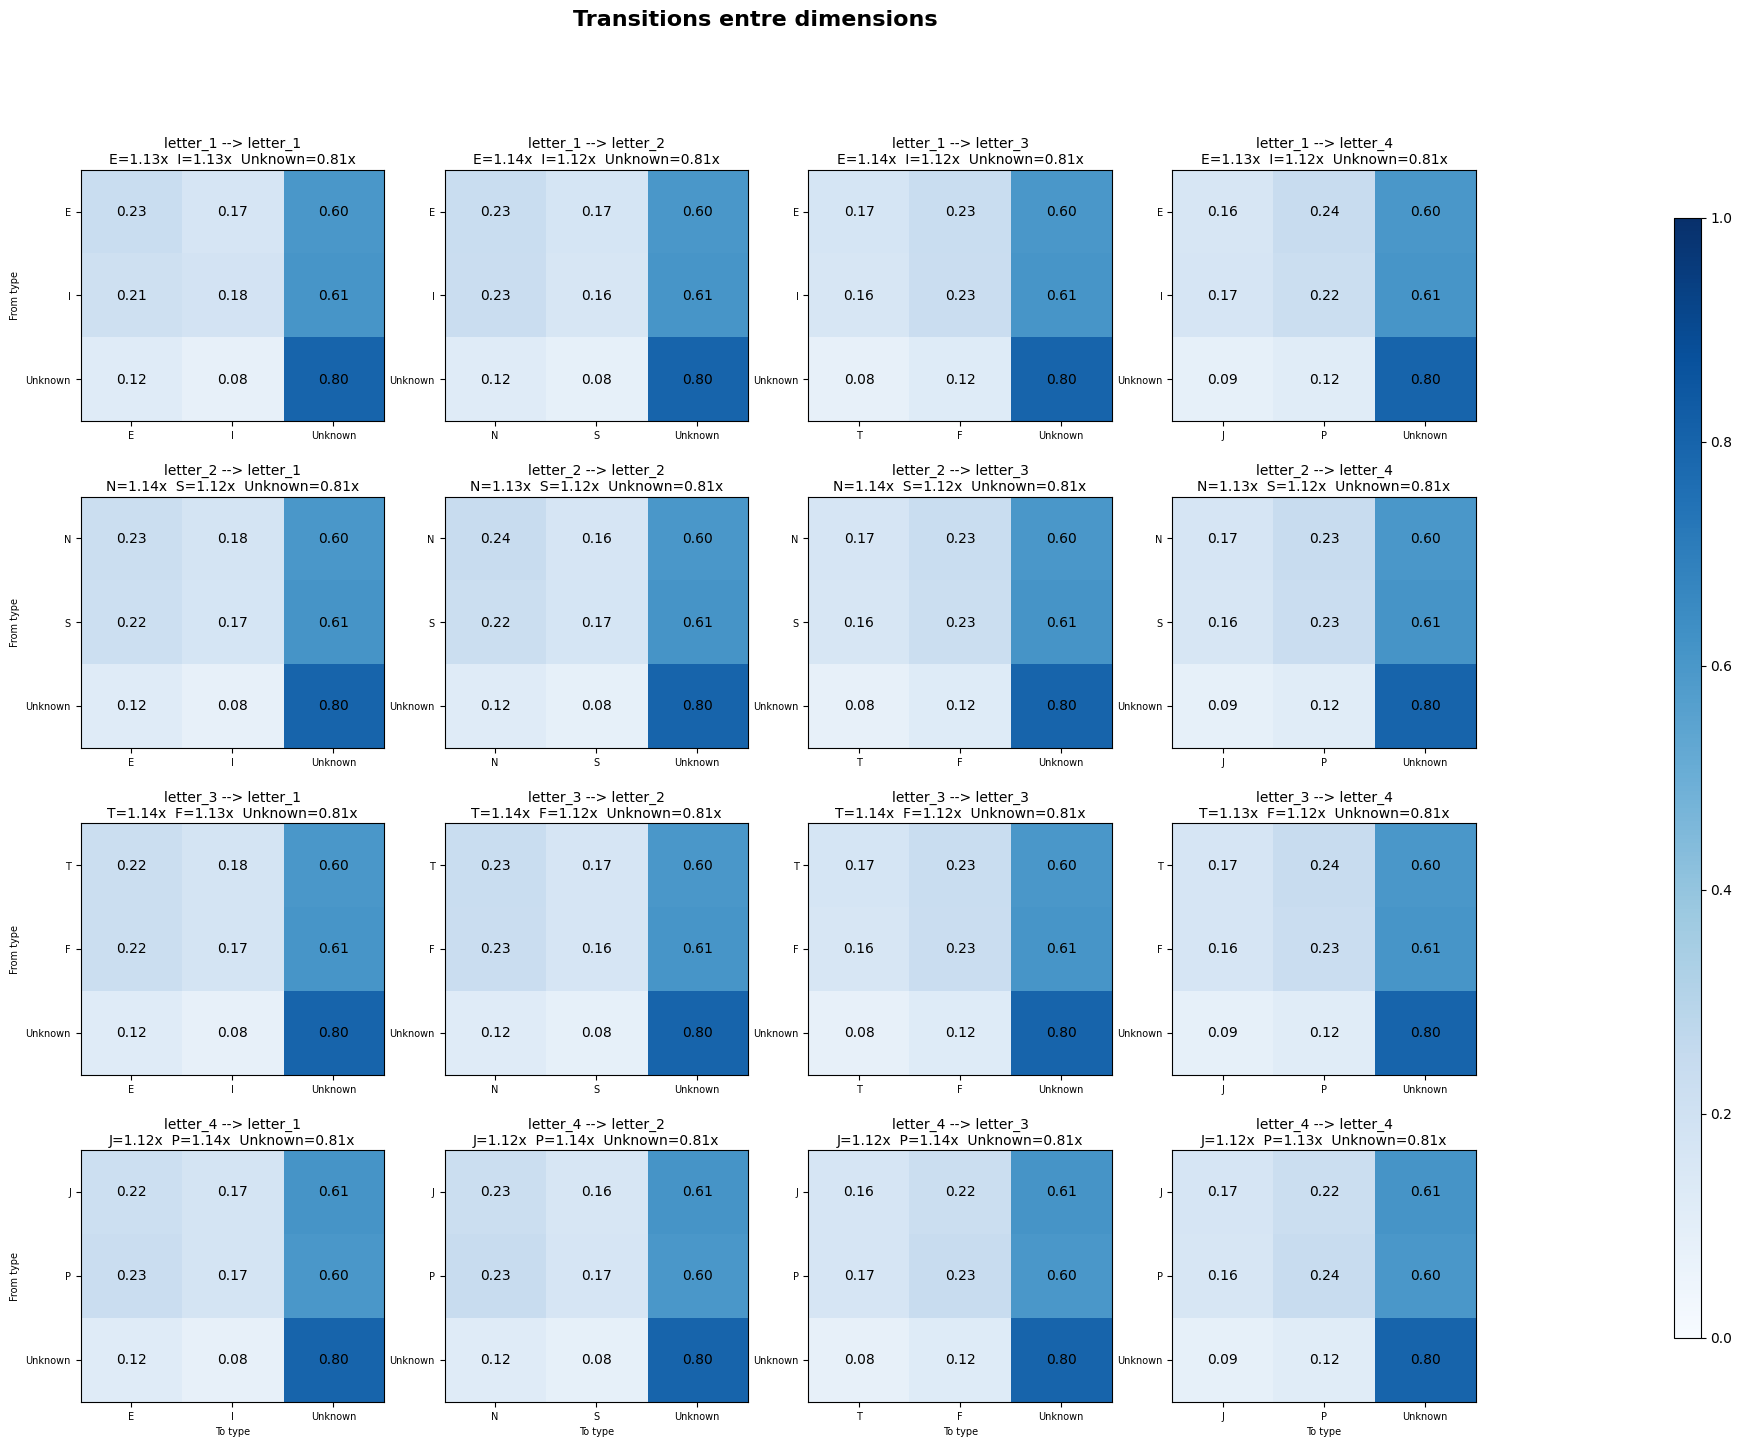

In [13]:
def plot_transition_matrix(stats) :
    DIMENSIONS = ['letter_1', 'letter_2', 'letter_3', 'letter_4']
    LETTERS = {'letter_1': ['E', 'I', 'Unknown'],
                'letter_2': ['N', 'S', 'Unknown'],
                'letter_3': ['T', 'F', 'Unknown'],
                'letter_4': ['J', 'P', 'Unknown']}

    fig, axes = plt.subplots(4, 4, figsize=(18, 16))
    fig.suptitle("Transitions entre dimensions", fontsize=16, fontweight='bold')

    for i, src_dim in enumerate(DIMENSIONS) :
        for j, tgt_dim in enumerate(DIMENSIONS) :
            ax = axes[i][j]
            src_vals = LETTERS[src_dim]   # from (axe Y)
            tgt_vals = LETTERS[tgt_dim]   # to (axe X)

            # Probability matrix
            matrix = np.zeros((len(src_vals), len(tgt_vals)))
            for r, from_val in enumerate(src_vals) :
                entry = stats[src_dim][tgt_dim][from_val]
                total = entry[0]
                # Avoid division by 0
                if total > 0 :
                    for c in range(len(tgt_vals)) :
                        matrix[r, c] = entry[c + 1] / total

            # Lift 
            all_counts = np.zeros(len(tgt_vals))
            all_total = 0
            for from_val in src_vals :
                entry = stats[src_dim][tgt_dim][from_val]
                all_total += entry[0]
                for c in range(len(tgt_vals)) :
                    all_counts[c] += entry[c + 1]
            marginal = all_counts / all_total if all_total > 0 else np.ones(len(tgt_vals)) / len(tgt_vals)

            lift_per_row = []
            for r, from_val in enumerate(src_vals) :
                row_observed = matrix[r]
                row_expected = marginal  # expected distribution
                with np.errstate(divide='ignore', invalid='ignore') :
                    row_lift = np.nanmean(np.where(row_expected > 0, row_observed / row_expected, np.nan))
                lift_per_row.append(f"{from_val}={row_lift:.2f}x")

            im = ax.imshow(matrix, vmin=0, vmax=1, cmap='Blues', aspect='auto')

            # Values in cell
            for r in range(len(src_vals)) :
                for c in range(len(tgt_vals)) :
                    ax.text(c, r, f"{matrix[r, c]:.2f}", ha='center', va='center', fontsize=10)

            # Set axes
            ax.set_xticks(range(len(tgt_vals)))
            ax.set_yticks(range(len(src_vals)))
            ax.set_xticklabels(tgt_vals, fontsize=7)
            ax.set_yticklabels(src_vals, fontsize=7)

            # Titre du subplot
            ax.set_title(f"{src_dim} --> {tgt_dim}\n" + "  ".join(lift_per_row), fontsize=10, pad=4)

            # Labels externes (seulement sur les bords)
            if i == 3 :
                ax.set_xlabel("To type", fontsize=7)
            if j == 0 :
                ax.set_ylabel("From type", fontsize=7)

    # Colorbar
    fig.subplots_adjust(wspace=0.2, hspace=0.3)
    cbar_ax = fig.add_axes([1.01, 0.15, 0.015, 0.7])
    fig.colorbar(im, cax=cbar_ax)

    plt.savefig("Images/Graph/transition_matrix.png", bbox_inches='tight', dpi=150)
    plt.show()

plot_transition_matrix(stats)

## Degree centrality

Number of neighbors of a node.


  letter_1
         N nodes  Mean degree  Median degree
E           1397       40.325             24
I           1049       42.728             27
Unknown     9191       13.211              9

  letter_2
         N nodes  Mean degree  Median degree
N           1422       41.885             26
S           1024       40.621             23
Unknown     9191       13.211              9

  letter_3
         N nodes  Mean degree  Median degree
T            973       42.768             27
F           1473       40.423             24
Unknown     9191       13.211              9

  letter_4
         N nodes  Mean degree  Median degree
J           1022       41.652             25
P           1424       41.143             26
Unknown     9191       13.211              9


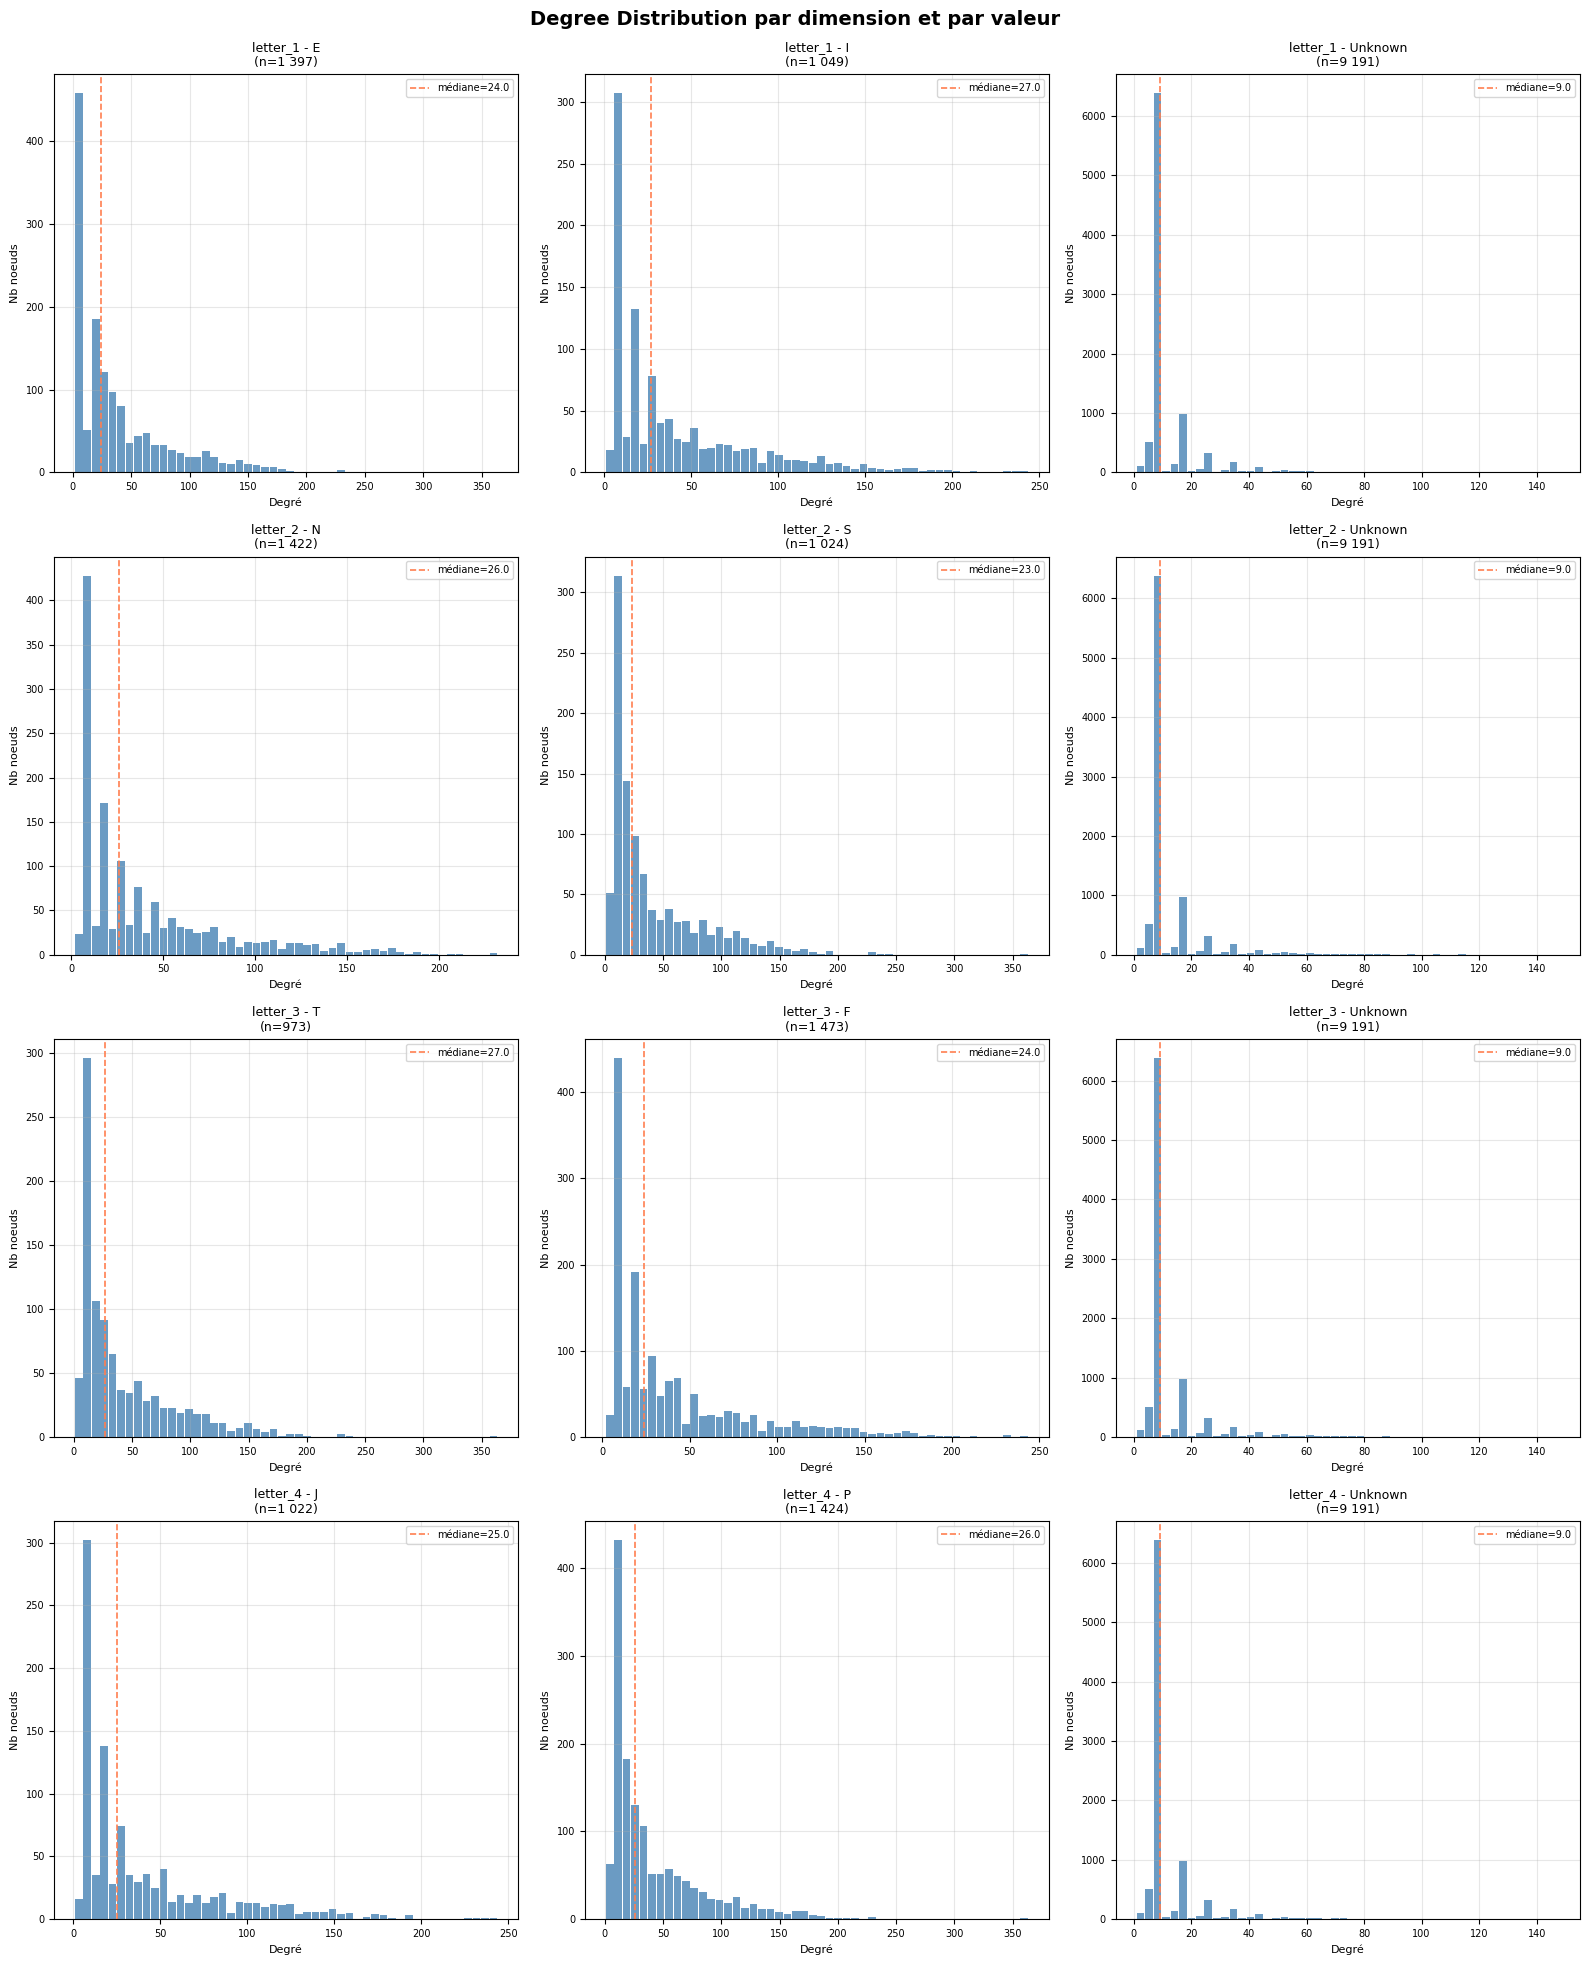

In [14]:
DIMENSIONS = ['letter_1', 'letter_2', 'letter_3', 'letter_4']
LETTERS = {'letter_1': ['E', 'I', 'Unknown'],
            'letter_2': ['N', 'S', 'Unknown'],
            'letter_3': ['T', 'F', 'Unknown'],
            'letter_4': ['J', 'P', 'Unknown']}

# Calcul
degree_raw = dict(G.degree())

results_degree = {}
for dim in DIMENSIONS :
    results_degree[dim] = {}
    for val in LETTERS[dim] :
        nodes = [n for n, attr in G.nodes(data=True) if attr.get(dim, 'Unknown') == val]
        vals  = [degree_raw[n] for n in nodes]
        results_degree[dim][val] = {'n_nodes': len(nodes),
                                    'mean'   : np.mean(vals)   if vals else None,
                                    'median' : np.median(vals) if vals else None}

# Infos 
for dim in DIMENSIONS :
    print(f"\n{'='*50}\n  {dim}\n{'='*50}")
    df = pd.DataFrame(results_degree[dim]).T[['n_nodes', 'mean', 'median']]
    df.columns = ['N nodes', 'Mean degree', 'Median degree']
    df['N nodes'] = df['N nodes'].astype(int)
    df['Median degree'] = df['Median degree'].astype(int)
    df['Mean degree'] = df['Mean degree'].round(3)
    print(df.to_string())

# Graphique
fig, axes = plt.subplots(4, 3, figsize=(16, 20))
fig.suptitle("Degree Distribution par dimension et par valeur\n", fontsize=14, fontweight='bold')

for i, dim in enumerate(DIMENSIONS) :
    for j, val in enumerate(LETTERS[dim]) :

        ax = axes[i][j]

        nodes = [n for n, attr in G.nodes(data=True) if attr.get(dim, 'Unknown') == val]
        degs  = [degree_raw[n] for n in nodes]

        if not degs :
            ax.set_visible(False)
            continue

        counts, bin_edges = np.histogram(degs, bins=50)
        bin_widths = bin_edges[1:] - bin_edges[:-1]

        ax.bar(bin_edges[:-1], counts, width=bin_widths * 0.9, color='steelblue', alpha=0.8, align='edge')

        ax.set_title(f"{dim} - {val}\n(n={len(nodes):,})".replace(",", " "), fontsize=9)
        ax.set_xlabel("Degré", fontsize=8)
        ax.set_ylabel("Nb noeuds", fontsize=8)
        ax.grid(alpha=0.3)
        ax.tick_params(labelsize=7)

        # Median
        median_deg = np.median(degs)
        ax.axvline(median_deg, color='coral', linestyle='--', linewidth=1.2, label=f"médiane={median_deg:.1f}")
        ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig("Images/Graph/degree_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

## Betweenness Centrality

Measures how many shortest paths pass through a node.


  letter_1
         N nodes  Mean betw.  Median betw.
E           1397    0.000622      0.000083
I           1049    0.000729      0.000110
Unknown     9191    0.000067      0.000000

  letter_2
         N nodes  Mean betw.  Median betw.
N           1422    0.000681      0.000115
S           1024    0.000650      0.000071
Unknown     9191    0.000067      0.000000

  letter_3
         N nodes  Mean betw.  Median betw.
T            973    0.000713      0.000117
F           1473    0.000638      0.000082
Unknown     9191    0.000067      0.000000

  letter_4
         N nodes  Mean betw.  Median betw.
J           1022    0.000681      0.000091
P           1424    0.000658      0.000099
Unknown     9191    0.000067      0.000000


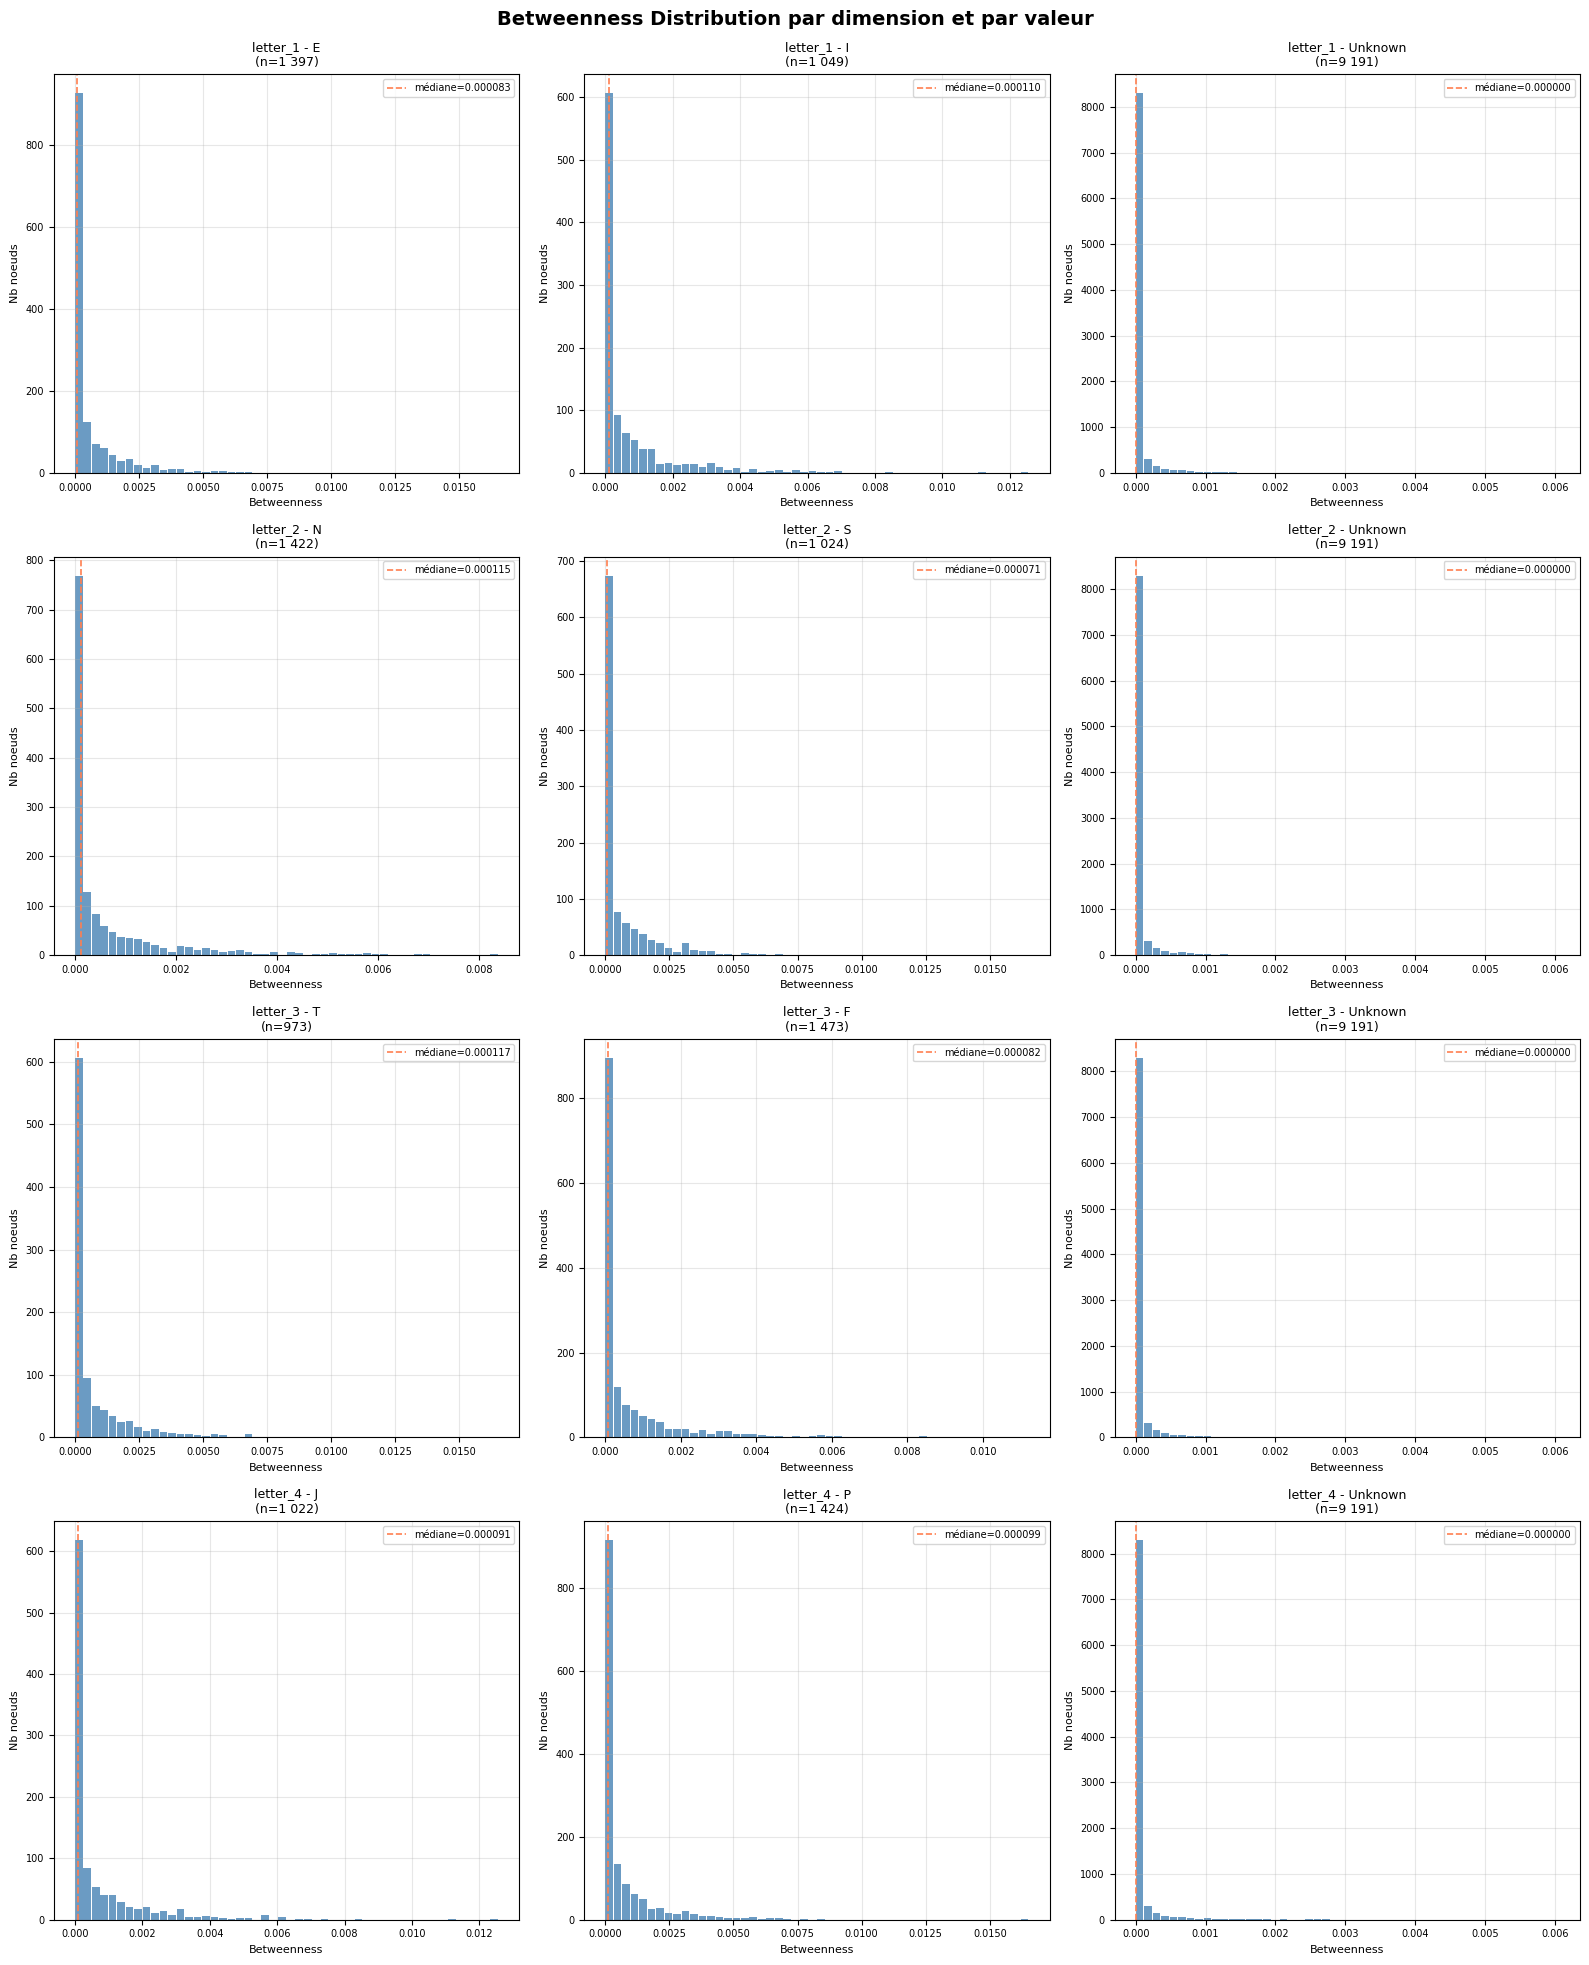

In [15]:
# Calcul
betweenness = nx.betweenness_centrality(G, normalized=True, k=500)

results_btw = {}
for dim in DIMENSIONS :
    results_btw[dim] = {}
    for val in LETTERS[dim] :
        nodes = [n for n, attr in G.nodes(data=True) if attr.get(dim, 'Unknown') == val]
        vals  = [betweenness[n] for n in nodes]
        results_btw[dim][val] = {'n_nodes': len(nodes),
                                  'mean'   : np.mean(vals)   if vals else None,
                                  'median' : np.median(vals) if vals else None}

# Infos
for dim in DIMENSIONS :
    print(f"\n{'='*50}\n  {dim}\n{'='*50}")
    df = pd.DataFrame(results_btw[dim]).T[['n_nodes', 'mean', 'median']]
    df.columns = ['N nodes', 'Mean betw.', 'Median betw.']
    df['N nodes'] = df['N nodes'].astype(int)
    print(df.to_string())

# Graphique
fig, axes = plt.subplots(4, 3, figsize=(16, 20))
fig.suptitle("Betweenness Distribution par dimension et par valeur\n", fontsize=14, fontweight='bold')

for i, dim in enumerate(DIMENSIONS) :
    for j, val in enumerate(LETTERS[dim]) :
        ax = axes[i][j]

        nodes = [n for n, attr in G.nodes(data=True) if attr.get(dim, 'Unknown') == val]
        vals  = [betweenness[n] for n in nodes]

        if not vals :
            ax.set_visible(False)
            continue

        counts, bin_edges = np.histogram(vals, bins=50)
        bin_widths = bin_edges[1:] - bin_edges[:-1]

        ax.bar(bin_edges[:-1], counts, width=bin_widths * 0.9, color='steelblue', alpha=0.8, align='edge')

        ax.set_title(f"{dim} - {val}\n(n={len(nodes):,})".replace(",", " "), fontsize=9)
        ax.set_xlabel("Betweenness", fontsize=8)
        ax.set_ylabel("Nb noeuds", fontsize=8)
        ax.grid(alpha=0.3)
        ax.tick_params(labelsize=7)

        median_val = np.median(vals)
        ax.axvline(median_val, color='coral', linestyle='--', linewidth=1.2, label=f"médiane={median_val:.6f}")
        ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig("Images/Graph/betweenness_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

## Closeness Centrality

The inverse of the average distance to all other nodes.

How far away am I from everyone?


  letter_1
         N nodes  Mean close.  Median close.
E           1397       0.2842         0.2892
I           1049       0.2836         0.2916
Unknown     9191       0.2415         0.2637

  letter_2
         N nodes  Mean close.  Median close.
N           1422       0.2833         0.2912
S           1024       0.2848         0.2889
Unknown     9191       0.2415         0.2637

  letter_3
         N nodes  Mean close.  Median close.
T            973       0.2854         0.2913
F           1473       0.2830         0.2892
Unknown     9191       0.2415         0.2637

  letter_4
         N nodes  Mean close.  Median close.
J           1022       0.2843         0.2898
P           1424       0.2837         0.2901
Unknown     9191       0.2415         0.2637


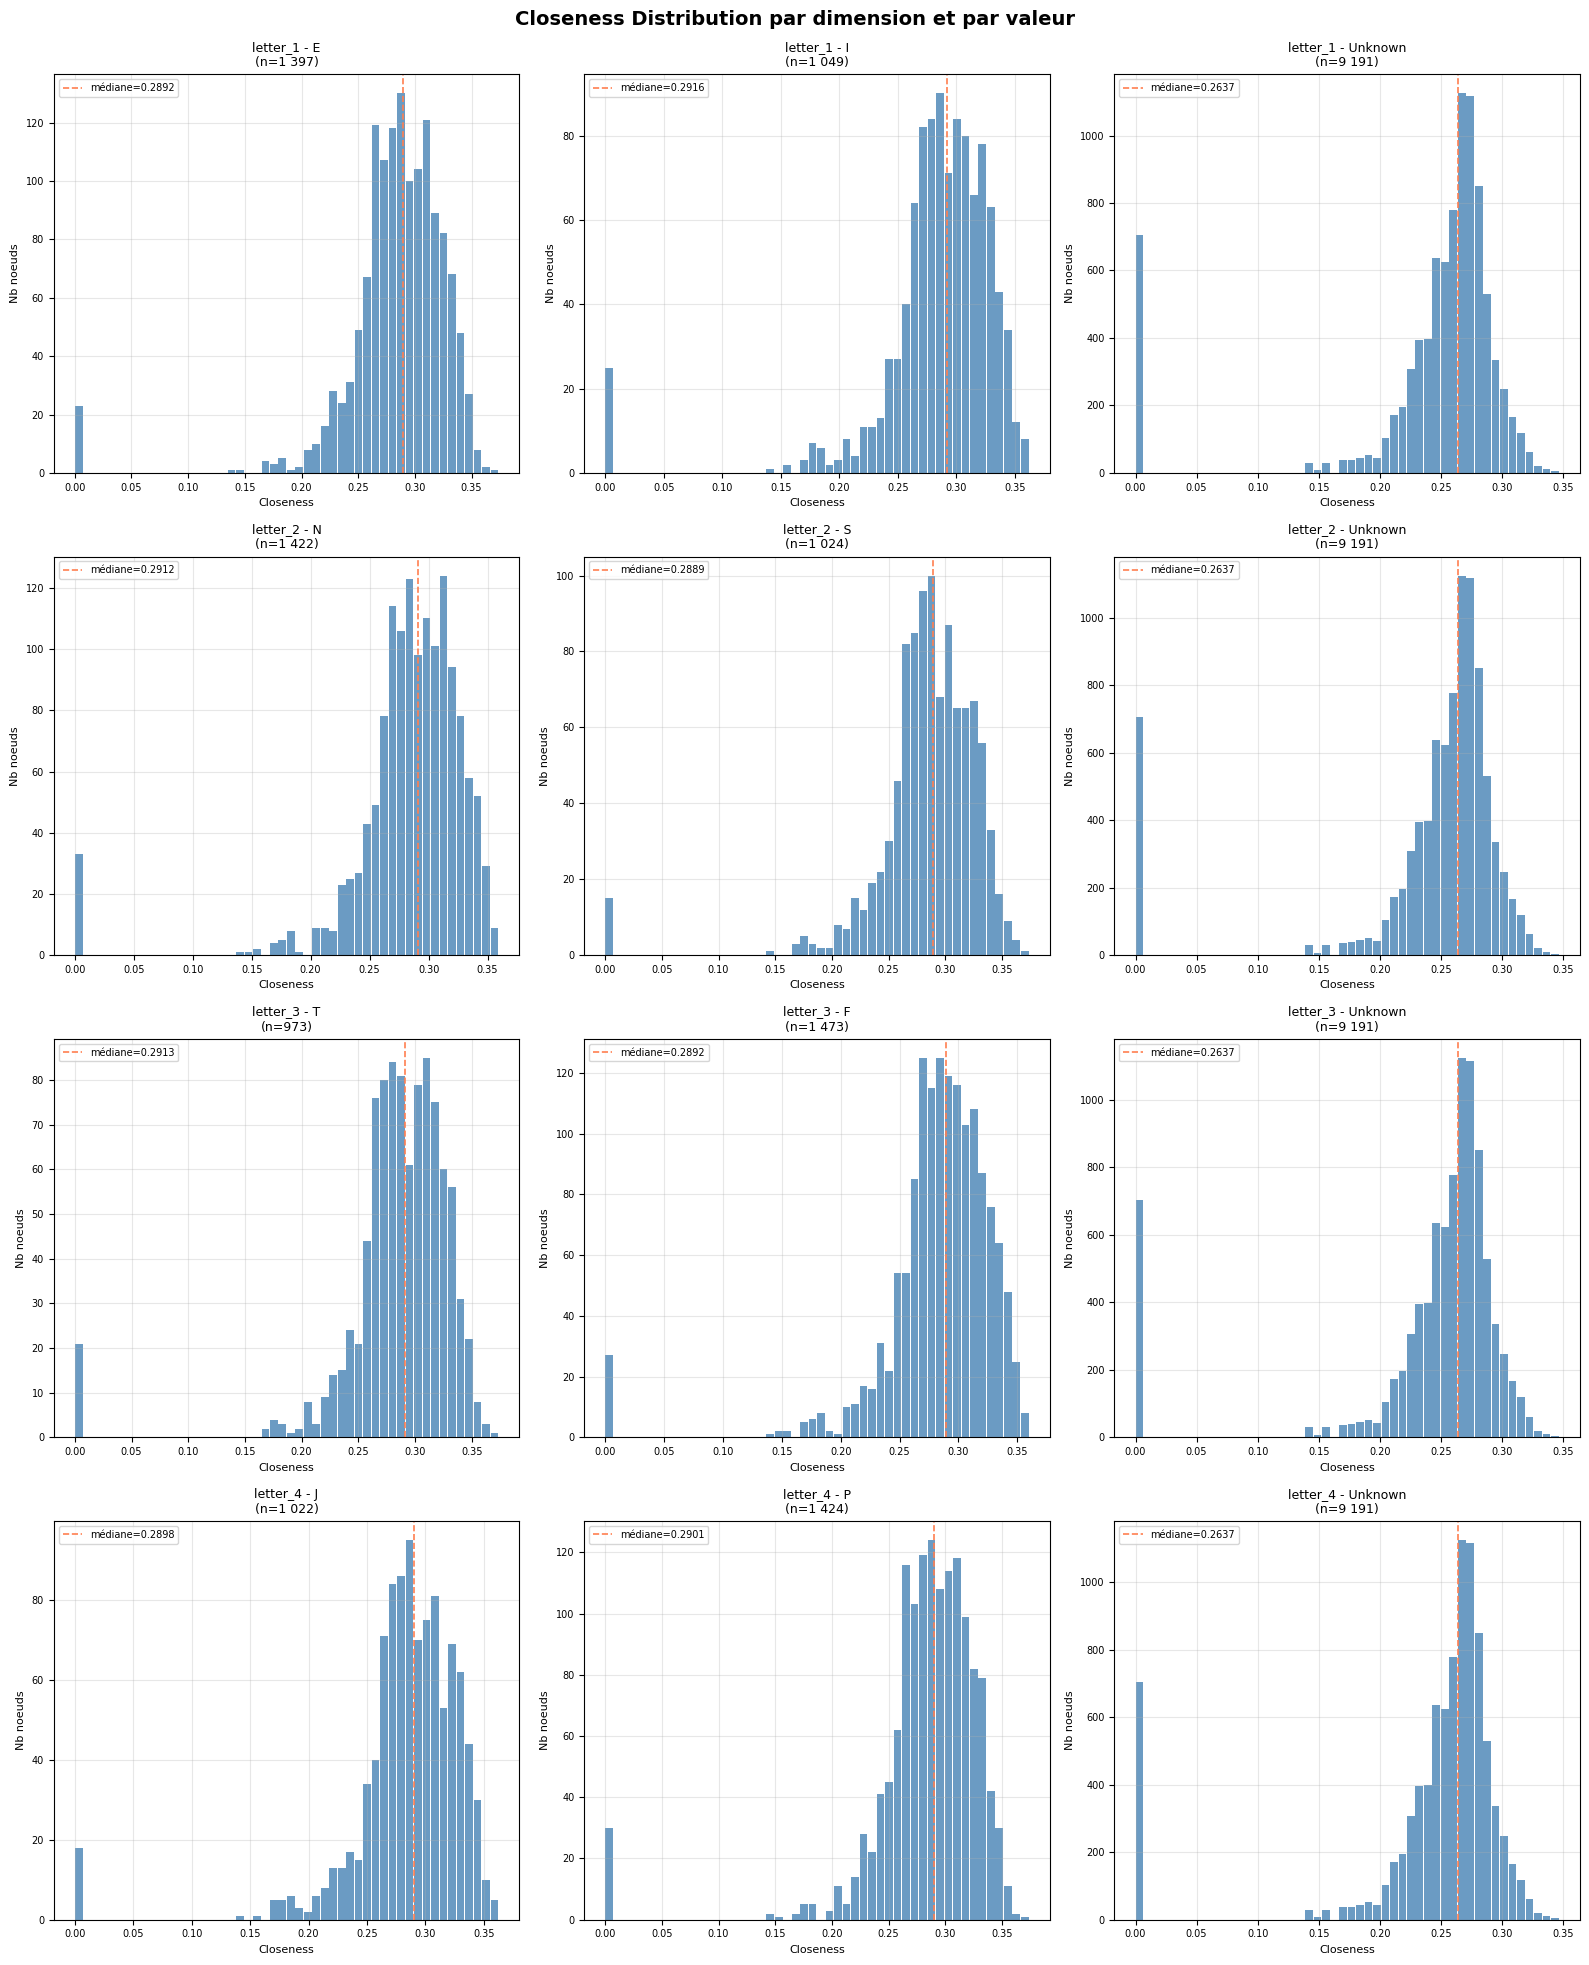

In [16]:
# Calcul
closeness = nx.closeness_centrality(G)

results_close = {}
for dim in DIMENSIONS :
    results_close[dim] = {}
    for val in LETTERS[dim] :
        nodes = [n for n, attr in G.nodes(data=True) if attr.get(dim, 'Unknown') == val]
        vals  = [closeness[n] for n in nodes]
        results_close[dim][val] = {'n_nodes': len(nodes),
                                    'mean'   : np.mean(vals)   if vals else None,
                                    'median' : np.median(vals) if vals else None}

# Infos
for dim in DIMENSIONS :
    print(f"\n{'='*50}\n  {dim}\n{'='*50}")
    df = pd.DataFrame(results_close[dim]).T[['n_nodes', 'mean', 'median']]
    df.columns = ['N nodes', 'Mean close.', 'Median close.']
    df['N nodes'] = df['N nodes'].astype(int)
    df['Median close.'] = df['Median close.'].round(4)
    df['Mean close.'] = df['Mean close.'].round(4)
    print(df.to_string())

# Graphique
fig, axes = plt.subplots(4, 3, figsize=(16, 20))
fig.suptitle("Closeness Distribution par dimension et par valeur\n", fontsize=14, fontweight='bold')

for i, dim in enumerate(DIMENSIONS) :
    for j, val in enumerate(LETTERS[dim]) :
        ax = axes[i][j]

        nodes = [n for n, attr in G.nodes(data=True) if attr.get(dim, 'Unknown') == val]
        vals  = [closeness[n] for n in nodes]

        if not vals :
            ax.set_visible(False)
            continue

        counts, bin_edges = np.histogram(vals, bins=50)
        bin_widths = bin_edges[1:] - bin_edges[:-1]

        ax.bar(bin_edges[:-1], counts, width=bin_widths * 0.9, color='steelblue', alpha=0.8, align='edge')

        ax.set_title(f"{dim} - {val}\n(n={len(nodes):,})".replace(",", " "), fontsize=9)
        ax.set_xlabel("Closeness", fontsize=8)
        ax.set_ylabel("Nb noeuds", fontsize=8)
        ax.grid(alpha=0.3)
        ax.tick_params(labelsize=7)

        median_val = np.median(vals)
        ax.axvline(median_val, color='coral', linestyle='--', linewidth=1.2, label=f"médiane={median_val:.4f}")
        ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig("Images/Graph/closeness_distribution.png", dpi=150, bbox_inches='tight')
plt.show()


## Pagerank centrality

Important if neighbors are important. (quality)


  letter_1
         N nodes  Mean pagerank  Median pagerank
E           1397       0.000150         0.000097
I           1049       0.000160         0.000105
Unknown     9191       0.000068         0.000055

  letter_2
         N nodes  Mean pagerank  Median pagerank
N           1422       0.000157         0.000103
S           1024       0.000151         0.000096
Unknown     9191       0.000068         0.000055

  letter_3
         N nodes  Mean pagerank  Median pagerank
T            973       0.000158         0.000104
F           1473       0.000152         0.000098
Unknown     9191       0.000068         0.000055

  letter_4
         N nodes  Mean pagerank  Median pagerank
J           1022       0.000156         0.000100
P           1424       0.000154         0.000101
Unknown     9191       0.000068         0.000055


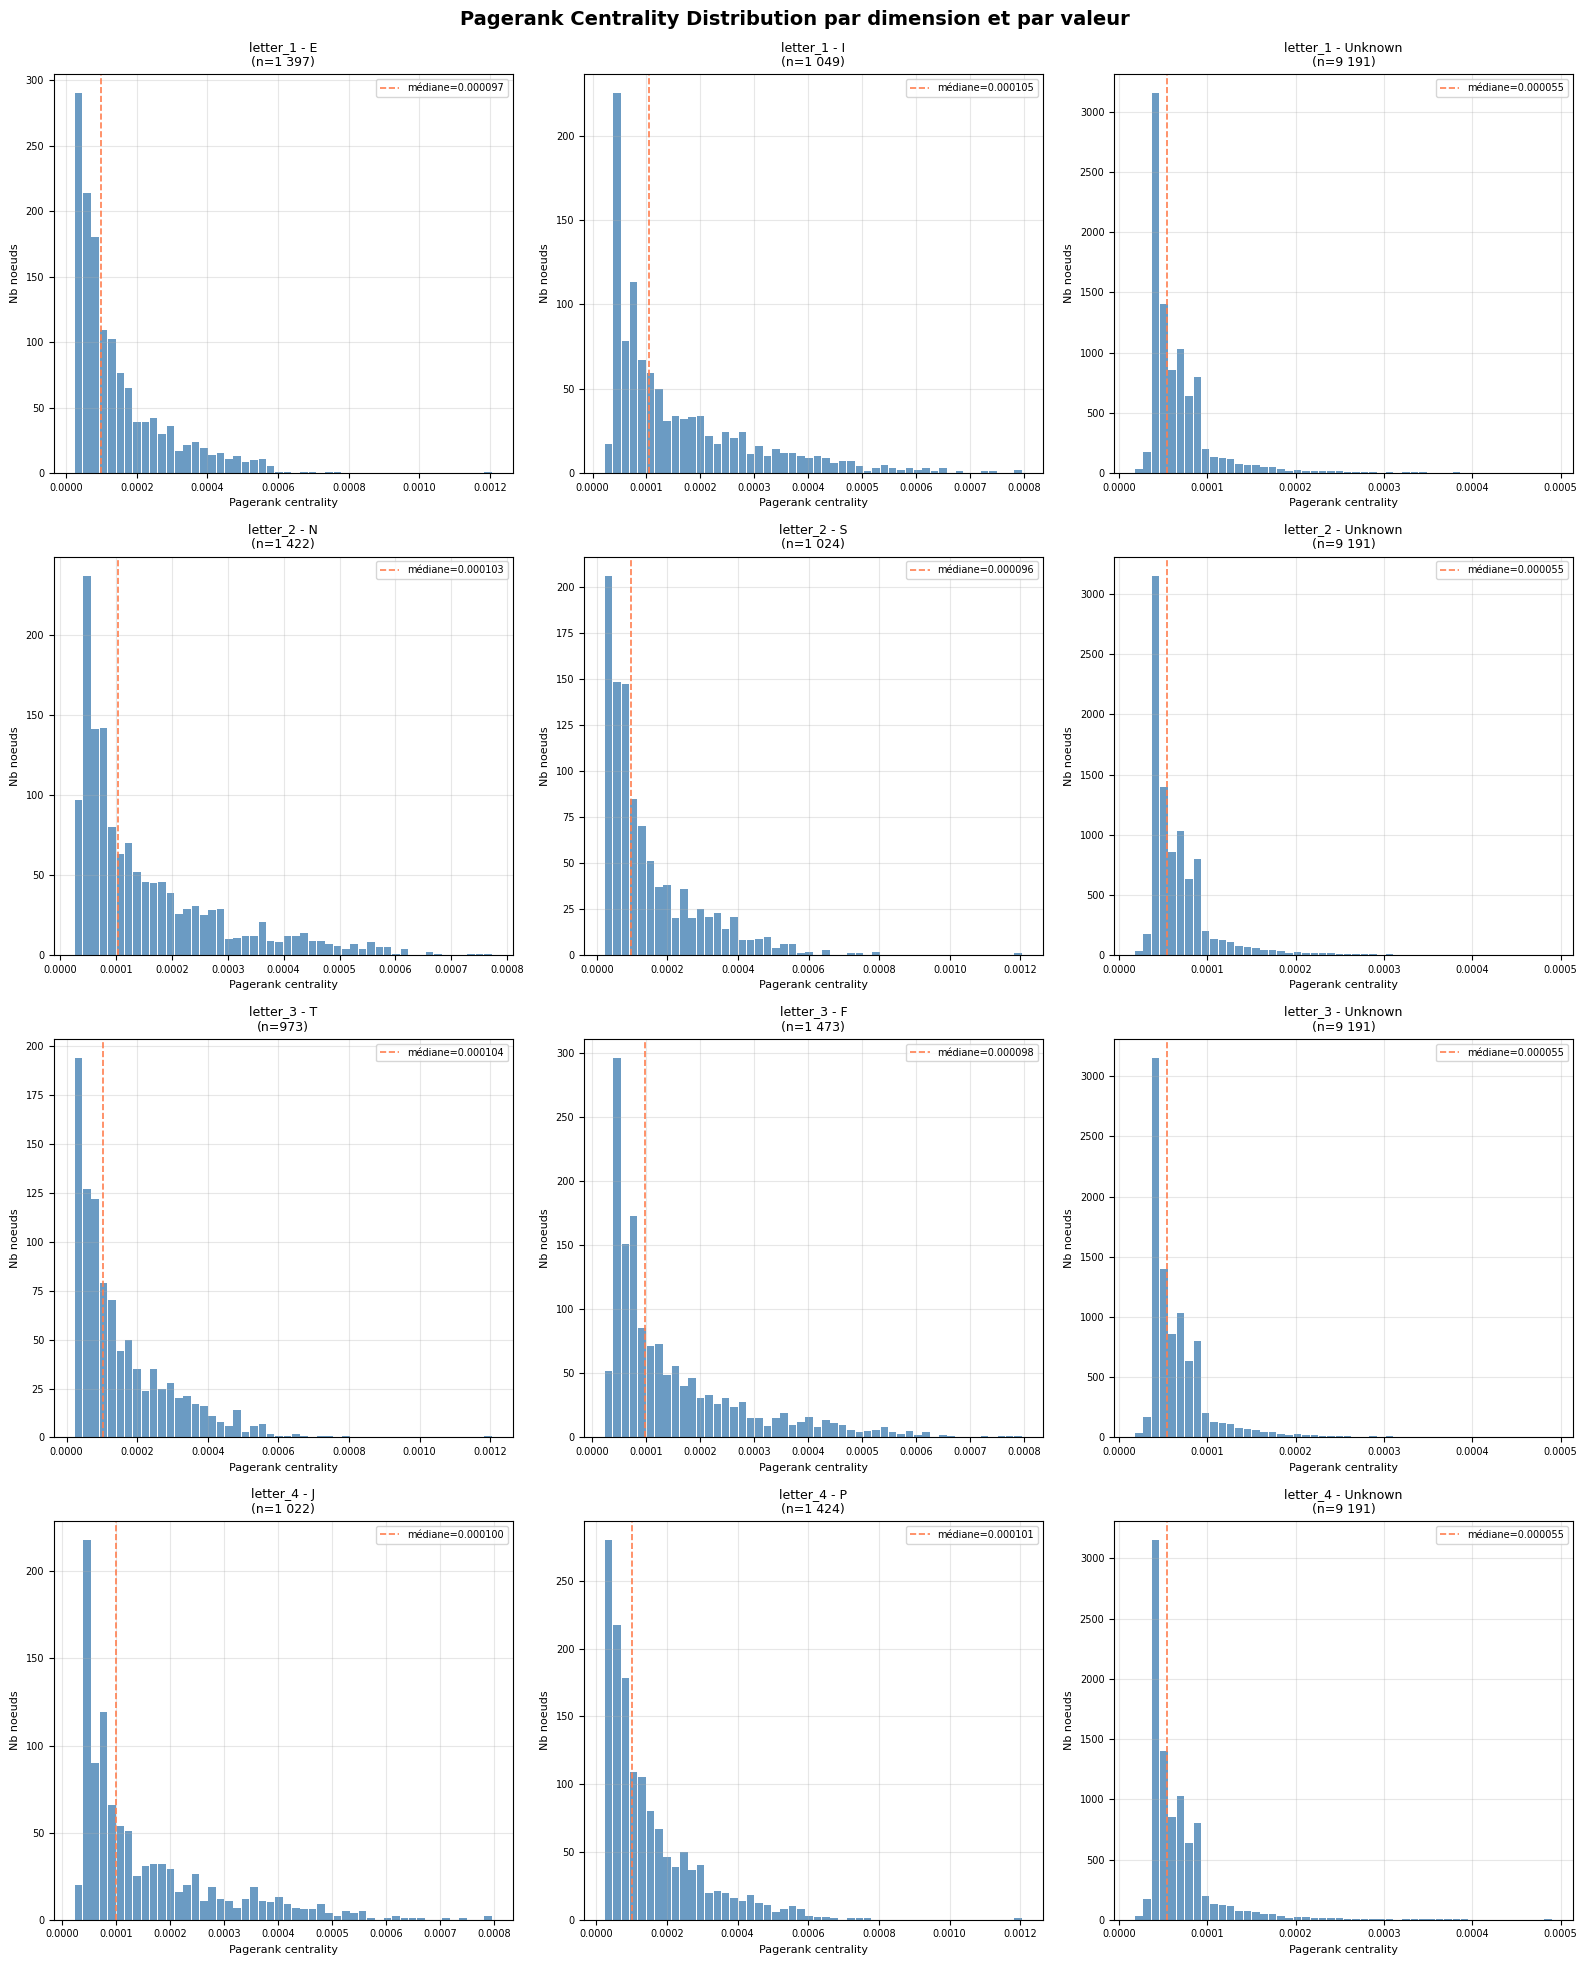

In [17]:
pagerank = nx.pagerank(G)

results_pagerank = {}
for dim in DIMENSIONS :
    results_pagerank[dim] = {}
    for val in LETTERS[dim] :
        nodes = [n for n, attr in G.nodes(data=True) if attr.get(dim, 'Unknown') == val]
        vals  = [pagerank[n] for n in nodes]
        results_pagerank[dim][val] = {'n_nodes': len(nodes),
                                        'mean'   : np.mean(vals)   if vals else None,
                                        'median' : np.median(vals) if vals else None}

# Infos
for dim in DIMENSIONS :
    print(f"\n{'='*50}\n  {dim}\n{'='*50}")
    df = pd.DataFrame(results_pagerank[dim]).T[['n_nodes', 'mean', 'median']]
    df.columns = ['N nodes', 'Mean pagerank', 'Median pagerank']
    df['N nodes'] = df['N nodes'].astype(int)
    print(df.to_string())

# Graphique
fig, axes = plt.subplots(4, 3, figsize=(16, 20))
fig.suptitle("Pagerank Centrality Distribution par dimension et par valeur\n", fontsize=14, fontweight='bold')

for i, dim in enumerate(DIMENSIONS) :
    for j, val in enumerate(LETTERS[dim]) :
        ax = axes[i][j]

        nodes = [n for n, attr in G.nodes(data=True) if attr.get(dim, 'Unknown') == val]
        vals  = [pagerank[n] for n in nodes]

        if not vals :
            ax.set_visible(False)
            continue

        counts, bin_edges = np.histogram(vals, bins=50)
        bin_widths = bin_edges[1:] - bin_edges[:-1]

        ax.bar(bin_edges[:-1], counts, width=bin_widths * 0.9, color='steelblue', alpha=0.8, align='edge')

        ax.set_title(f"{dim} - {val}\n(n={len(nodes):,})".replace(",", " "), fontsize=9)
        ax.set_xlabel("Pagerank centrality", fontsize=8)
        ax.set_ylabel("Nb noeuds", fontsize=8)
        ax.grid(alpha=0.3)
        ax.tick_params(labelsize=7)

        median_val = np.median(vals)
        ax.axvline(median_val, color='coral', linestyle='--', linewidth=1.2, label=f"médiane={median_val:.6f}")
        ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig("Images/Graph/pagerank_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

## Eigenvector Centrality

"I am influential if my neighbors are influential."

> similar to PageRank, but more mathematical


  letter_1
         N nodes  Mean eig.  Median eig.
E           1397     0.0109       0.0053
I           1049     0.0118       0.0057
Unknown     9191     0.0027       0.0016

  letter_2
         N nodes  Mean eig.  Median eig.
N           1422     0.0114       0.0057
S           1024     0.0111       0.0052
Unknown     9191     0.0027       0.0016

  letter_3
         N nodes  Mean eig.  Median eig.
T            973     0.0119       0.0058
F           1473     0.0109       0.0052
Unknown     9191     0.0027       0.0016

  letter_4
         N nodes  Mean eig.  Median eig.
J           1022     0.0114       0.0052
P           1424     0.0112       0.0055
Unknown     9191     0.0027       0.0016


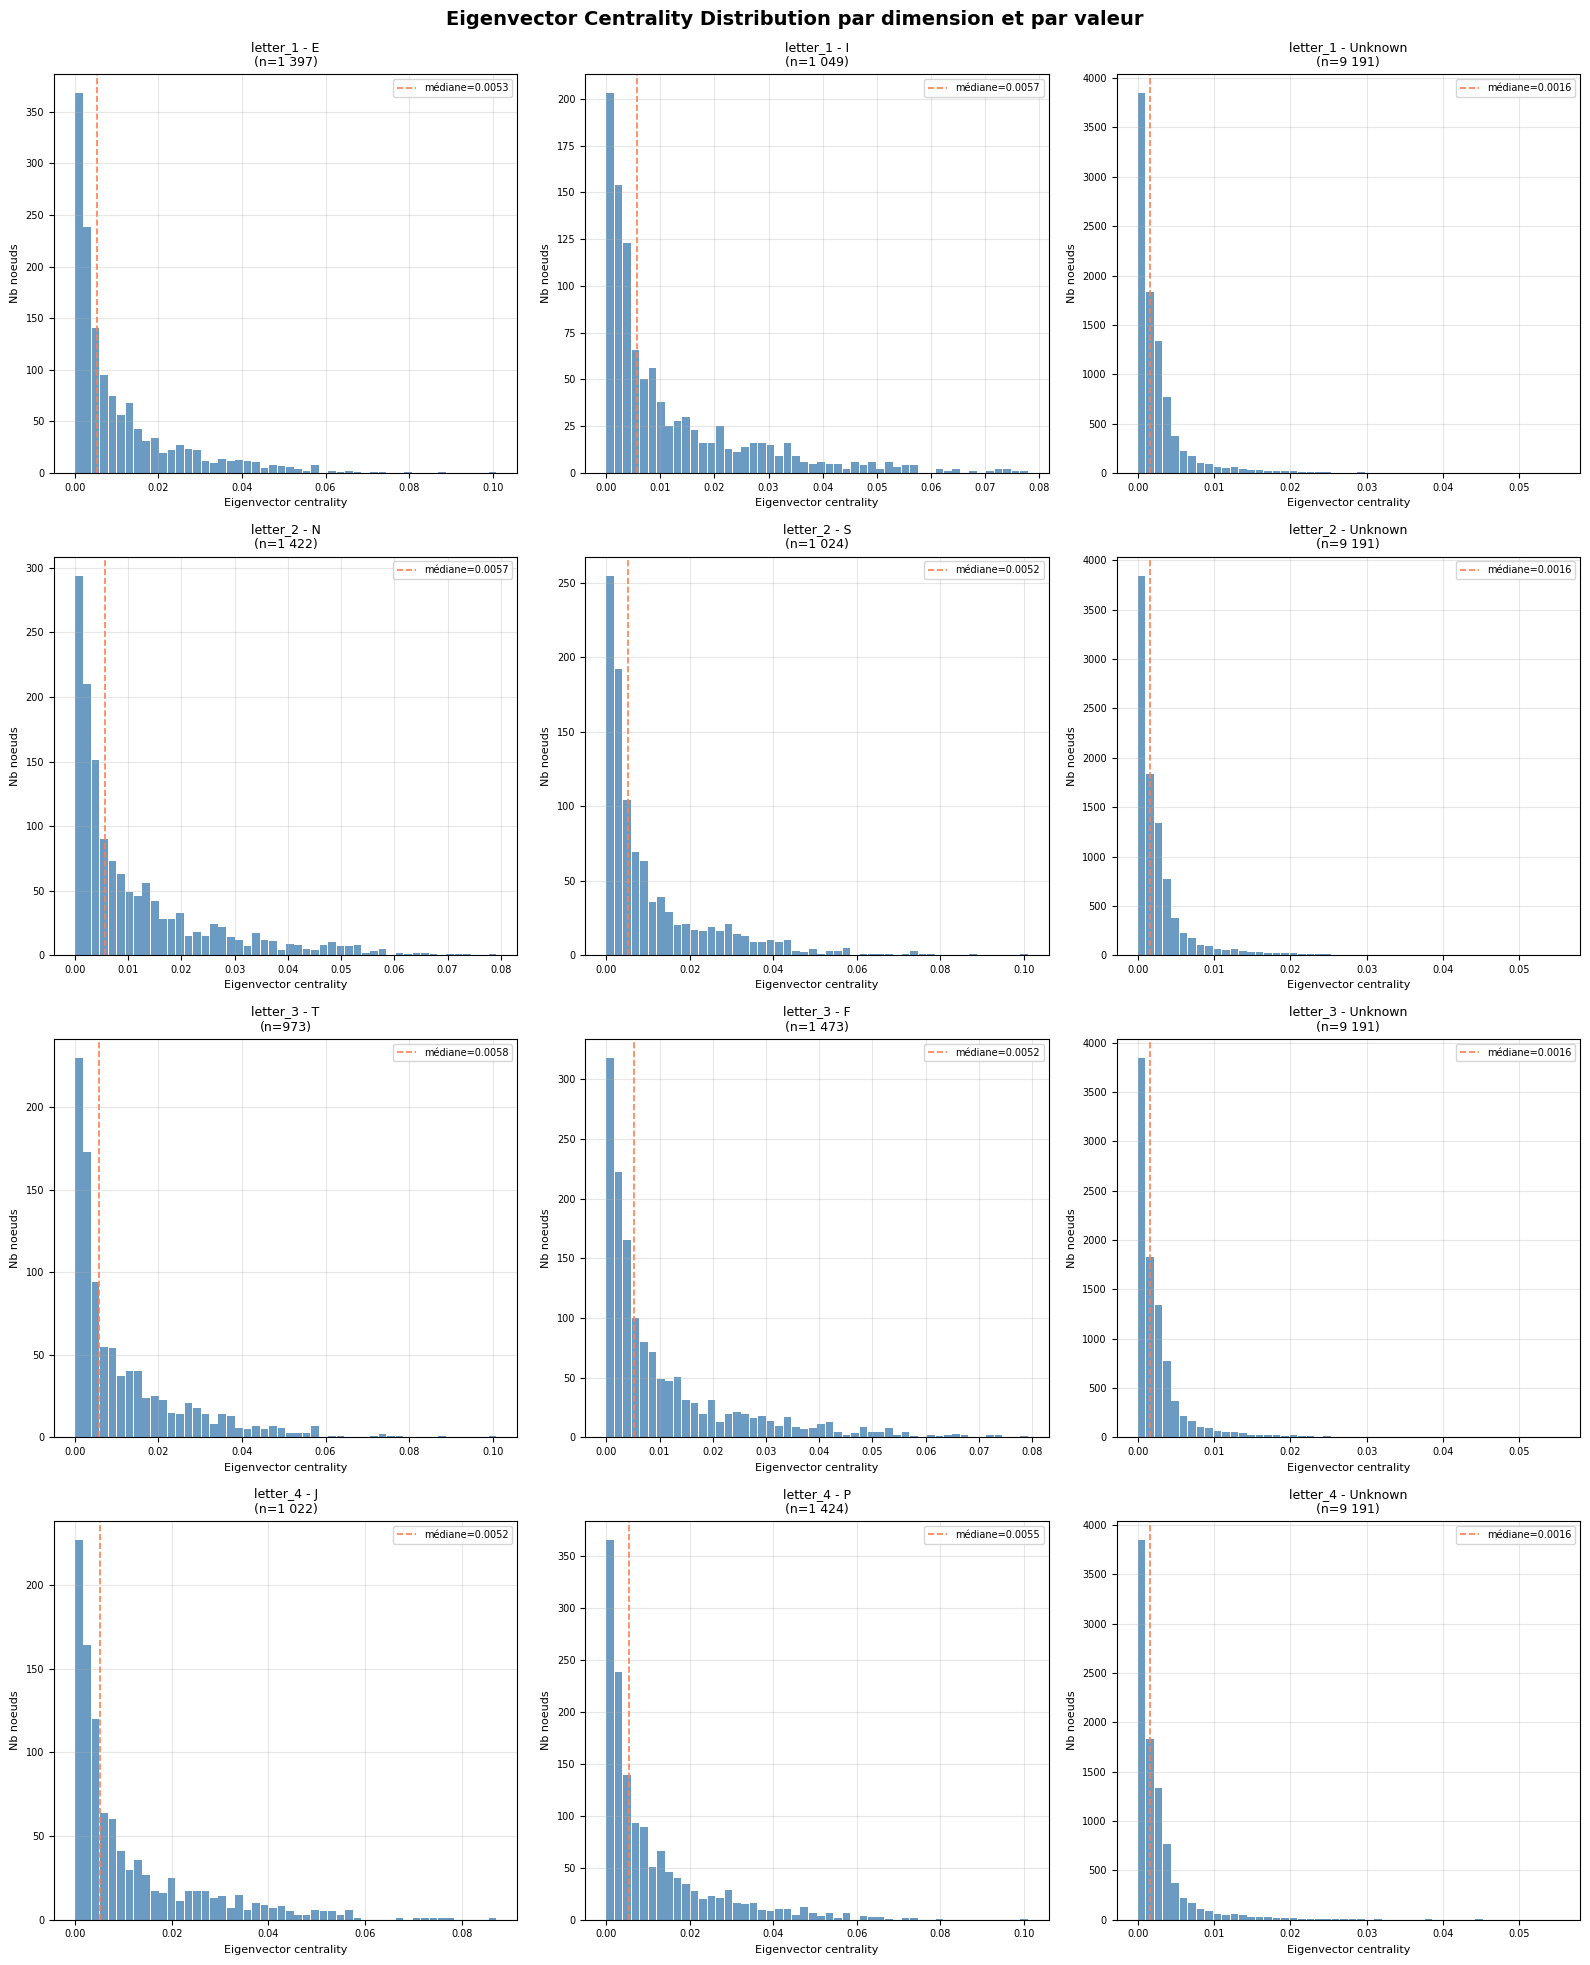

In [18]:
# Calcul
eigenvector = nx.eigenvector_centrality(G, max_iter=1000)

results_eig = {}
for dim in DIMENSIONS :
    results_eig[dim] = {}
    for val in LETTERS[dim] :
        nodes = [n for n, attr in G.nodes(data=True) if attr.get(dim, 'Unknown') == val]
        vals  = [eigenvector[n] for n in nodes]
        results_eig[dim][val] = {'n_nodes': len(nodes),
                                  'mean'   : np.mean(vals)   if vals else None,
                                  'median' : np.median(vals) if vals else None}

# Infos
for dim in DIMENSIONS:
    print(f"\n{'='*50}\n  {dim}\n{'='*50}")
    df = pd.DataFrame(results_eig[dim]).T[['n_nodes', 'mean', 'median']]
    df.columns = ['N nodes', 'Mean eig.', 'Median eig.']
    df['N nodes'] = df['N nodes'].astype(int)
    df['Mean eig.'] = df['Mean eig.'].round(4)
    df['Median eig.'] = df['Median eig.'].round(4)
    print(df.to_string())

# Graphique
fig, axes = plt.subplots(4, 3, figsize=(16, 20))
fig.suptitle("Eigenvector Centrality Distribution par dimension et par valeur\n", fontsize=14, fontweight='bold')

for i, dim in enumerate(DIMENSIONS) :
    for j, val in enumerate(LETTERS[dim]) :
        ax = axes[i][j]

        nodes = [n for n, attr in G.nodes(data=True) if attr.get(dim, 'Unknown') == val]
        vals  = [eigenvector[n] for n in nodes]

        if not vals :
            ax.set_visible(False)
            continue

        counts, bin_edges = np.histogram(vals, bins=50)
        bin_widths = bin_edges[1:] - bin_edges[:-1]

        ax.bar(bin_edges[:-1], counts, width=bin_widths * 0.9, color='steelblue', alpha=0.8, align='edge')

        ax.set_title(f"{dim} - {val}\n(n={len(nodes):,})".replace(",", " "), fontsize=9)
        ax.set_xlabel("Eigenvector centrality", fontsize=8)
        ax.set_ylabel("Nb noeuds", fontsize=8)
        ax.grid(alpha=0.3)
        ax.tick_params(labelsize=7)

        median_val = np.median(vals)
        ax.axvline(median_val, color='coral', linestyle='--', linewidth=1.2, label=f"médiane={median_val:.4f}")
        ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig("Images/Graph/eigenvector_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

## Clustering Coefficient

"Are my neighbors connected to each other?"

Measures the density of triangles around a node


  letter_1
         N nodes  Mean clust.  Median clust.
E           1397        0.501          0.348
I           1049        0.480          0.322
Unknown     9191        0.851          1.000

  letter_2
         N nodes  Mean clust.  Median clust.
N           1422        0.486          0.325
S           1024        0.500          0.365
Unknown     9191        0.851          1.000

  letter_3
         N nodes  Mean clust.  Median clust.
T            973        0.487          0.319
F           1473        0.495          0.355
Unknown     9191        0.851          1.000

  letter_4
         N nodes  Mean clust.  Median clust.
J           1022        0.489          0.347
P           1424        0.494          0.329
Unknown     9191        0.851          1.000


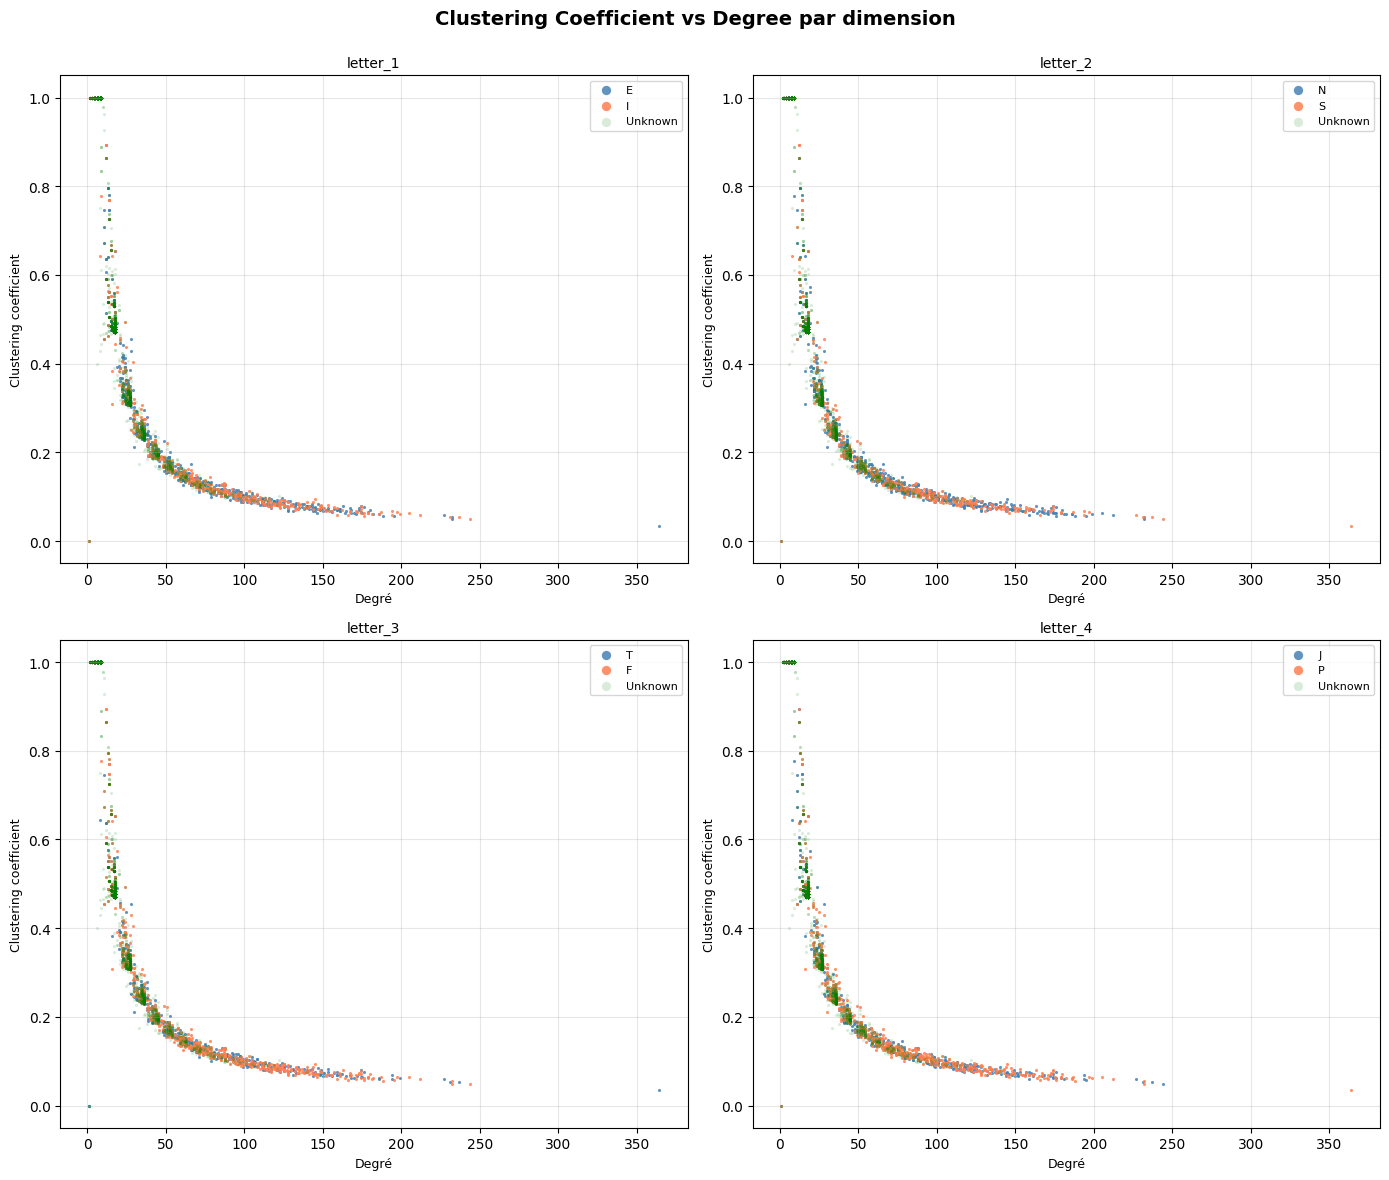

In [19]:
# Calcul
clustering = nx.clustering(G)
degree_raw = dict(G.degree())

results_clust = {}
for dim in DIMENSIONS :
    results_clust[dim] = {}
    for val in LETTERS[dim] :
        nodes = [n for n, attr in G.nodes(data=True) if attr.get(dim, 'Unknown') == val]
        vals  = [clustering[n] for n in nodes]
        results_clust[dim][val] = {'n_nodes': len(nodes),
                                    'mean'   : np.mean(vals)   if vals else None,
                                    'median' : np.median(vals) if vals else None}

# Infos
for dim in DIMENSIONS :
    print(f"\n{'='*50}\n  {dim}\n{'='*50}")
    df = pd.DataFrame(results_clust[dim]).T[['n_nodes', 'mean', 'median']]
    df.columns = ['N nodes', 'Mean clust.', 'Median clust.']
    df['N nodes'] = df['N nodes'].astype(int)
    df['Mean clust.'] = df['Mean clust.'].round(3)
    df['Median clust.'] = df['Median clust.'].round(3)
    print(df.to_string())

# Graphique
COLORS = {'E': 'steelblue', 'I': 'coral', 'Unknown': 'green',
          'N': 'steelblue', 'S': 'coral',
          'T': 'steelblue', 'F': 'coral',
          'J': 'steelblue', 'P': 'coral'}

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle("Clustering Coefficient vs Degree par dimension\n", fontsize=14, fontweight='bold')

for idx, dim in enumerate(DIMENSIONS) :
    ax = axes[idx // 2][idx % 2]

    for val in LETTERS[dim] :
        nodes = [n for n, attr in G.nodes(data=True) if attr.get(dim, 'Unknown') == val]

        if not nodes :
            continue

        x = [degree_raw[n] for n in nodes]
        y = [clustering[n] for n in nodes]

        if val == "Unknown" :
            ax.scatter(x, y, label=val, color=COLORS[val], alpha=0.15, s=5, linewidths=0)
        else :
            ax.scatter(x, y, label=val, color=COLORS[val], alpha=0.85, s=5, linewidths=0)

    ax.set_title(dim, fontsize=10)
    ax.set_xlabel("Degré", fontsize=9)
    ax.set_ylabel("Clustering coefficient", fontsize=9)
    ax.legend(fontsize=8, markerscale=3)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("Images/Graph/clustering_vs_degree.png", dpi=150, bbox_inches='tight')
plt.show()

## Rich Club Coefficient

Are the important nodes connected to each other?


Rich Club Coefficient :
  Degree k  RC Coefficient
         0          0.0016
        12          0.0082
        24          0.0174
        36          0.0328
        48          0.0427
        60          0.0565
        72          0.0738
        84          0.0891
        96          0.1050
       108          0.1225
       120          0.1455
       132          0.1717
       144          0.1885
       156          0.2162
       168          0.2524
       180          0.3263
       192          0.3187
       204          0.3611
       216          0.3810
       228          0.4000
       240          1.0000


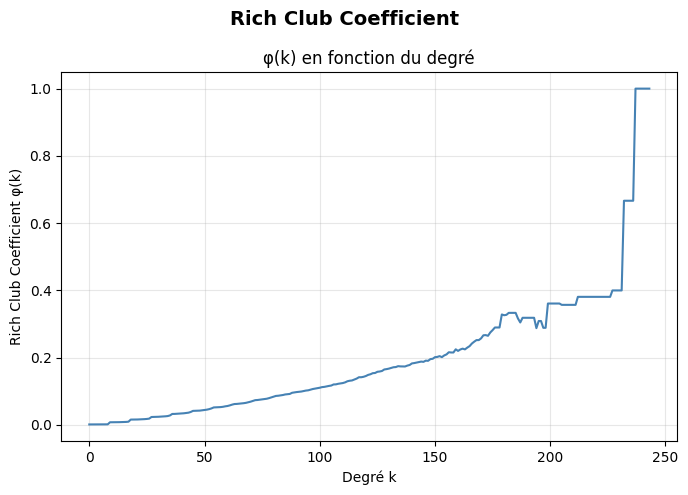

In [20]:
# Calcul
rich_club = nx.rich_club_coefficient(G, normalized=False)

degrees = sorted(rich_club.keys())
values  = [rich_club[k] for k in degrees]

# Infos
print("\nRich Club Coefficient :")
print(f"{'Degree k':>10} {'RC Coefficient':>15}")
for k, v in list(zip(degrees, values))[::max(1, len(degrees)//20)] :  # ~20 lignes
    print(f"{k:>10} {v:>15.4f}")

# Graphique
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
fig.suptitle("Rich Club Coefficient", fontsize=14, fontweight='bold')

# Courbe globale
ax.plot(degrees, values, color='steelblue', linewidth=1.5)
ax.set_xlabel("Degré k")
ax.set_ylabel("Rich Club Coefficient φ(k)")
ax.set_title("φ(k) en fonction du degré")
ax.grid(alpha=0.3)


plt.tight_layout()
plt.savefig("Images/Graph/rich_club.png", dpi=150, bbox_inches='tight')
plt.show()

---
## Analysis with "Unknown" excluded

In [21]:
DIMENSIONS = ['letter_1', 'letter_2', 'letter_3', 'letter_4']

# Exclude "Unknown"
nodes_to_keep = [n for n, attr in G.nodes(data=True)  if all(attr.get(dim) not in (None, 'Unknown') for dim in DIMENSIONS)]
G_filtered = G.subgraph(nodes_to_keep).copy()

print(f"Number of nodes before : {G.number_of_nodes():,}".replace(",", " "))
print(f"Number of nodes after  : {G_filtered.number_of_nodes():,}".replace(",", " "))
print(f"Number of links before : {G.number_of_edges():,}".replace(",", " "))
print(f"Number of links after  : {G_filtered.number_of_edges():,}".replace(",", " "))

# Rebuild the dictionary, same code as before without Unknown in LETTERS
LETTERS_FILTERED = {'letter_1': ['E', 'I'],
                    'letter_2': ['N', 'S'],
                    'letter_3': ['T', 'F'],
                    'letter_4': ['J', 'P']}

# Create dictionnary of links
def init_stats_dict_filtered() :
    stats = {}
    # From which dimension
    for src_dim in DIMENSIONS :
        stats[src_dim] = {}
        # To what dimension
        for tgt_dim in DIMENSIONS :
            stats[src_dim][tgt_dim] = {}
            # From which letter
            for from_val in LETTERS_FILTERED[src_dim]:
                # [totalLinks, Links_to_val1, Links_to_val2]
                stats[src_dim][tgt_dim][from_val] = [0, 0, 0]
    return stats

# Give the index to look at in the dictionnary
def get_val_filtered_index(tgt_dim, val) :
    possible = LETTERS_FILTERED[tgt_dim]
    return possible.index(val) + 1  # +1 car index 0 = total

def build_stats_filtered(G_filtered) :
    stats = init_stats_dict_filtered()

    for u, v in G_filtered.edges() :
        attrs_u = G_filtered.nodes[u]
        attrs_v = G_filtered.nodes[v]

        for src_dim in DIMENSIONS :
            from_val = attrs_u[src_dim]

            for tgt_dim in DIMENSIONS :
                to_val = attrs_v[tgt_dim]

                entry = stats[src_dim][tgt_dim][from_val]
                entry[0] += 1
                entry[get_val_filtered_index(tgt_dim, to_val)] += 1

    return stats

# Build dictionnary
stats_filtered = build_stats_filtered(G_filtered)

# Test
print("\n[Total links from E, From E to E, From E to I]")
print(stats_filtered['letter_1']['letter_1']['E'])
print("\n[Total links from I, From I to E, From I to I]")
print(stats_filtered['letter_1']['letter_1']['I'])

Number of nodes before : 11 637
Number of nodes after  : 2 446
Number of links before : 111 290
Number of links after  : 26 126

[Total links from E, From E to E, From E to I]
[14652, 8474, 6178]

[Total links from I, From I to E, From I to I]
[11474, 6080, 5394]


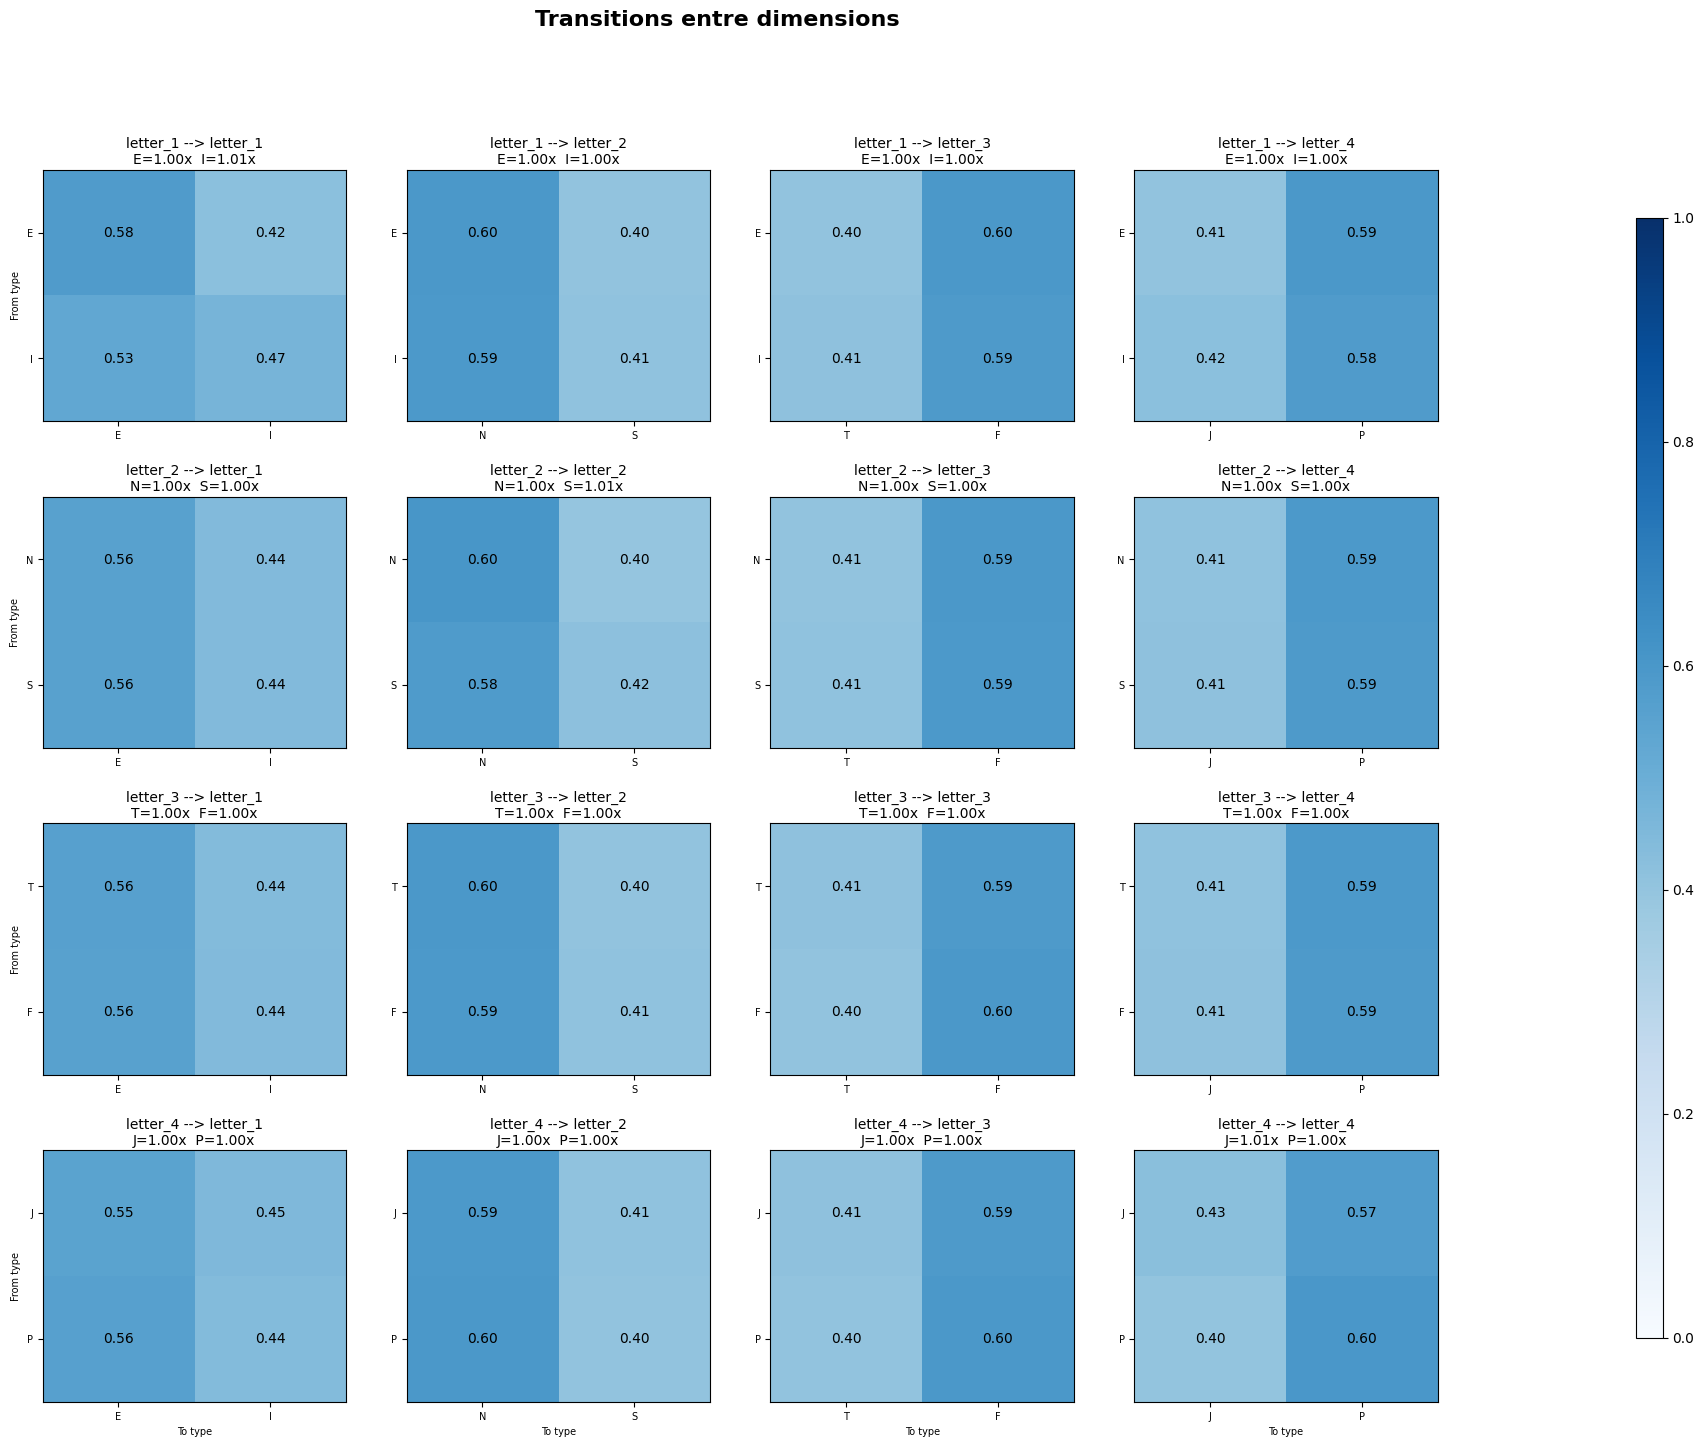

In [22]:
def plot_transition_matrix_filtered(stats) :
    DIMENSIONS = ['letter_1', 'letter_2', 'letter_3', 'letter_4']
    LETTERS = {'letter_1': ['E', 'I'],
                'letter_2': ['N', 'S'],
                'letter_3': ['T', 'F'],
                'letter_4': ['J', 'P']}

    fig, axes = plt.subplots(4, 4, figsize=(18, 16))
    fig.suptitle("Transitions entre dimensions", fontsize=16, fontweight='bold')

    for i, src_dim in enumerate(DIMENSIONS) :
        for j, tgt_dim in enumerate(DIMENSIONS) :
            ax = axes[i][j]
            src_vals = LETTERS[src_dim]   # from (axe Y)
            tgt_vals = LETTERS[tgt_dim]   # to (axe X)

            # Probability matrix
            matrix = np.zeros((len(src_vals), len(tgt_vals)))
            for r, from_val in enumerate(src_vals) :
                entry = stats[src_dim][tgt_dim][from_val]
                total = entry[0]
                # Avoid division by 0
                if total > 0 :
                    for c in range(len(tgt_vals)) :
                        matrix[r, c] = entry[c + 1] / total

            # Lift 
            all_counts = np.zeros(len(tgt_vals))
            all_total = 0
            for from_val in src_vals :
                entry = stats[src_dim][tgt_dim][from_val]
                all_total += entry[0]
                for c in range(len(tgt_vals)) :
                    all_counts[c] += entry[c + 1]
            marginal = all_counts / all_total if all_total > 0 else np.ones(len(tgt_vals)) / len(tgt_vals)

            lift_per_row = []
            for r, from_val in enumerate(src_vals) :
                row_observed = matrix[r]
                row_expected = marginal  # expected distribution
                with np.errstate(divide='ignore', invalid='ignore') :
                    row_lift = np.nanmean(np.where(row_expected > 0, row_observed / row_expected, np.nan))
                lift_per_row.append(f"{from_val}={row_lift:.2f}x")

            im = ax.imshow(matrix, vmin=0, vmax=1, cmap='Blues', aspect='auto')

            # Values in cell
            for r in range(len(src_vals)) :
                for c in range(len(tgt_vals)) :
                    ax.text(c, r, f"{matrix[r, c]:.2f}", ha='center', va='center', fontsize=10)

            # Set axes
            ax.set_xticks(range(len(tgt_vals)))
            ax.set_yticks(range(len(src_vals)))
            ax.set_xticklabels(tgt_vals, fontsize=7)
            ax.set_yticklabels(src_vals, fontsize=7)

            # Titre du subplot
            ax.set_title(f"{src_dim} --> {tgt_dim}\n" + "  ".join(lift_per_row), fontsize=10, pad=4)

            # Labels externes (seulement sur les bords)
            if i == 3 :
                ax.set_xlabel("To type", fontsize=7)
            if j == 0 :
                ax.set_ylabel("From type", fontsize=7)

    # Colorbar
    fig.subplots_adjust(wspace=0.2, hspace=0.3)
    cbar_ax = fig.add_axes([1.01, 0.15, 0.015, 0.7])
    fig.colorbar(im, cax=cbar_ax)

    plt.savefig("Images/Graph/transition_matrix_filtered.png", bbox_inches='tight', dpi=150)
    plt.show()

plot_transition_matrix_filtered(stats_filtered)

## Degree centrality filtered


  letter_1
   N nodes  Mean degree  Median degree
E     1397       20.906             12
I     1049       21.969             12

  letter_2
   N nodes  Mean degree  Median degree
N     1422       21.693             13
S     1024       20.902             11

  letter_3
   N nodes  Mean degree  Median degree
T      973       22.381             13
F     1473       20.689             12

  letter_4
   N nodes  Mean degree  Median degree
J     1022       21.226             12
P     1424       21.460             12


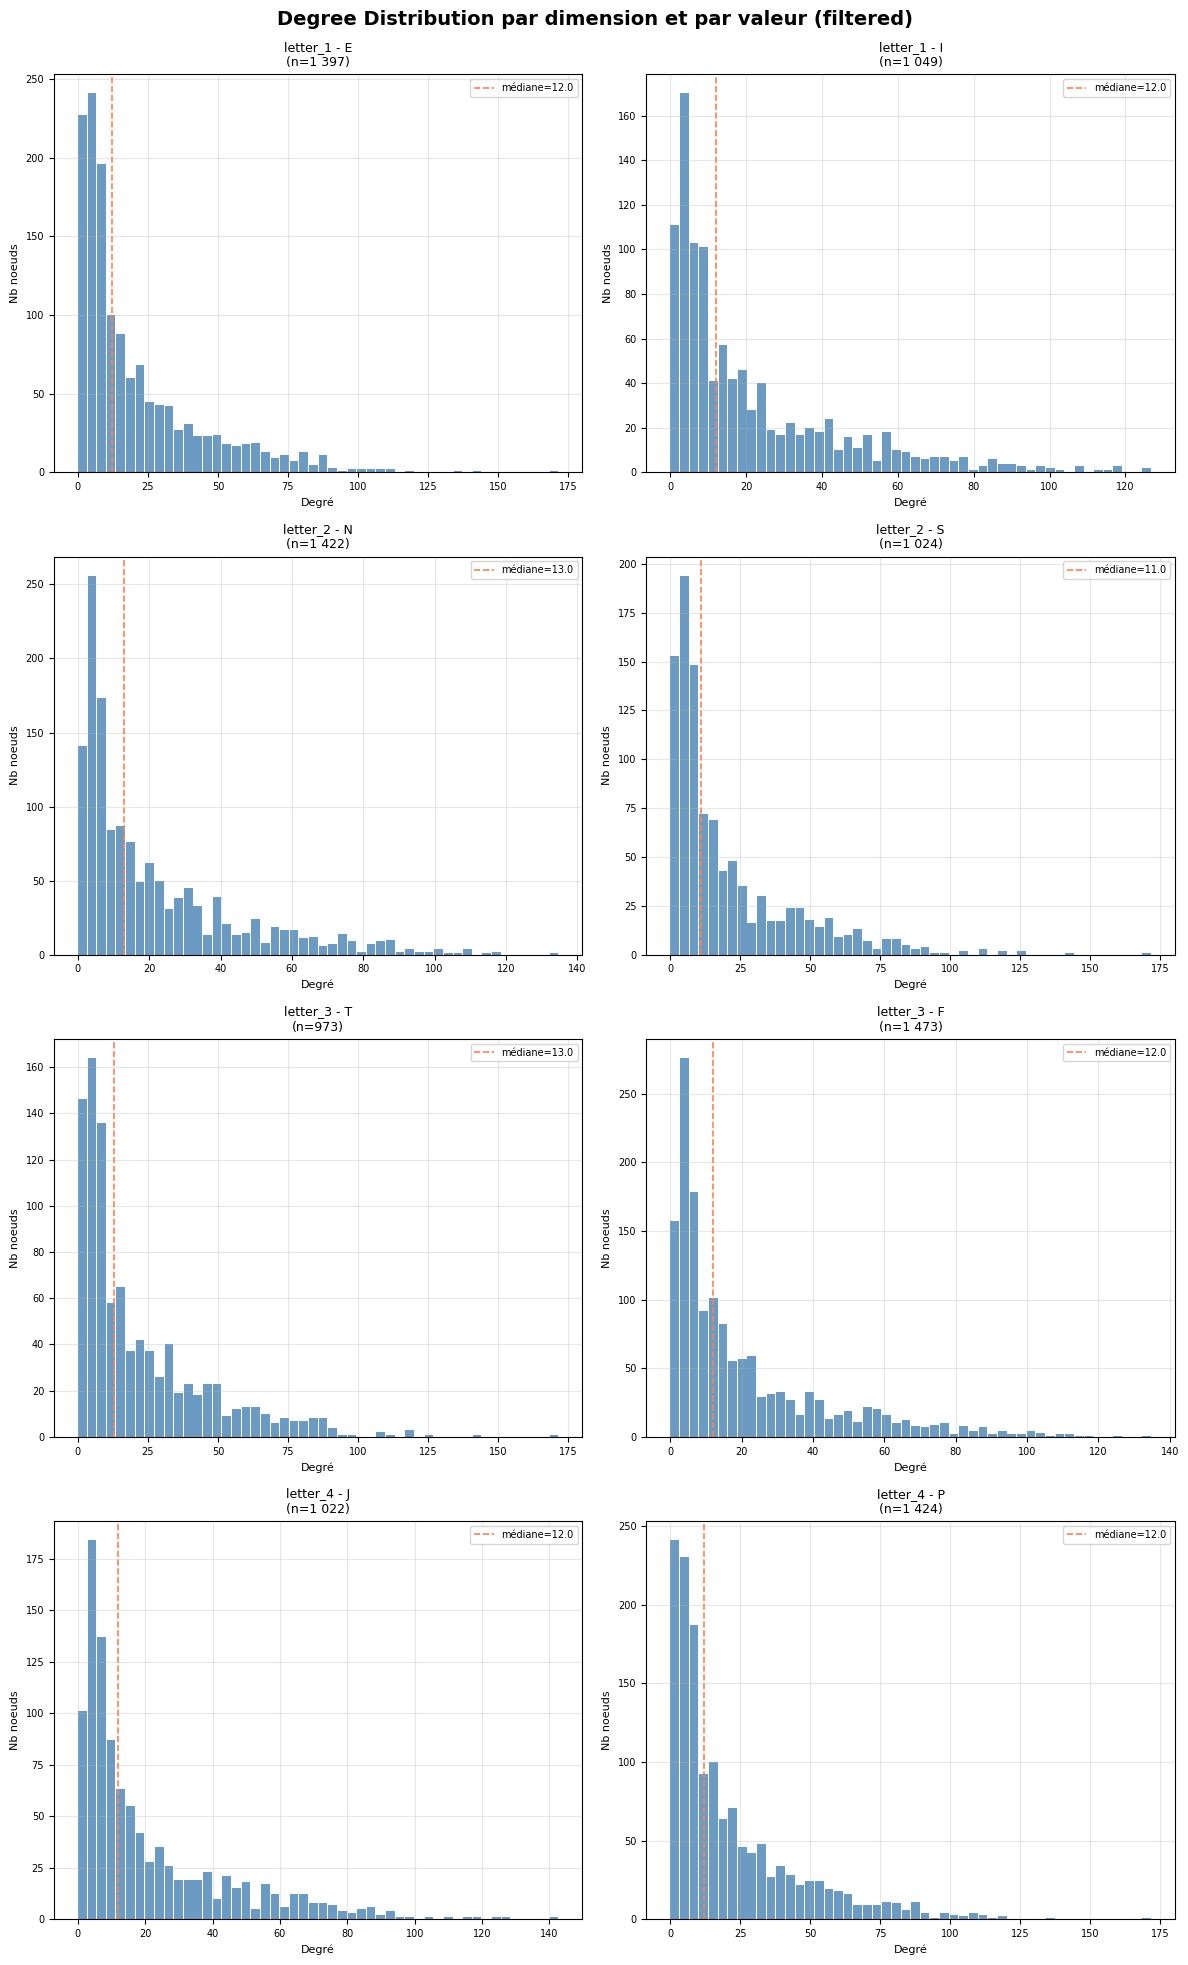

In [23]:
DIMENSIONS = ['letter_1', 'letter_2', 'letter_3', 'letter_4']
LETTERS_FILTERED = {'letter_1': ['E', 'I'],
                    'letter_2': ['N', 'S'],
                    'letter_3': ['T', 'F'],
                    'letter_4': ['J', 'P']}

# Calcul
degree_raw_filtered = dict(G_filtered.degree())

results_degree_filtered = {}
for dim in DIMENSIONS :
    results_degree_filtered[dim] = {}
    for val in LETTERS_FILTERED[dim] :
        nodes = [n for n, attr in G_filtered.nodes(data=True) if attr.get(dim) == val]
        vals  = [degree_raw_filtered[n] for n in nodes]
        results_degree_filtered[dim][val] = {'n_nodes': len(nodes),
                                              'mean'   : np.mean(vals)   if vals else None,
                                              'median' : np.median(vals) if vals else None}

# Infos
for dim in DIMENSIONS :
    print(f"\n{'='*50}\n  {dim}\n{'='*50}")
    df = pd.DataFrame(results_degree_filtered[dim]).T[['n_nodes', 'mean', 'median']]
    df.columns = ['N nodes', 'Mean degree', 'Median degree']
    df['N nodes']       = df['N nodes'].astype(int)
    df['Median degree'] = df['Median degree'].astype(int)
    df['Mean degree']   = df['Mean degree'].round(3)
    print(df.to_string())

# Graphique
fig, axes = plt.subplots(4, 2, figsize=(12, 20))
fig.suptitle("Degree Distribution par dimension et par valeur (filtered)\n", fontsize=14, fontweight='bold')

for i, dim in enumerate(DIMENSIONS) :
    for j, val in enumerate(LETTERS_FILTERED[dim]) :

        ax = axes[i][j]

        nodes = [n for n, attr in G_filtered.nodes(data=True) if attr.get(dim) == val]
        degs  = [degree_raw_filtered[n] for n in nodes]

        if not degs :
            ax.set_visible(False)
            continue

        counts, bin_edges = np.histogram(degs, bins=50)
        bin_widths = bin_edges[1:] - bin_edges[:-1]

        ax.bar(bin_edges[:-1], counts, width=bin_widths * 0.9, color='steelblue', alpha=0.8, align='edge')

        ax.set_title(f"{dim} - {val}\n(n={len(nodes):,})".replace(",", " "), fontsize=9)
        ax.set_xlabel("Degré", fontsize=8)
        ax.set_ylabel("Nb noeuds", fontsize=8)
        ax.grid(alpha=0.3)
        ax.tick_params(labelsize=7)

        median_deg = np.median(degs)
        ax.axvline(median_deg, color='coral', linestyle='--', linewidth=1.2, label=f"médiane={median_deg:.1f}")
        ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig("Images/Graph/degree_distribution_filtered.png", dpi=150, bbox_inches='tight')
plt.show()

## Betweenness Centrality Filtered


  letter_1
   N nodes  Mean betw.  Median betw.
E     1397    0.000750       0.00009
I     1049    0.000779       0.00011

  letter_2
   N nodes  Mean betw.  Median betw.
N     1422    0.000778      0.000106
S     1024    0.000740      0.000083

  letter_3
   N nodes  Mean betw.  Median betw.
T      973    0.000827      0.000126
F     1473    0.000719      0.000083

  letter_4
   N nodes  Mean betw.  Median betw.
J     1022    0.000749      0.000096
P     1424    0.000772      0.000098


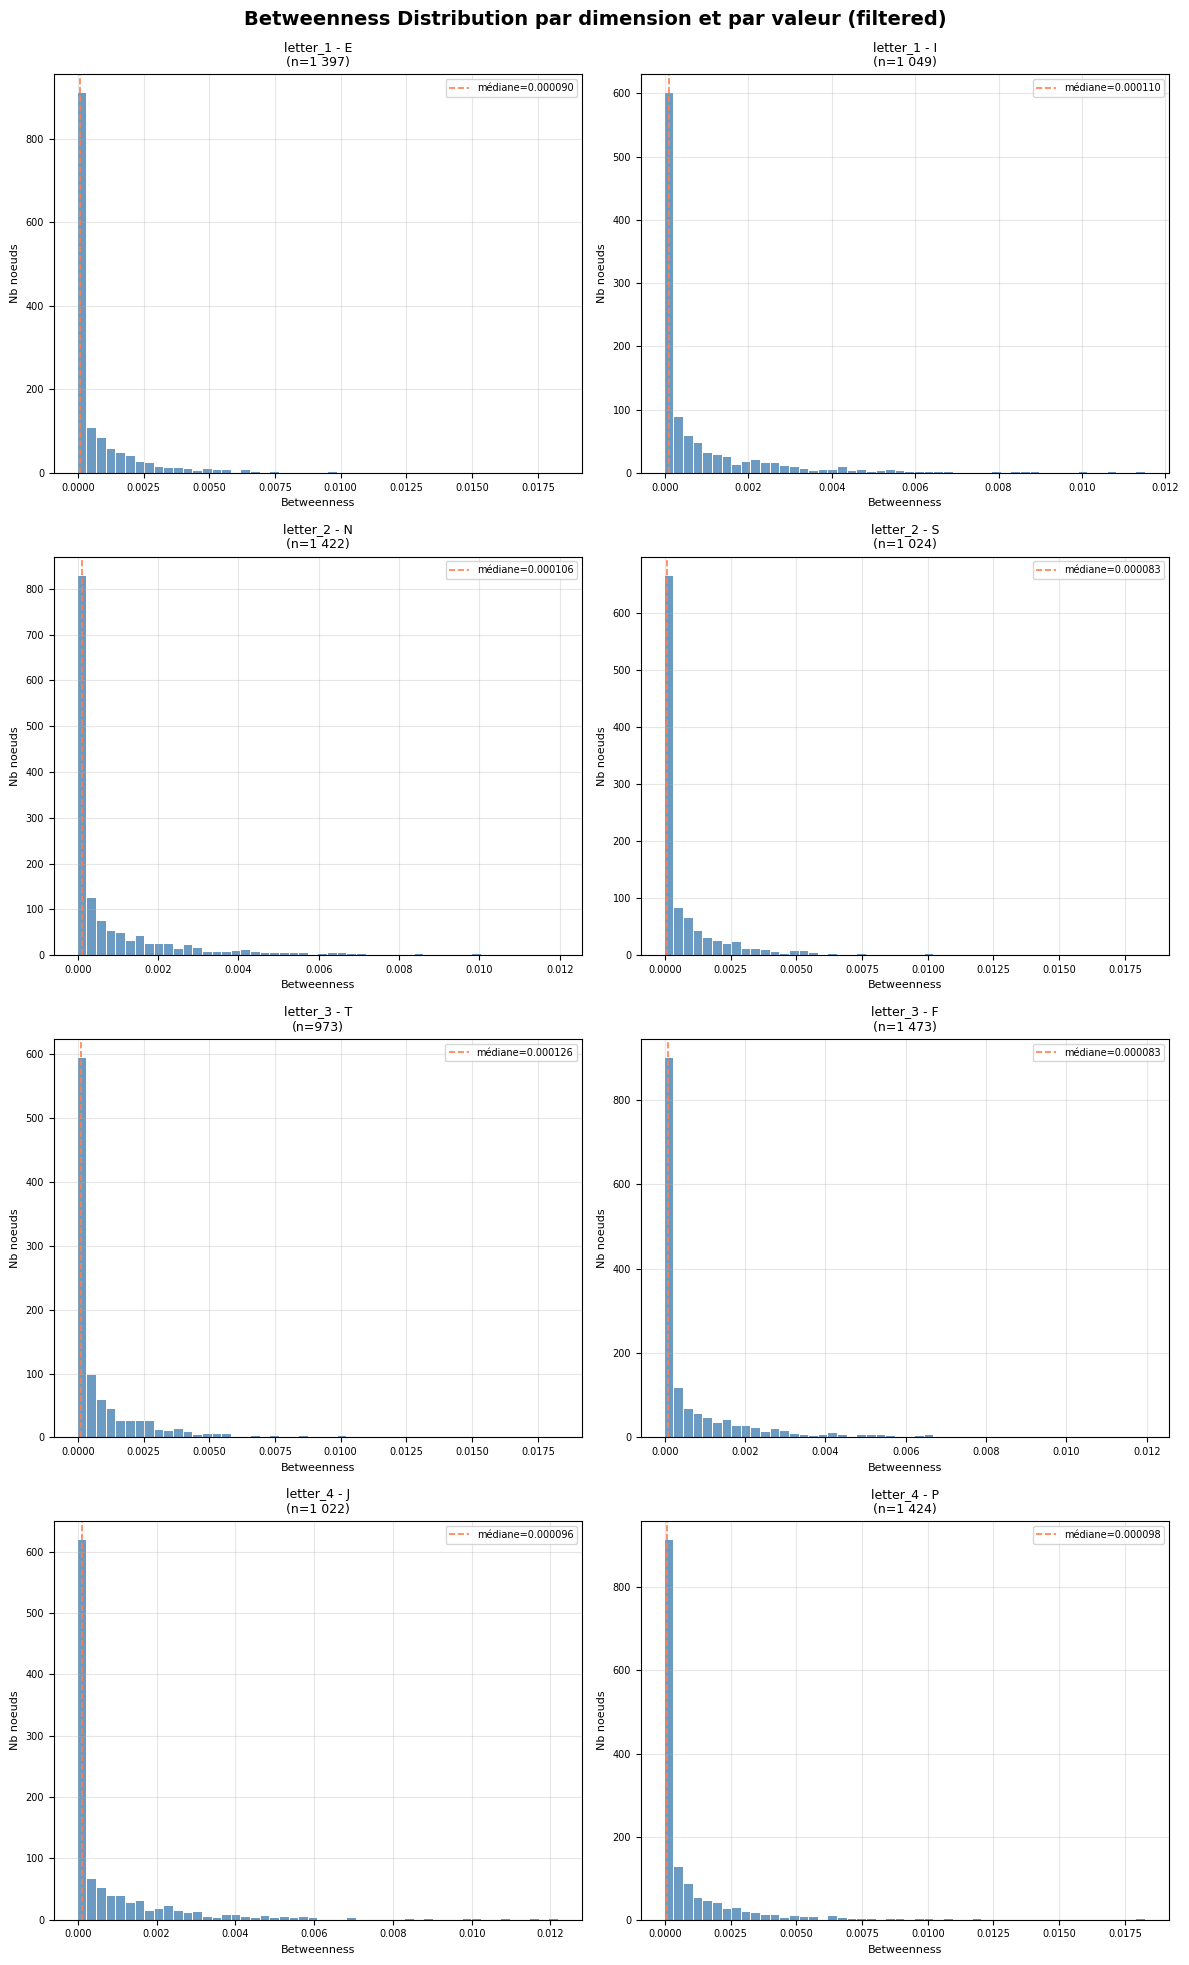

In [24]:
# Calcul
betweenness_filtered = nx.betweenness_centrality(G_filtered, normalized=True, k=500)

results_btw_filtered = {}
for dim in DIMENSIONS :
    results_btw_filtered[dim] = {}
    for val in LETTERS_FILTERED[dim] :
        nodes = [n for n, attr in G_filtered.nodes(data=True) if attr.get(dim) == val]
        vals  = [betweenness_filtered[n] for n in nodes]
        results_btw_filtered[dim][val] = {'n_nodes': len(nodes),
                                           'mean'   : np.mean(vals)   if vals else None,
                                           'median' : np.median(vals) if vals else None}

# Infos
for dim in DIMENSIONS :
    print(f"\n{'='*50}\n  {dim}\n{'='*50}")
    df = pd.DataFrame(results_btw_filtered[dim]).T[['n_nodes', 'mean', 'median']]
    df.columns = ['N nodes', 'Mean betw.', 'Median betw.']
    df['N nodes'] = df['N nodes'].astype(int)
    print(df.to_string())

# Graphique
fig, axes = plt.subplots(4, 2, figsize=(12, 20))
fig.suptitle("Betweenness Distribution par dimension et par valeur (filtered)\n", fontsize=14, fontweight='bold')

for i, dim in enumerate(DIMENSIONS) :
    for j, val in enumerate(LETTERS_FILTERED[dim]) :
        ax = axes[i][j]

        nodes = [n for n, attr in G_filtered.nodes(data=True) if attr.get(dim) == val]
        vals  = [betweenness_filtered[n] for n in nodes]

        if not vals :
            ax.set_visible(False)
            continue

        counts, bin_edges = np.histogram(vals, bins=50)
        bin_widths = bin_edges[1:] - bin_edges[:-1]

        ax.bar(bin_edges[:-1], counts, width=bin_widths * 0.9, color='steelblue', alpha=0.8, align='edge')

        ax.set_title(f"{dim} - {val}\n(n={len(nodes):,})".replace(",", " "), fontsize=9)
        ax.set_xlabel("Betweenness", fontsize=8)
        ax.set_ylabel("Nb noeuds", fontsize=8)
        ax.grid(alpha=0.3)
        ax.tick_params(labelsize=7)

        median_val = np.median(vals)
        ax.axvline(median_val, color='coral', linestyle='--', linewidth=1.2, label=f"médiane={median_val:.6f}")
        ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig("Images/Graph/betweenness_distribution_filtered.png", dpi=150, bbox_inches='tight')
plt.show()

## Closeness Centrality Filtered


  letter_1
   N nodes  Mean close.  Median close.
E     1397       0.3060         0.3160
I     1049       0.3049         0.3176

  letter_2
   N nodes  Mean close.  Median close.
N     1422       0.3056          0.317
S     1024       0.3055          0.316

  letter_3
   N nodes  Mean close.  Median close.
T      973       0.3073         0.3186
F     1473       0.3044         0.3157

  letter_4
   N nodes  Mean close.  Median close.
J     1022       0.3052         0.3158
P     1424       0.3058         0.3171


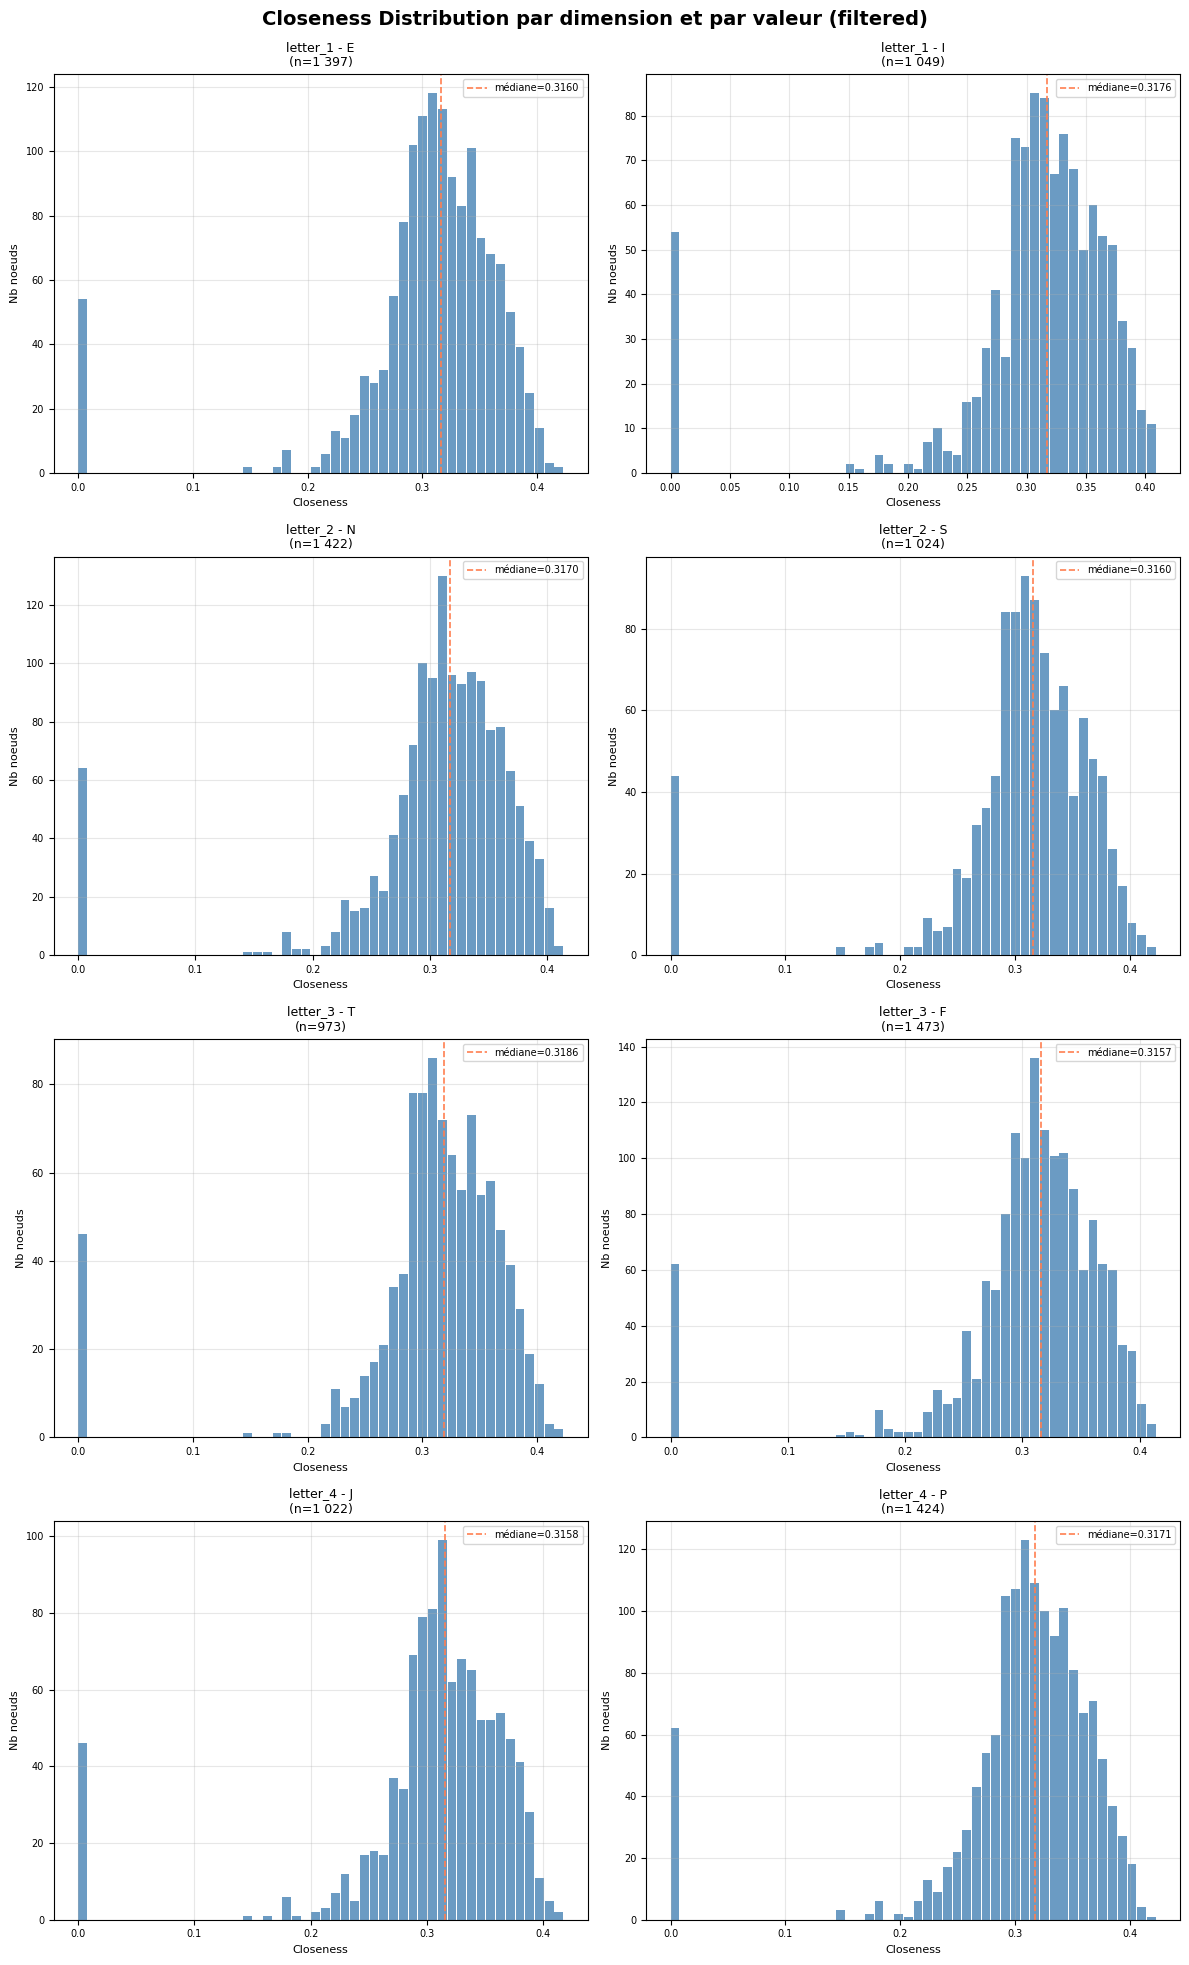

In [25]:
# Calcul
closeness_filtered = nx.closeness_centrality(G_filtered)

results_close = {}
for dim in DIMENSIONS :
    results_close[dim] = {}
    for val in LETTERS_FILTERED[dim] :
        nodes = [n for n, attr in G_filtered.nodes(data=True) if attr.get(dim, 'Unknown') == val]
        vals  = [closeness_filtered[n] for n in nodes]
        results_close[dim][val] = {'n_nodes': len(nodes),
                                    'mean'   : np.mean(vals)   if vals else None,
                                    'median' : np.median(vals) if vals else None}

# Infos
for dim in DIMENSIONS :
    print(f"\n{'='*50}\n  {dim}\n{'='*50}")
    df = pd.DataFrame(results_close[dim]).T[['n_nodes', 'mean', 'median']]
    df.columns = ['N nodes', 'Mean close.', 'Median close.']
    df['N nodes'] = df['N nodes'].astype(int)
    df['Median close.'] = df['Median close.'].round(4)
    df['Mean close.'] = df['Mean close.'].round(4)
    print(df.to_string())

# Graphique
fig, axes = plt.subplots(4, 2, figsize=(12, 20))
fig.suptitle("Closeness Distribution par dimension et par valeur (filtered)\n", fontsize=14, fontweight='bold')

for i, dim in enumerate(DIMENSIONS) :
    for j, val in enumerate(LETTERS_FILTERED[dim]) :
        ax = axes[i][j]

        nodes = [n for n, attr in G_filtered.nodes(data=True) if attr.get(dim, 'Unknown') == val]
        vals  = [closeness_filtered[n] for n in nodes]

        if not vals :
            ax.set_visible(False)
            continue

        counts, bin_edges = np.histogram(vals, bins=50)
        bin_widths = bin_edges[1:] - bin_edges[:-1]

        ax.bar(bin_edges[:-1], counts, width=bin_widths * 0.9, color='steelblue', alpha=0.8, align='edge')

        ax.set_title(f"{dim} - {val}\n(n={len(nodes):,})".replace(",", " "), fontsize=9)
        ax.set_xlabel("Closeness", fontsize=8)
        ax.set_ylabel("Nb noeuds", fontsize=8)
        ax.grid(alpha=0.3)
        ax.tick_params(labelsize=7)

        median_val = np.median(vals)
        ax.axvline(median_val, color='coral', linestyle='--', linewidth=1.2, label=f"médiane={median_val:.4f}")
        ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig("Images/Graph/closeness_distribution_filtered.png", dpi=150, bbox_inches='tight')
plt.show()


## Pagerank Centrality Filtered


  letter_1
   N nodes  Mean pagerank  Median pagerank
E     1397       0.000401         0.000273
I     1049       0.000419         0.000299

  letter_2
   N nodes  Mean pagerank  Median pagerank
N     1422       0.000413         0.000292
S     1024       0.000403         0.000279

  letter_3
   N nodes  Mean pagerank  Median pagerank
T      973       0.000422         0.000297
F     1473       0.000400         0.000279

  letter_4
   N nodes  Mean pagerank  Median pagerank
J     1022       0.000409         0.000285
P     1424       0.000409         0.000285


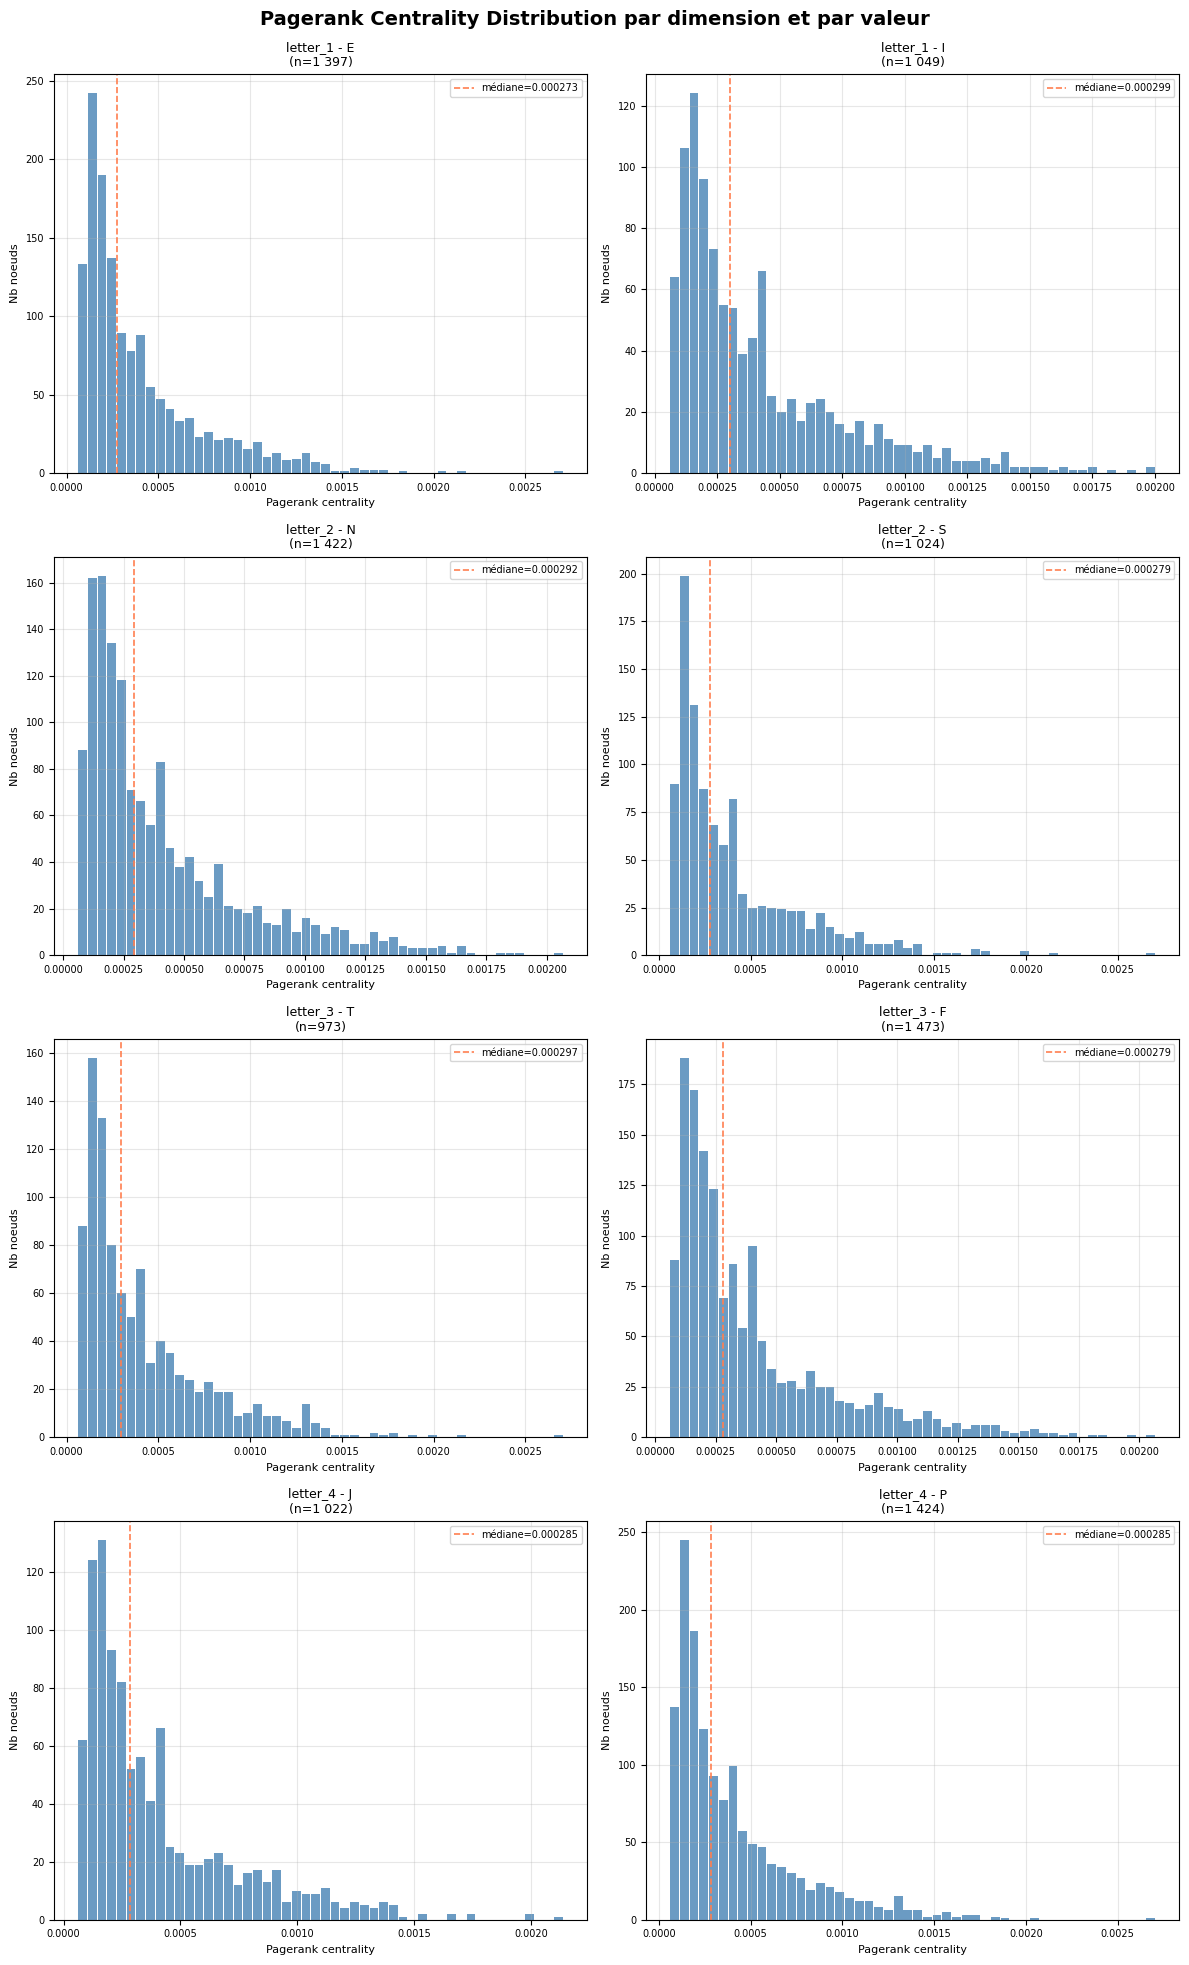

In [26]:
pagerank_filtered = nx.pagerank(G_filtered)

results_pagerank = {}
for dim in DIMENSIONS :
    results_pagerank[dim] = {}
    for val in LETTERS_FILTERED[dim] :
        nodes = [n for n, attr in G_filtered.nodes(data=True) if attr.get(dim, 'Unknown') == val]
        vals  = [pagerank_filtered[n] for n in nodes]
        results_pagerank[dim][val] = {'n_nodes': len(nodes),
                                        'mean'   : np.mean(vals)   if vals else None,
                                        'median' : np.median(vals) if vals else None}

# Infos
for dim in DIMENSIONS :
    print(f"\n{'='*50}\n  {dim}\n{'='*50}")
    df = pd.DataFrame(results_pagerank[dim]).T[['n_nodes', 'mean', 'median']]
    df.columns = ['N nodes', 'Mean pagerank', 'Median pagerank']
    df['N nodes'] = df['N nodes'].astype(int)
    print(df.to_string())

# Graphique
fig, axes = plt.subplots(4, 2, figsize=(12, 20))
fig.suptitle("Pagerank Centrality Distribution par dimension et par valeur\n", fontsize=14, fontweight='bold')

for i, dim in enumerate(DIMENSIONS) :
    for j, val in enumerate(LETTERS_FILTERED[dim]) :
        ax = axes[i][j]

        nodes = [n for n, attr in G_filtered.nodes(data=True) if attr.get(dim, 'Unknown') == val]
        vals  = [pagerank_filtered[n] for n in nodes]

        if not vals :
            ax.set_visible(False)
            continue

        counts, bin_edges = np.histogram(vals, bins=50)
        bin_widths = bin_edges[1:] - bin_edges[:-1]

        ax.bar(bin_edges[:-1], counts, width=bin_widths * 0.9, color='steelblue', alpha=0.8, align='edge')

        ax.set_title(f"{dim} - {val}\n(n={len(nodes):,})".replace(",", " "), fontsize=9)
        ax.set_xlabel("Pagerank centrality", fontsize=8)
        ax.set_ylabel("Nb noeuds", fontsize=8)
        ax.grid(alpha=0.3)
        ax.tick_params(labelsize=7)

        median_val = np.median(vals)
        ax.axvline(median_val, color='coral', linestyle='--', linewidth=1.2, label=f"médiane={median_val:.6f}")
        ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig("Images/Graph/pagerank_distribution_filtered.png", dpi=150, bbox_inches='tight')
plt.show()

## Eigenvector Centrality Filtered


  letter_1
   N nodes  Mean eig.  Median eig.
E     1397     0.0122       0.0060
I     1049     0.0133       0.0064

  letter_2
   N nodes  Mean eig.  Median eig.
N     1422     0.0129       0.0064
S     1024     0.0124       0.0058

  letter_3
   N nodes  Mean eig.  Median eig.
T      973     0.0134       0.0065
F     1473     0.0122       0.0059

  letter_4
   N nodes  Mean eig.  Median eig.
J     1022     0.0127       0.0058
P     1424     0.0126       0.0064


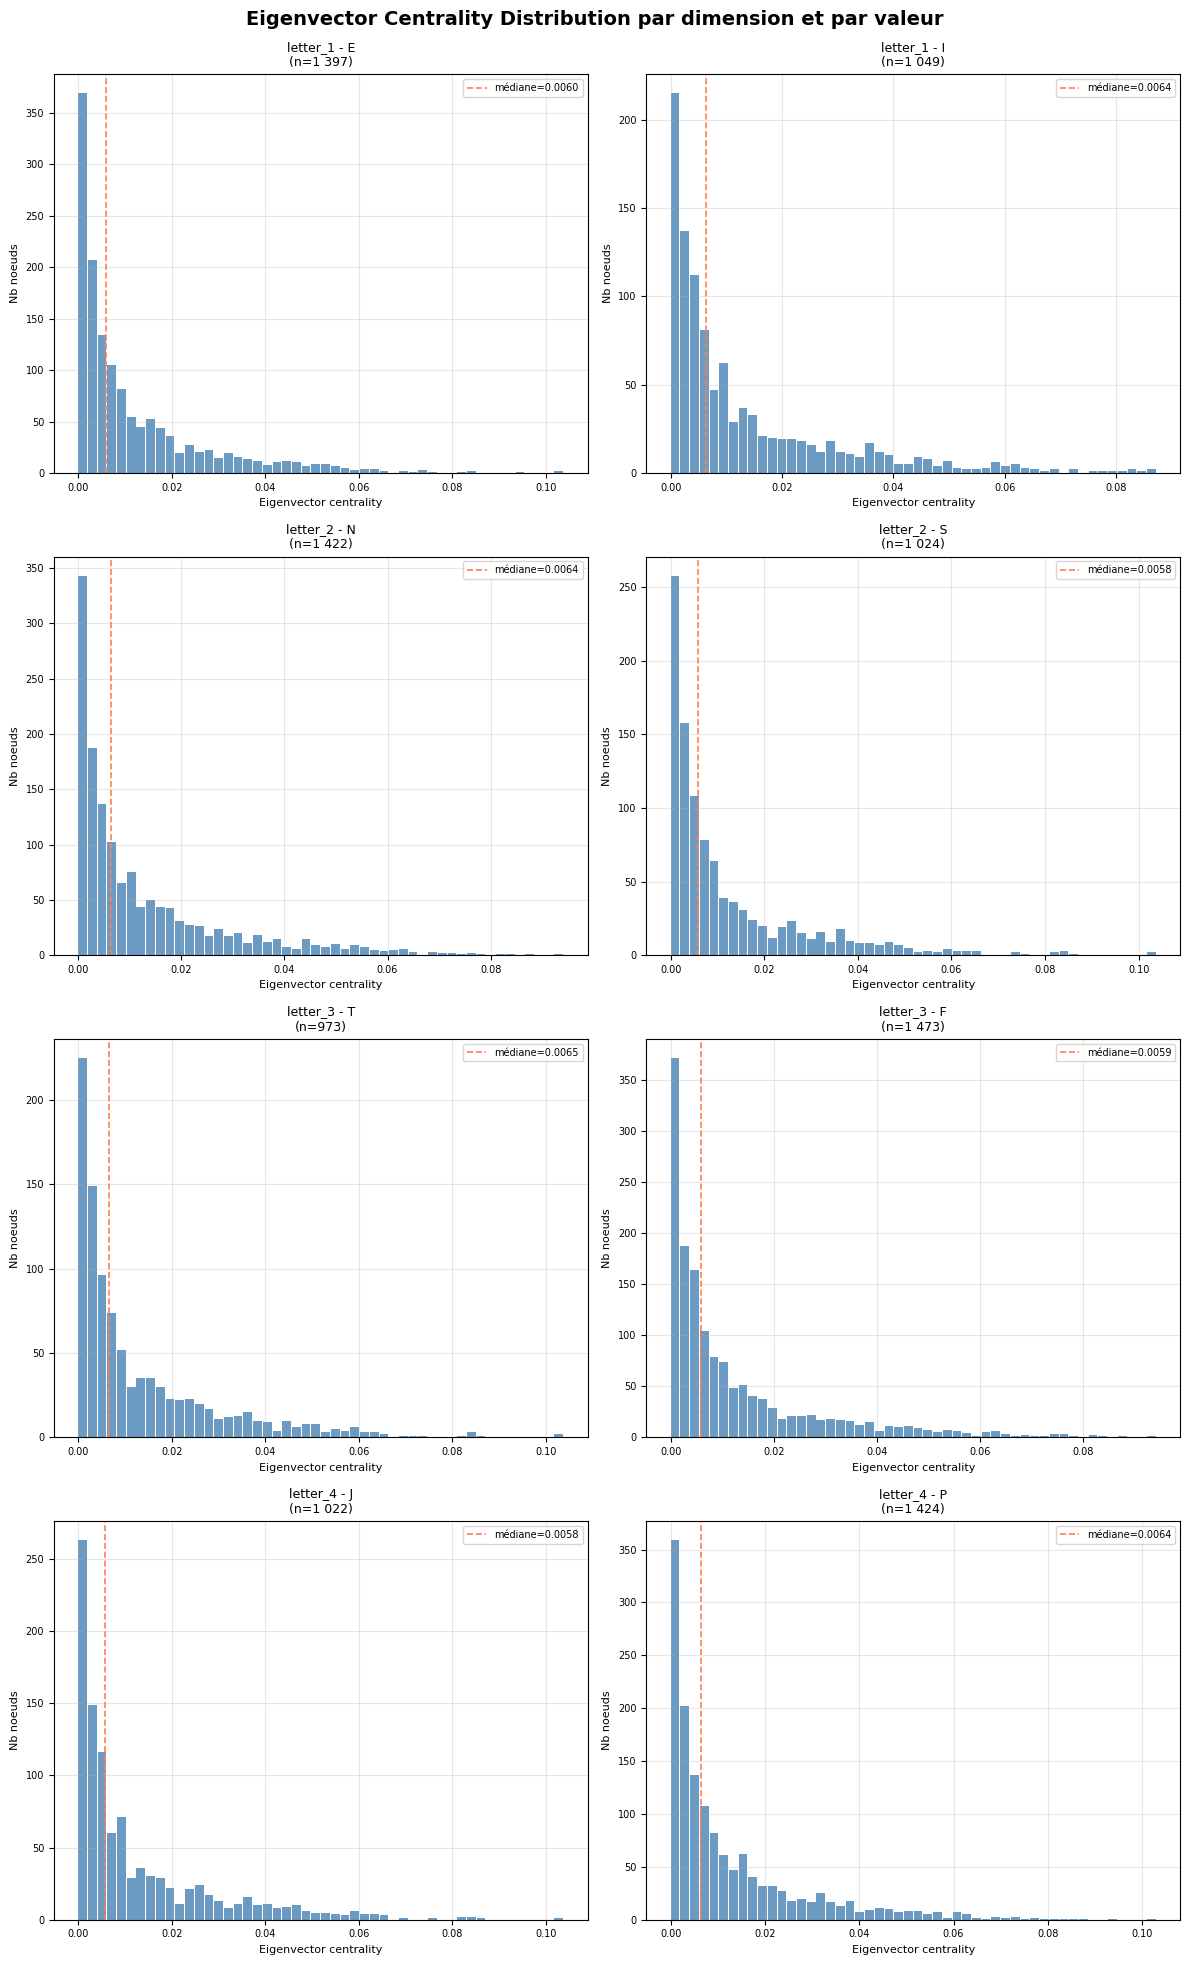

In [27]:
# Calcul
eigenvector_filtered = nx.eigenvector_centrality(G_filtered, max_iter=1000)

results_eig = {}
for dim in DIMENSIONS :
    results_eig[dim] = {}
    for val in LETTERS_FILTERED[dim] :
        nodes = [n for n, attr in G_filtered.nodes(data=True) if attr.get(dim, 'Unknown') == val]
        vals  = [eigenvector_filtered[n] for n in nodes]
        results_eig[dim][val] = {'n_nodes': len(nodes),
                                  'mean'   : np.mean(vals)   if vals else None,
                                  'median' : np.median(vals) if vals else None}

# Infos
for dim in DIMENSIONS:
    print(f"\n{'='*50}\n  {dim}\n{'='*50}")
    df = pd.DataFrame(results_eig[dim]).T[['n_nodes', 'mean', 'median']]
    df.columns = ['N nodes', 'Mean eig.', 'Median eig.']
    df['N nodes'] = df['N nodes'].astype(int)
    df['Mean eig.'] = df['Mean eig.'].round(4)
    df['Median eig.'] = df['Median eig.'].round(4)
    print(df.to_string())

# Graphique
fig, axes = plt.subplots(4, 2, figsize=(12, 20))
fig.suptitle("Eigenvector Centrality Distribution par dimension et par valeur\n", fontsize=14, fontweight='bold')

for i, dim in enumerate(DIMENSIONS) :
    for j, val in enumerate(LETTERS_FILTERED[dim]) :
        ax = axes[i][j]

        nodes = [n for n, attr in G_filtered.nodes(data=True) if attr.get(dim, 'Unknown') == val]
        vals  = [eigenvector_filtered[n] for n in nodes]

        if not vals :
            ax.set_visible(False)
            continue

        counts, bin_edges = np.histogram(vals, bins=50)
        bin_widths = bin_edges[1:] - bin_edges[:-1]

        ax.bar(bin_edges[:-1], counts, width=bin_widths * 0.9, color='steelblue', alpha=0.8, align='edge')

        ax.set_title(f"{dim} - {val}\n(n={len(nodes):,})".replace(",", " "), fontsize=9)
        ax.set_xlabel("Eigenvector centrality", fontsize=8)
        ax.set_ylabel("Nb noeuds", fontsize=8)
        ax.grid(alpha=0.3)
        ax.tick_params(labelsize=7)

        median_val = np.median(vals)
        ax.axvline(median_val, color='coral', linestyle='--', linewidth=1.2, label=f"médiane={median_val:.4f}")
        ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig("Images/Graph/eigenvector_distribution_filtered.png", dpi=150, bbox_inches='tight')
plt.show()

## Clustering Centrality Filtered


  letter_1
   N nodes  Mean clust.  Median clust.
E     1397        0.474          0.333
I     1049        0.448          0.306

  letter_2
   N nodes  Mean clust.  Median clust.
N     1422        0.456          0.311
S     1024        0.471          0.333

  letter_3
   N nodes  Mean clust.  Median clust.
T      973        0.466          0.321
F     1473        0.460          0.333

  letter_4
   N nodes  Mean clust.  Median clust.
J     1022        0.458          0.330
P     1424        0.466          0.327


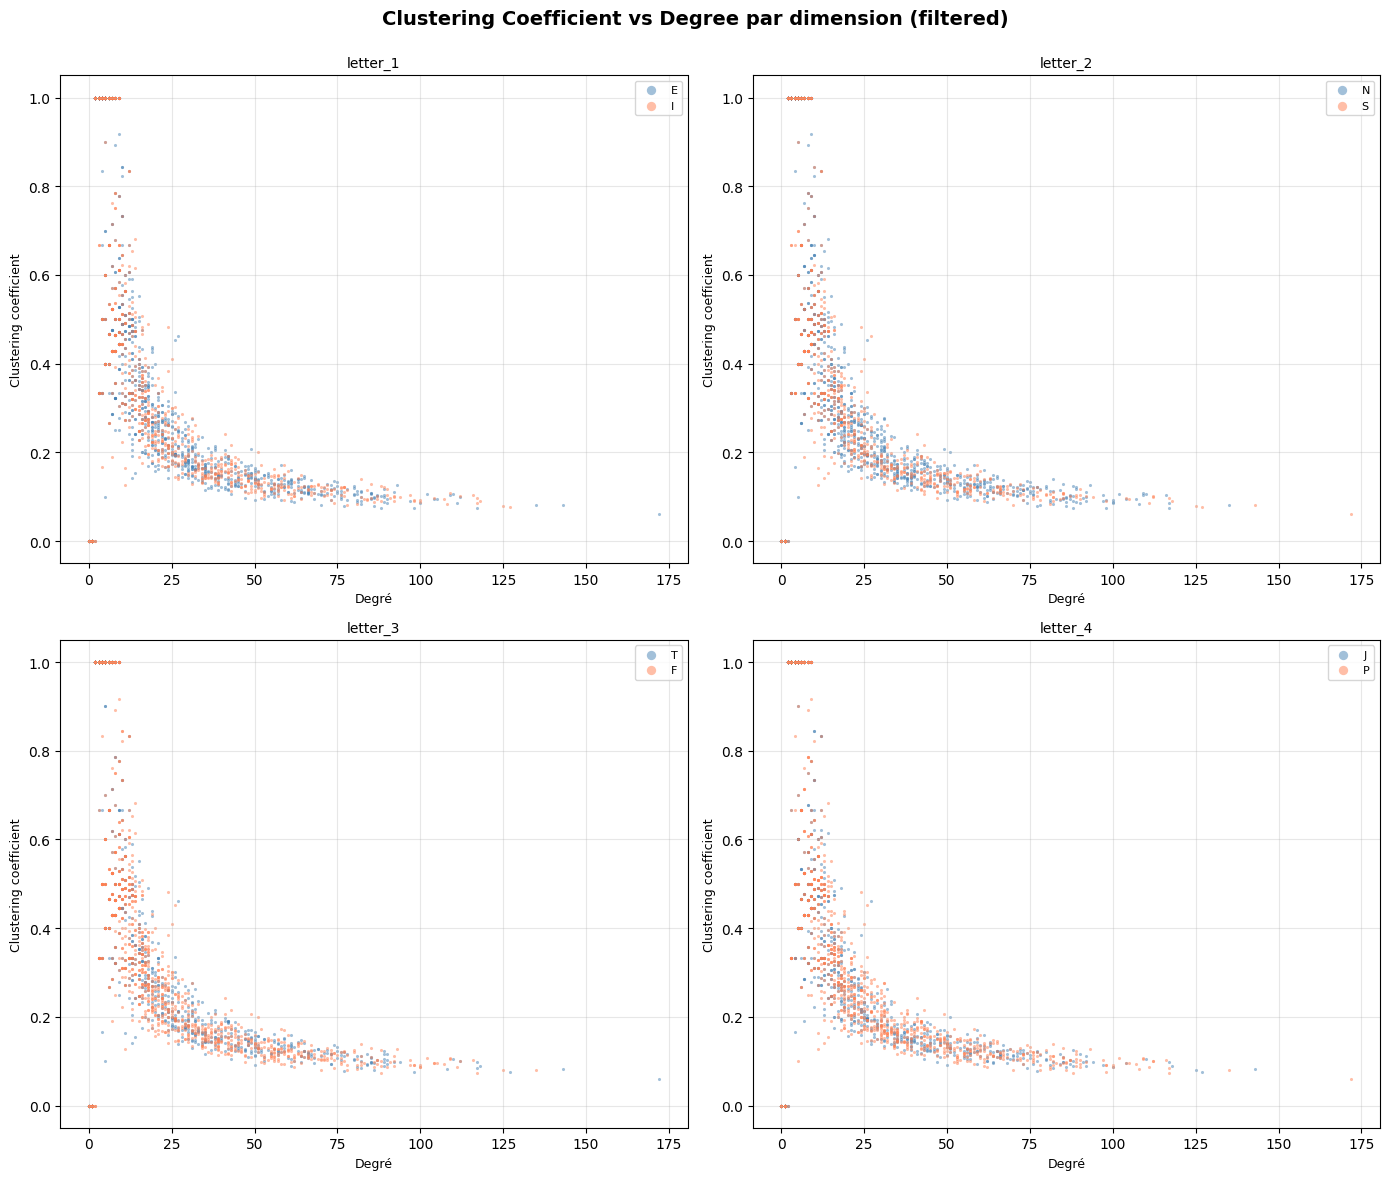

In [28]:
# Calcul
clustering_filtered = nx.clustering(G_filtered)
degree_raw_filtered = dict(G_filtered.degree())

results_clust = {}
for dim in DIMENSIONS :
    results_clust[dim] = {}
    for val in LETTERS_FILTERED[dim] :
        nodes = [n for n, attr in G_filtered.nodes(data=True) if attr.get(dim, 'Unknown') == val]
        vals  = [clustering_filtered[n] for n in nodes]
        results_clust[dim][val] = {'n_nodes': len(nodes),
                                    'mean'   : np.mean(vals)   if vals else None,
                                    'median' : np.median(vals) if vals else None}

# Infos
for dim in DIMENSIONS :
    print(f"\n{'='*50}\n  {dim}\n{'='*50}")
    df = pd.DataFrame(results_clust[dim]).T[['n_nodes', 'mean', 'median']]
    df.columns = ['N nodes', 'Mean clust.', 'Median clust.']
    df['N nodes'] = df['N nodes'].astype(int)
    df['Mean clust.'] = df['Mean clust.'].round(3)
    df['Median clust.'] = df['Median clust.'].round(3)
    print(df.to_string())

# Graphique
COLORS_FILTERED = {'E': 'steelblue', 'I': 'coral',
                    'N': 'steelblue', 'S': 'coral',
                    'T': 'steelblue', 'F': 'coral',
                    'J': 'steelblue', 'P': 'coral'}

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle("Clustering Coefficient vs Degree par dimension (filtered)\n", fontsize=14, fontweight='bold')

for idx, dim in enumerate(DIMENSIONS) :
    ax = axes[idx // 2][idx % 2]

    for val in LETTERS_FILTERED[dim] :
        nodes = [n for n, attr in G_filtered.nodes(data=True) if attr.get(dim, 'Unknown') == val]

        if not nodes :
            continue

        x = [degree_raw_filtered[n] for n in nodes]
        y = [clustering_filtered[n] for n in nodes]

        ax.scatter(x, y, label=val, color=COLORS_FILTERED[val], alpha=0.5, s=5, linewidths=0)

    ax.set_title(dim, fontsize=10)
    ax.set_xlabel("Degré", fontsize=9)
    ax.set_ylabel("Clustering coefficient", fontsize=9)
    ax.legend(fontsize=8, markerscale=3)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("Images/Graph/clustering_vs_degree_filtered.png", dpi=150, bbox_inches='tight')
plt.show()

## Rich Club Centrality Filtered


Rich Club Coefficient :
  Degree k  RC Coefficient
         0          0.0091
         7          0.0194
        14          0.0315
        21          0.0448
        28          0.0584
        35          0.0739
        42          0.0889
        49          0.1044
        56          0.1256
        63          0.1502
        70          0.1758
        77          0.2025
        84          0.2279
        91          0.2841
        98          0.3067
       105          0.3529
       112          0.3111
       119          0.7000
       126          0.5000
       133          0.6667
       140          0.0000


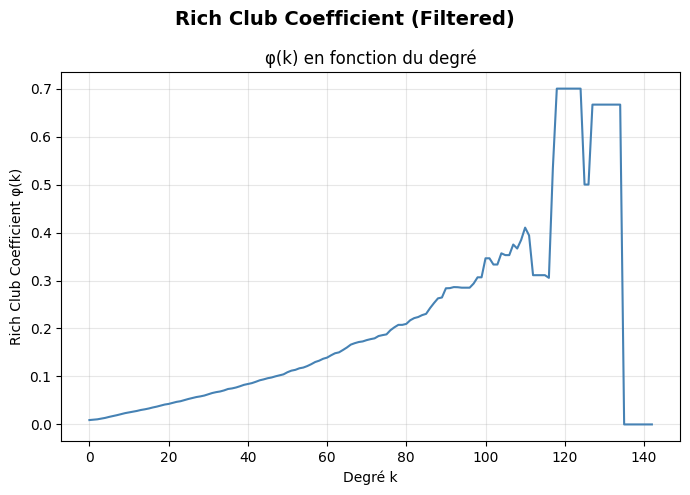

In [29]:
# Calcul
rich_club_filtered = nx.rich_club_coefficient(G_filtered, normalized=False)

degrees_filtered = sorted(rich_club_filtered.keys())
values_filtered  = [rich_club_filtered[k] for k in degrees_filtered]

# Infos
print("\nRich Club Coefficient :")
print(f"{'Degree k':>10} {'RC Coefficient':>15}")
for k, v in list(zip(degrees_filtered, values_filtered))[::max(1, len(degrees_filtered)//20)] :  # ~20 lignes
    print(f"{k:>10} {v:>15.4f}")

# Graphique
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
fig.suptitle("Rich Club Coefficient (Filtered)", fontsize=14, fontweight='bold')

# Courbe globale
ax.plot(degrees_filtered, values_filtered, color='steelblue', linewidth=1.5)
ax.set_xlabel("Degré k")
ax.set_ylabel("Rich Club Coefficient φ(k)")
ax.set_title("φ(k) en fonction du degré")
ax.grid(alpha=0.3)


plt.tight_layout()
plt.savefig("Images/Graph/rich_club_filtered.png", dpi=150, bbox_inches='tight')
plt.show()

---
# Heterophiliy

In [30]:
def get_top_actors(cast_json, nbr) :
    try :
        cast_list = json.loads(cast_json)
        top = [actor['name'] for actor in cast_list]
        while len(top) < nbr :
            top.append(None)
        return top[:nbr]
    except :
        return [None] * nbr
        
def get_actors_by_film(data, nbr_actors=3, firstyear=1, lastyear=3000, genre=None, minscore=0, maxscore=10) :

    df = data.copy()

    # Filtre par genre
    if genre is not None :
        df = df[df['genres'].str.contains(genre, na=False)]

    # S'assurer que release_date est bien en datetime
    df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
    # Extraire l'année
    df['release_year'] = df['release_date'].dt.year
    # Filtre par année et score
    df = df[(df['release_year'] >= firstyear) &
            (df['release_year'] <= lastyear) &
            (df['vote_average'] >= minscore) &
            (df['vote_average'] <= maxscore)]

    # Sélection des colonnes utiles
    df = df[['original_title', 'cast', 'release_year']]

    # Garder seulement les lignes où 'cast' contient au moins nbr_actors acteurs
    #df = df[df['cast'].apply(lambda x: len(json.loads(x)) >= nbr_actors)]

    # Une seule colonne 'actors' contenant une liste
    df['actors'] = df['cast'].apply(lambda x: get_top_actors(x, nbr_actors))

    return df

db_actors = get_actors_by_film(data, nbr_actors=10, firstyear=1990, lastyear=2009)

In [31]:
# Memory for actors extracted by film
memory = []

for actors in db_actors['actors'] :
    actors_list = [x for x in actors if x is not None] # Remove None values
    size = len(actors)

    actors_in_graph = set(actors)
    # Actors in the MBTI database (names matched)
    actors_in_mbti = set(mbti['name_cleaned'].tolist())
    
    # Intersection: actors present in both
    common_actors = actors_in_graph & actors_in_mbti

    #print(f"\nNumber of actors taken in the film : {size:,}".replace(",", " "))
    #print(f"Number of actors matched with MBTI : {len(common_actors):,}".replace(",", " "))

    memory.append((size, common_actors))



In [32]:
# Statistics of repartition by type by film
# [(size,"not defined"), [E,I], [S,N], [T,F], [J,P]]
stats = []

for s, a in memory :

    counter_letter_1 = [0, 0]
    counter_letter_2 = [0, 0]
    counter_letter_3 = [0, 0]
    counter_letter_4 = [0, 0]
    actors_to_find = list(a)
    result = mbti[mbti['name_cleaned'].isin(actors_to_find)]


    # Count number of iteration of letters
    for idx, row in result.iterrows() :
        letter_1 = row.get('letter_1', 'Unknown')
        letter_2 = row.get('letter_2', 'Unknown')
        letter_3 = row.get('letter_3', 'Unknown')
        letter_4 = row.get('letter_4', 'Unknown')

        if letter_1 == "E" :
            counter_letter_1[0] += 1
        else : 
            counter_letter_1[1] += 1

        if letter_2 == "S" :
            counter_letter_2[0] += 1
        else : 
            counter_letter_2[1] += 1

        if letter_3 == "T" :
            counter_letter_3[0] += 1
        else : 
            counter_letter_3[1] += 1

        if letter_4 == "J" :
            counter_letter_4[0] += 1
        else : 
            counter_letter_4[1] += 1
        
    stats.append([(s, s - len(result)), counter_letter_1, counter_letter_2, counter_letter_3, counter_letter_4])


In [33]:
film_with_stats = []
just_1_match = []
film_without_stats = []
for s in stats :
    if s[0][0] == s[0][1] : 
        film_without_stats.append(s)
    elif s[0][0] == s[0][1] + 1 : 
        just_1_match.append(s)
    else :
        film_with_stats.append(s)
    
print(f"Number of films                    : {len(stats):,} ({len(stats)/len(stats)*100:.1f}%)".replace(",", " "))
print(f"\nNumber of films with a match MBTI  : {len(film_with_stats):,} ({len(film_with_stats)/len(stats)*100:.2f}%)".replace(",", " "))
print(f"Number of films just 1 actor match : {len(just_1_match):,}   ({len(just_1_match)/len(stats)*100:.2f}%)".replace(",", " "))
print(f"Number of films with no match MBTI : {len(film_without_stats):,}   ({len(film_without_stats)/len(stats)*100:.2f}%)".replace(",", " "))

Number of films                    : 2 826 (100.0%)

Number of films with a match MBTI  : 2 417 (85.53%)
Number of films just 1 actor match : 209   (7.40%)
Number of films with no match MBTI : 200   (7.08%)


=== Score d'hétérophilie (entropie normalisée) ===
count    2417.000
mean        0.747
std         0.204
min         0.000
25%         0.656
50%         0.811
75%         0.909
max         1.000
Name: hetero_score, dtype: float64

Films très homogènes  (score < 0.25) : 60
Films mixtes          (0.25–0.75)    : 1005
Films très hétérogènes(score > 0.75) : 1352


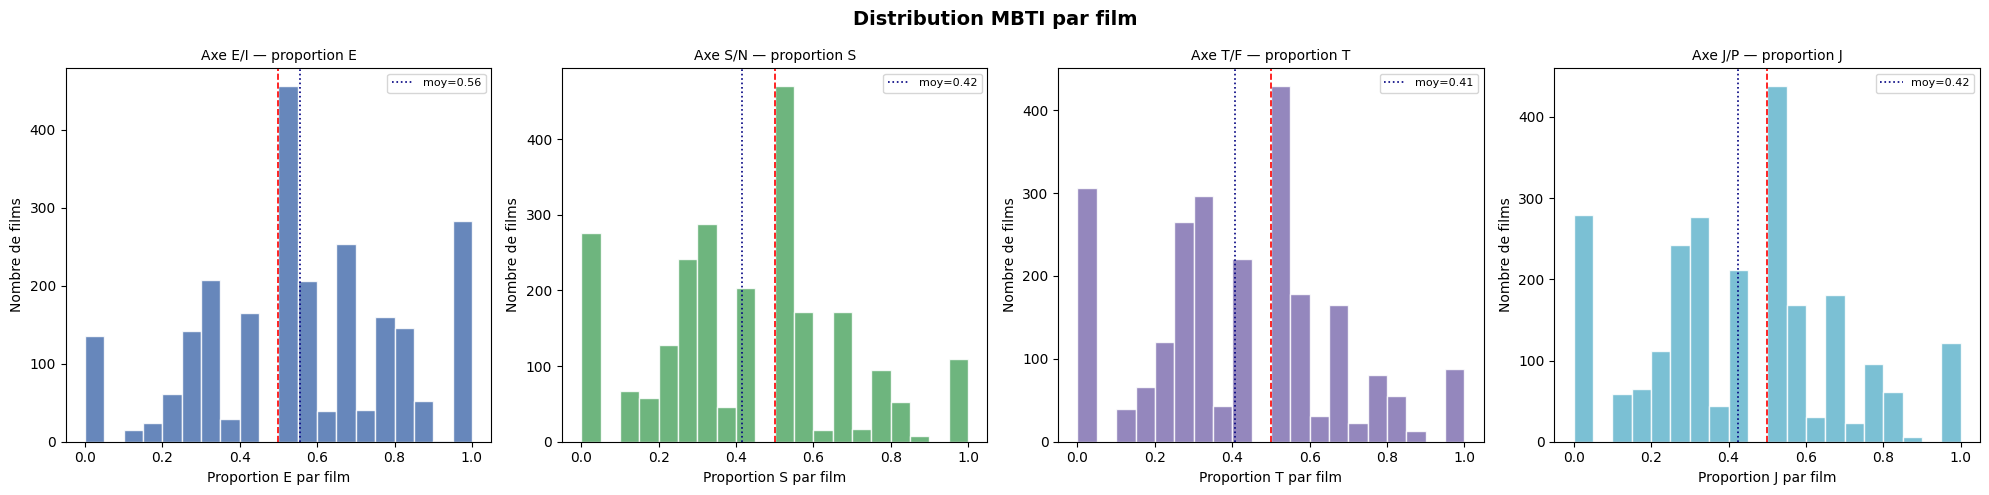

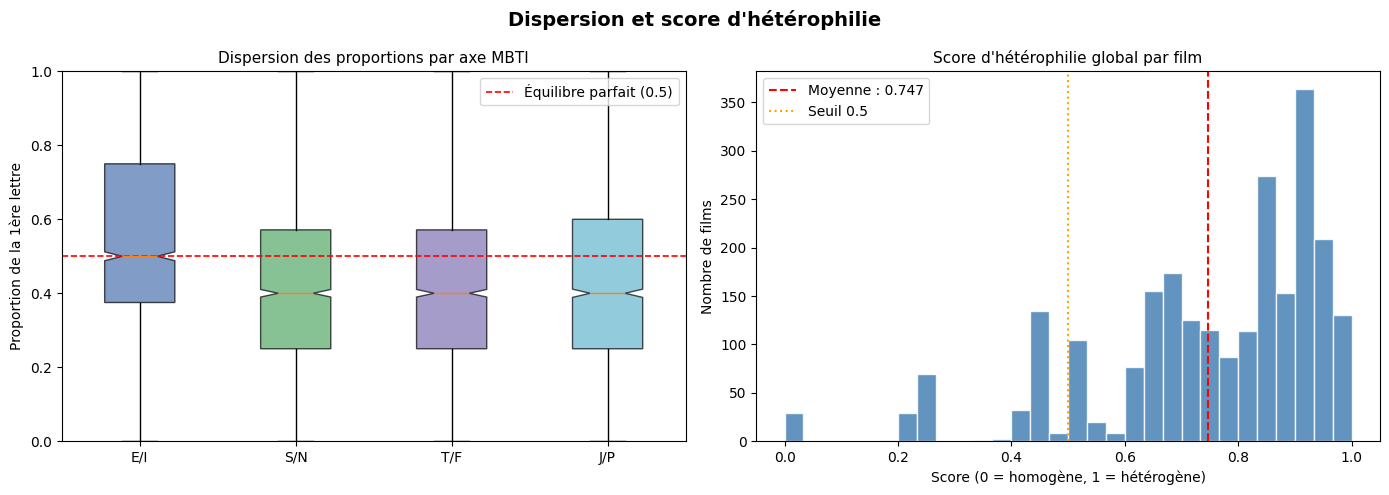

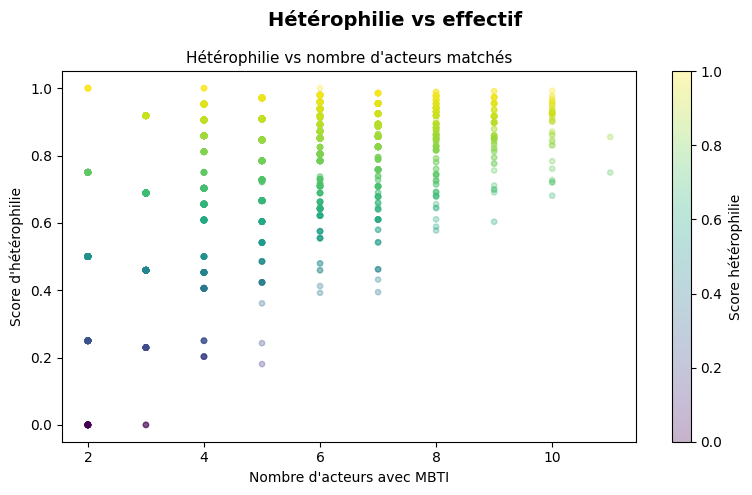

In [34]:
# distributions par film

records = []

for s in film_with_stats :
    (total, unmatched), c1, c2, c3, c4 = s
    matched = total - unmatched

    # Proportions par lettre (sur les acteurs matchés)
    def prop(counter) :
        total_c = sum(counter)
        if total_c == 0 :
            return (None, None)
        return (counter[0] / total_c, counter[1] / total_c)

    p1 = prop(c1)  # E / I
    p2 = prop(c2)  # S / N
    p3 = prop(c3)  # T / F
    p4 = prop(c4)  # J / P

    records.append({'matched'    : matched,
                    'E'          : c1[0], 'I': c1[1],
                    'S'          : c2[0], 'N': c2[1],
                    'T'          : c3[0], 'F': c3[1],
                    'J'          : c4[0], 'P': c4[1],
                    'prop_E'     : p1[0], 'prop_I': p1[1],
                    'prop_S'     : p2[0], 'prop_N': p2[1],
                    'prop_T'     : p3[0], 'prop_F': p3[1],
                    'prop_J'     : p4[0], 'prop_P': p4[1]})

df_dist = pd.DataFrame(records)


# hétérophilie par film
# 1.0 = parfaitement mixte, 0.0 = monotype

def entropy_norm(p) :
    if p is None or p == 0 or p == 1:
        return 0.0
    q = 1 - p
    return -(p * np.log2(p) + q * np.log2(q))  # max = 1 pour p=0.5

df_dist['hetero_score'] = (df_dist['prop_E'].apply(entropy_norm) +
                            df_dist['prop_S'].apply(entropy_norm) +
                            df_dist['prop_T'].apply(entropy_norm) +
                            df_dist['prop_J'].apply(entropy_norm)) / 4  # moyenne sur les 4 axes -> [0, 1]

print("=== Score d'hétérophilie (entropie normalisée) ===")
print(df_dist['hetero_score'].describe().round(3))
print(f"\nFilms très homogènes  (score < 0.25) : {(df_dist['hetero_score'] < 0.25).sum()}")
print(f"Films mixtes          (0.25–0.75)    : {((df_dist['hetero_score'] >= 0.25) & (df_dist['hetero_score'] <= 0.75)).sum()}")
print(f"Films très hétérogènes(score > 0.75) : {(df_dist['hetero_score'] > 0.75).sum()}")

# Visualisation

pairs = [('prop_E', 'prop_I', 'E', 'I', '#4C72B0', '#DD8452'),
        ('prop_S', 'prop_N', 'S', 'N', '#55A868', '#C44E52'),
        ('prop_T', 'prop_F', 'T', 'F', '#8172B2', '#CCB974'),
        ('prop_J', 'prop_P', 'J', 'P', '#64B5CD', '#E07B9A')]


# histogrammes
fig1, axes1 = plt.subplots(1, 4, figsize=(20, 5))
fig1.suptitle('Distribution MBTI par film', fontsize=14, fontweight='bold')

for ax, (p_a, p_b, la, lb, ca, cb) in zip(axes1, pairs) :
    vals = df_dist[p_a].dropna()
    ax.hist(vals, bins=20, color=ca, edgecolor='white', alpha=0.85)
    ax.axvline(0.5, color='red', linestyle='--', linewidth=1.2)
    mean_val = vals.mean()
    ax.axvline(mean_val, color='navy', linestyle=':', linewidth=1.2, label=f'moy={mean_val:.2f}')
    ax.set_title(f'Axe {la}/{lb} — proportion {la}', fontsize=10)
    ax.set_xlabel(f'Proportion {la} par film')
    ax.set_ylabel('Nombre de films')
    ax.legend(fontsize=8)

fig1.tight_layout()
fig1.savefig('Images/Graph/heterophilie_histogrammes_proportions.png', dpi=150, bbox_inches='tight')
plt.show()

# box plots + score hétérophilie
fig2, (ax_box, ax_hetero) = plt.subplots(1, 2, figsize=(14, 5))
fig2.suptitle("Dispersion et score d'hétérophilie", fontsize=14, fontweight='bold')

box_data   = [df_dist[p].dropna().values for p, _, la, _, _, _ in pairs]
box_labels = [f'{la}/{lb}' for _, _, la, lb, _, _ in pairs]
bp = ax_box.boxplot(box_data, tick_labels=box_labels, patch_artist=True, notch=True)
for patch, (_, _, _, _, color, _) in zip(bp['boxes'], pairs):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax_box.axhline(0.5, color='red', linestyle='--', linewidth=1.2, label='Équilibre parfait (0.5)')
ax_box.set_title('Dispersion des proportions par axe MBTI', fontsize=11)
ax_box.set_ylabel('Proportion de la 1ère lettre')
ax_box.set_ylim(0, 1)
ax_box.legend()

ax_hetero.hist(df_dist['hetero_score'], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
ax_hetero.axvline(df_dist['hetero_score'].mean(), color='red', linestyle='--', linewidth=1.5, label=f"Moyenne : {df_dist['hetero_score'].mean():.3f}")
ax_hetero.axvline(0.5, color='orange', linestyle=':', linewidth=1.5, label='Seuil 0.5')
ax_hetero.set_title("Score d'hétérophilie global par film", fontsize=11)
ax_hetero.set_xlabel('Score (0 = homogène, 1 = hétérogène)')
ax_hetero.set_ylabel('Nombre de films')
ax_hetero.legend()

fig2.tight_layout()
fig2.savefig('Images/Graph/boxplots_heterophilie.png', dpi=150, bbox_inches='tight')
plt.show()

# Hétérophilie vs nombre d'acteurs

fig3, ax_sc = plt.subplots(figsize=(8, 5))
fig3.suptitle("Hétérophilie vs effectif", fontsize=14, fontweight='bold')

sc = ax_sc.scatter(df_dist['matched'], df_dist['hetero_score'], alpha=0.3, s=15, c=df_dist['hetero_score'], cmap='viridis')
plt.colorbar(sc, ax=ax_sc, label='Score hétérophilie')
ax_sc.set_title("Hétérophilie vs nombre d'acteurs matchés", fontsize=11)
ax_sc.set_xlabel("Nombre d'acteurs avec MBTI")
ax_sc.set_ylabel("Score d'hétérophilie")

fig3.tight_layout()
fig3.savefig('Images/Graph/heterophilie_correlation_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

### Communauté

Nombres de films avec même proportion E/I : 456 (18.87%)
Nombres de films avec même proportion S/N : 470 (19.45%)
Nombres de films avec même proportion T/F : 429 (17.75%)
Nombres de films avec même proportion J/P : 438 (18.12%)

Nombres de films avec au moins 1 égalité : 1029 (42.57%)
Communautés par axe dominant : 


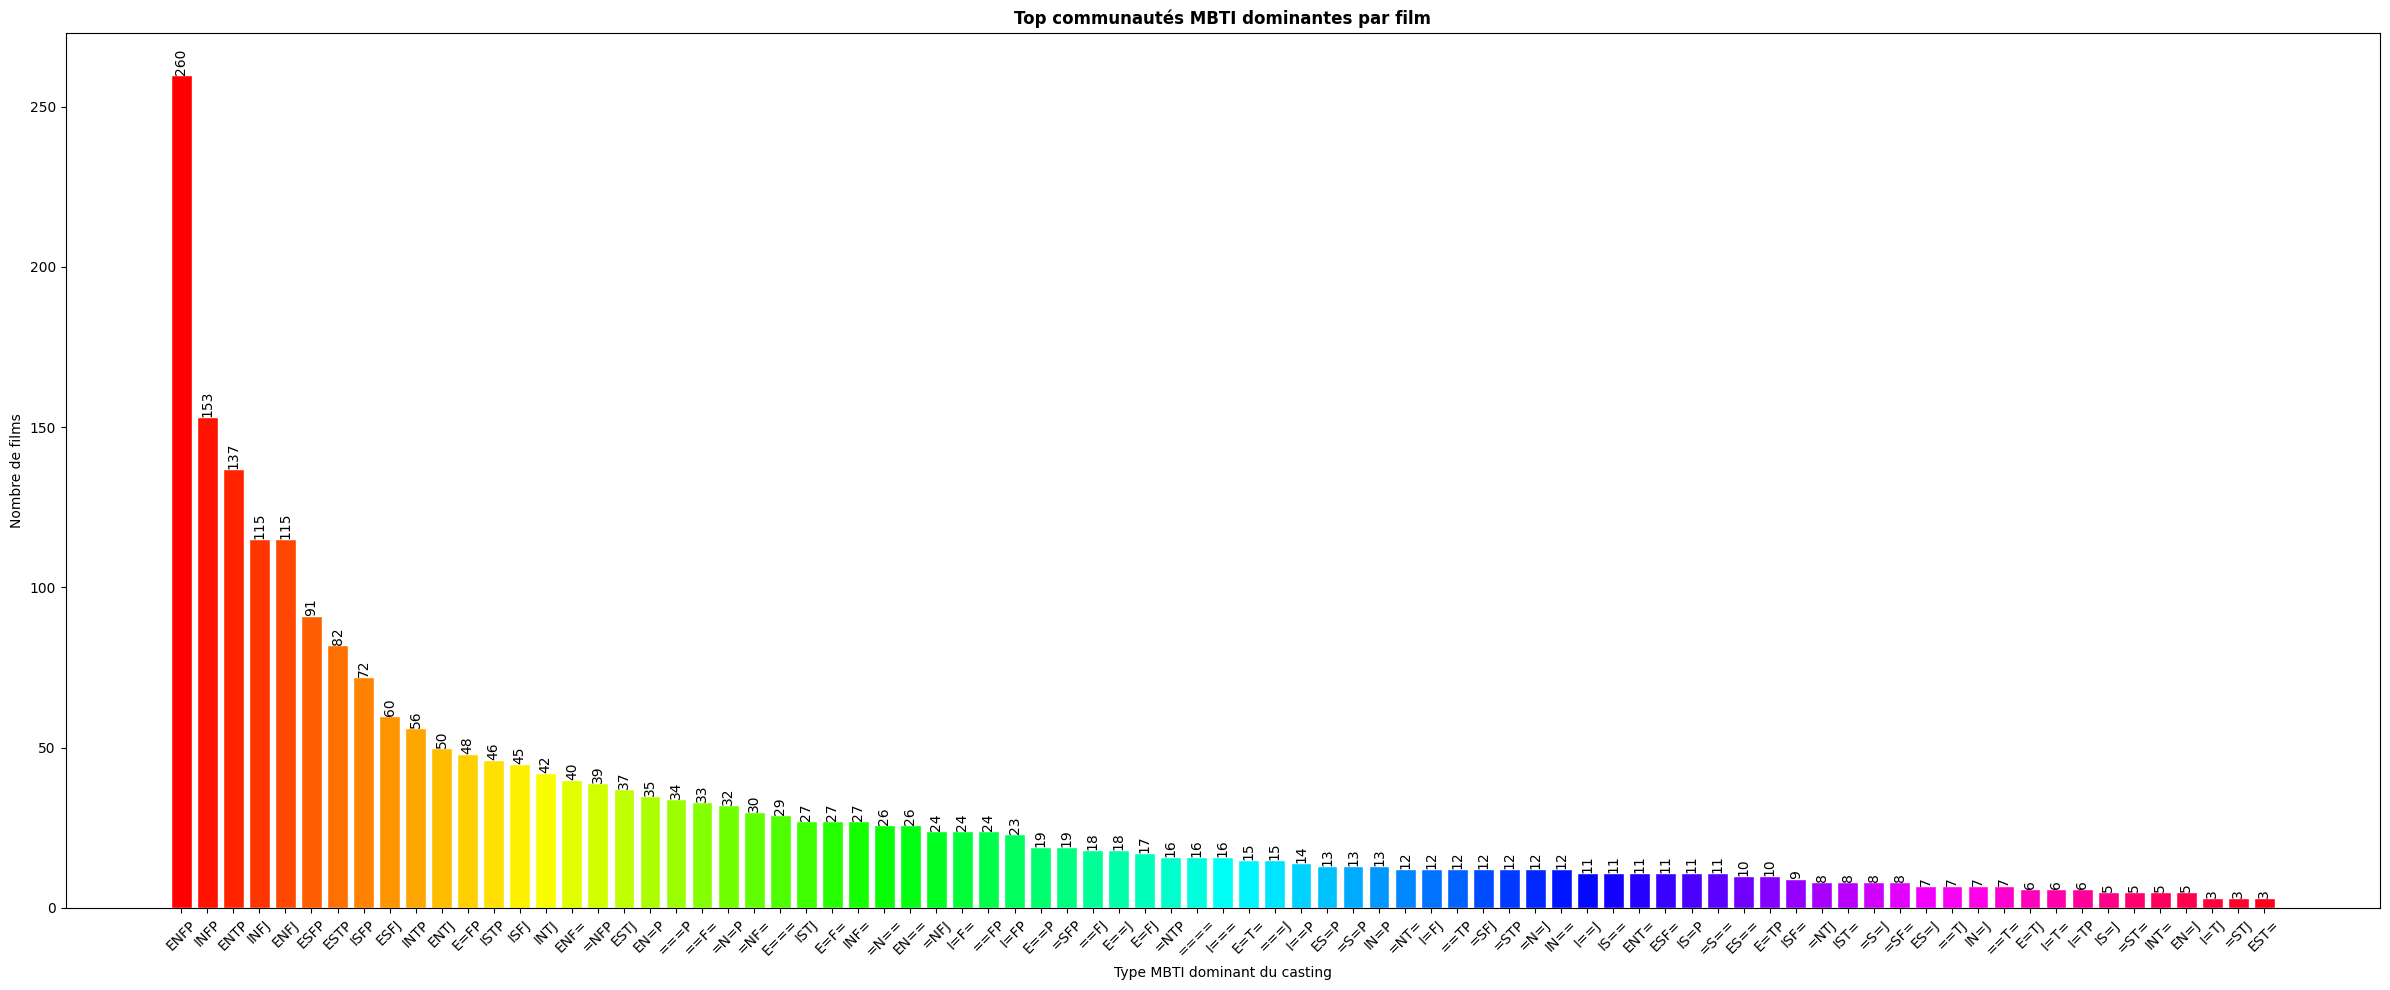

In [35]:
warnings.filterwarnings('ignore')

# check Louvain (pip install python-louvain)
try:
    import community as community_louvain
    HAS_LOUVAIN = True
except ImportError :
    HAS_LOUVAIN = False
    print("!!! python-louvain non installé —> approche graphe désactivée.")

# check kneed (pip install kneed)
try:
    from kneed import KneeLocator
    HAS_KNEED = True
except ImportError :
    HAS_KNEED = False
    print("!!! kneed non installé —> coude détecté manuellement.")


# Axe dominant par film

def dominant_letter(p_first, label_first, label_second) :
    if p_first is None or np.isnan(p_first) :
        return None
    
    if p_first > 0.5:
        return label_first
    elif p_first < 0.5:
        return label_second
    else:
        return '='

df_dist['dom_EI'] = df_dist['prop_E'].apply(lambda p: dominant_letter(p, 'E', 'I'))
df_dist['dom_SN'] = df_dist['prop_S'].apply(lambda p: dominant_letter(p, 'S', 'N'))
df_dist['dom_TF'] = df_dist['prop_T'].apply(lambda p: dominant_letter(p, 'T', 'F'))
df_dist['dom_JP'] = df_dist['prop_J'].apply(lambda p: dominant_letter(p, 'J', 'P'))

ties_EI = (df_dist['prop_E'] == 0.5).sum()
ties_SN = (df_dist['prop_S'] == 0.5).sum()
ties_TF = (df_dist['prop_T'] == 0.5).sum()
ties_JP = (df_dist['prop_J'] == 0.5).sum()
print(f"Nombres de films avec même proportion E/I : {ties_EI} ({ties_EI / len(df_dist) * 100:.2f}%)")
print(f"Nombres de films avec même proportion S/N : {ties_SN} ({ties_SN / len(df_dist) * 100:.2f}%)")
print(f"Nombres de films avec même proportion T/F : {ties_TF} ({ties_TF / len(df_dist) * 100:.2f}%)")
print(f"Nombres de films avec même proportion J/P : {ties_JP} ({ties_JP / len(df_dist) * 100:.2f}%)")

ties_total = df_dist[(df_dist['prop_E'] == 0.5) |
                    (df_dist['prop_S'] == 0.5) |
                    (df_dist['prop_T'] == 0.5) |
                    (df_dist['prop_J'] == 0.5)].shape[0]
print(f"\nNombres de films avec au moins 1 égalité : {ties_total} ({ties_total / len(df_dist) * 100:.2f}%)")


df_dist['community_dominant'] = (df_dist['dom_EI'].fillna('?') +
                                df_dist['dom_SN'].fillna('?') +
                                df_dist['dom_TF'].fillna('?') +
                                df_dist['dom_JP'].fillna('?'))

print("Communautés par axe dominant : ")
comm_counts = df_dist['community_dominant'].value_counts()
#print(comm_counts.head(16))

fig, ax = plt.subplots(figsize=(24, 10))
top81  = comm_counts.head(81)
colors = plt.cm.hsv(np.linspace(0, 1, len(top81)))
bars = ax.bar(top81.index,
                top81.values,
                width=0.8,
                color=colors,
                edgecolor='white')
for bar in bars :
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2,
            height,
            f'{int(height)}',
            ha='center',
            va='bottom',
            fontsize=10,
            rotation=90)
ax.set_title("Top communautés MBTI dominantes par film", fontweight='bold')
ax.set_xlabel("Type MBTI dominant du casting")
ax.set_ylabel("Nombre de films")
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('Images/Graph/community_dominant.png', dpi=150, bbox_inches='tight')
plt.show()


In [36]:
# Distribution globale des acteurs dans les films

number_actors = 0
undef = 0
num_E = 0
num_S = 0
num_T = 0
num_J = 0

for s in stats :
    number_actors += s[0][0]
    undef += s[0][1]
    num_E += s[1][0]
    num_S += s[2][0]
    num_T += s[3][0]
    num_J += s[4][0]

# proportions globales des lettres
size_actors_with_profil = number_actors - undef
global_E = num_E / size_actors_with_profil
global_S = num_S / size_actors_with_profil
global_T = num_T / size_actors_with_profil
global_J = num_J / size_actors_with_profil

print("Distribution globale des acteurs :")
print(f"E : {global_E:.3f}")
print(f"S : {global_S:.3f}")
print(f"T : {global_T:.3f}")
print(f"J : {global_J:.3f}")


# Correction du biais de fréquence des types

df_dist['delta_E'] = df_dist['prop_E'] - global_E
df_dist['delta_S'] = df_dist['prop_S'] - global_S
df_dist['delta_T'] = df_dist['prop_T'] - global_T
df_dist['delta_J'] = df_dist['prop_J'] - global_J

print(df_dist[['delta_E','delta_S','delta_T','delta_J']].describe().round(3))

Distribution globale des acteurs :
E : 0.556
S : 0.412
T : 0.411
J : 0.420
        delta_E   delta_S   delta_T   delta_J
count  2417.000  2417.000  2417.000  2417.000
mean     -0.000     0.004    -0.004     0.004
std       0.262     0.249     0.246     0.254
min      -0.556    -0.412    -0.411    -0.420
25%      -0.181    -0.162    -0.161    -0.170
50%      -0.056    -0.012    -0.011    -0.020
75%       0.194     0.159     0.160     0.180
max       0.444     0.588     0.589     0.580


`ENTJ` signifie : « plus E, N, T, J que la moyenne des acteurs »

Coude détecté à k = 5


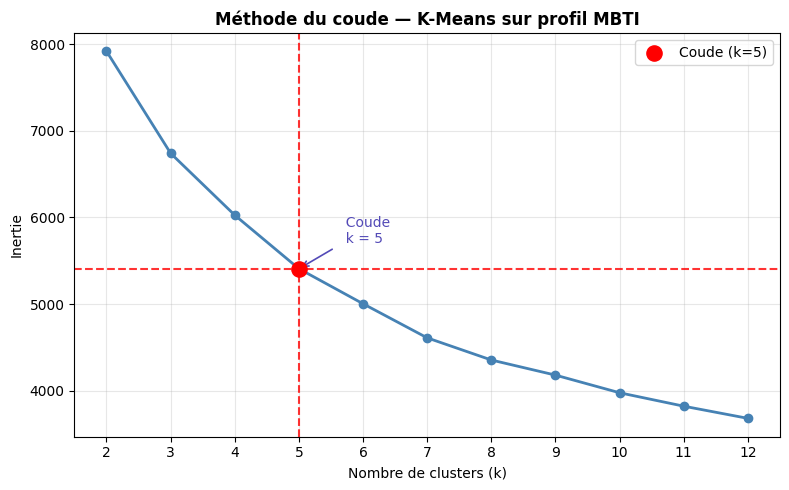


Profil moyen par cluster K-Means (k=5) : 
                    E      S      T      J
cluster_kmeans                            
0.0            -0.220 -0.116 -0.213 -0.067
1.0             0.076 -0.178  0.219 -0.111
2.0            -0.140  0.072  0.027  0.308
3.0            -0.002  0.295  0.112 -0.154
4.0             0.284 -0.055 -0.163  0.019

	Labels des clusters :
{0.0: 'INFP', 1.0: 'ENTP', 2.0: 'ISTJ', 3.0: 'ISTP', 4.0: 'ENFJ'}

DBSCAN :
	Clusters trouvés : 14
	Films 'bruit' (atypiques) : 179
cluster_dbscan
 0     2151
-1      179
 11      15
 9        9
 1        7
 6        7
 3        6
 13       6
 4        6
 10       6
Name: count, dtype: int64

Graphe Louvain (distance euclidienne) :
	Seuil distance : 0.28
	Noeuds : 2417, Arêtes : 121734
	Densité : 0.04169
resolution=0.01 → 137 communautés | top 3 : 1271, 237, 156 films
resolution=0.05 → 136 communautés | top 3 : 1202, 236, 154 films
resolution=0.10 → 136 communautés | top 3 : 1143, 253, 161 films
resolution=0.20 → 136 communa

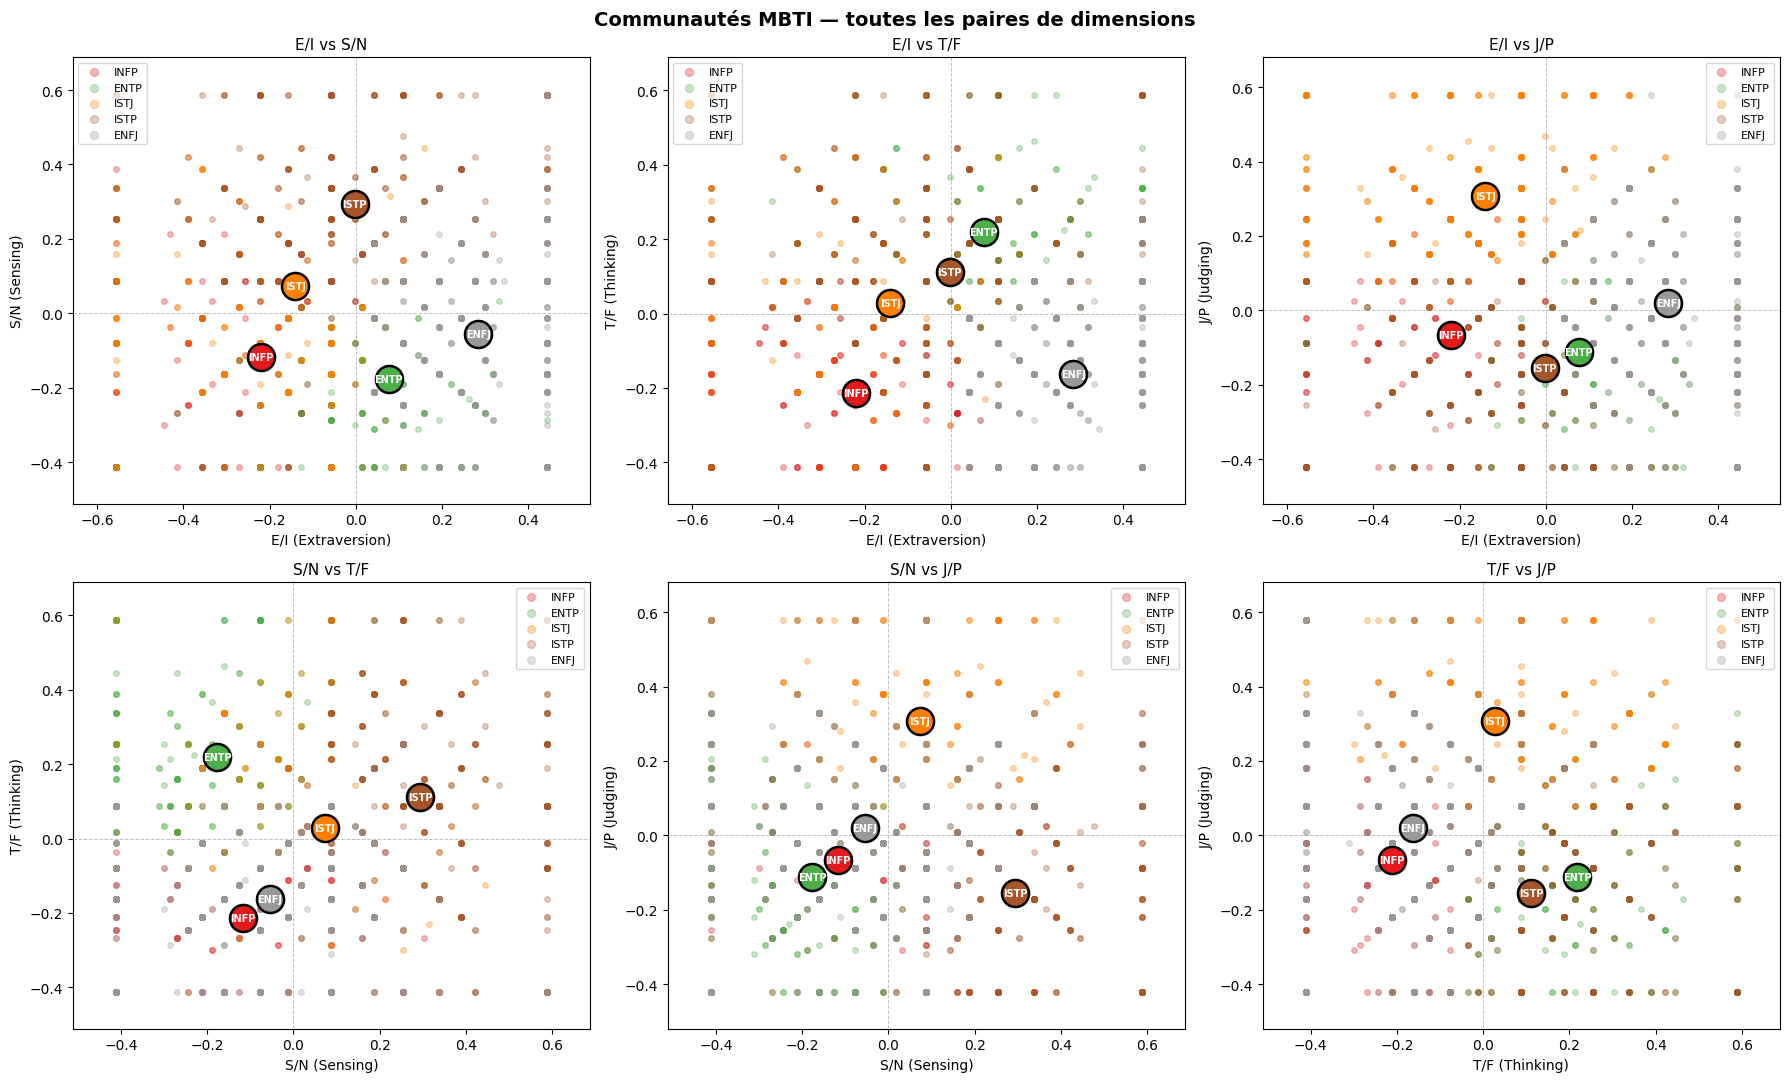


Dans quel cluster va chaque film :
  community_dominant  cluster_kmeans cluster_label  cluster_dbscan  \
0               ISTJ             2.0          ISTJ             0.0   
1               INTP             1.0          ENTP             0.0   
2               I=FJ             2.0          ISTJ             0.0   
3               I=FP             0.0          INFP             0.0   
4               ENFP             4.0          ENFJ             0.0   
5               ENTP             1.0          ENTP             0.0   
6               INFP             0.0          INFP             0.0   
7               ENFP             4.0          ENFJ             0.0   
8               INTJ             2.0          ISTJ             0.0   
9               ISFJ             2.0          ISTJ             0.0   

   community_louvain  
0                  0  
1                  8  
2                  0  
3                  0  
4                 15  
5                  8  
6                  8  
7        

In [37]:
# Clustering sur profil vectoriel 4D (K-Means / DBSCAN)

features = ['delta_E', 'delta_S', 'delta_T', 'delta_J']
df_valid = df_dist[features].dropna().copy()

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df_valid)

# K-Means : méthode du coude
inertias = []
K_range  = range(2, 13)
for k in K_range :
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

# Détection du coude
if HAS_KNEED :
    kneedle = KneeLocator(list(K_range), inertias, curve='convex', direction='decreasing')
    k_elbow = kneedle.elbow
else :
    # Fallback : différences secondes
    deltas  = np.diff(inertias)
    k_elbow = list(K_range)[np.argmax(np.abs(np.diff(deltas))) + 1]

print(f"Coude détecté à k = {k_elbow}")

# Graphique coude
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(K_range), inertias, 'o-', color='steelblue', linewidth=2, markersize=6, zorder=3)

elbow_inertia = inertias[k_elbow - 2]
ax.axvline(k_elbow, color="#FF0000", linestyle='--', linewidth=1.5, alpha=0.8, zorder=2)
ax.axhline(elbow_inertia, color="#FF0000", linestyle='--', linewidth=1.5, alpha=0.8, zorder=2)
ax.scatter([k_elbow], [elbow_inertia], color="#FF0000", s=120, zorder=5, label=f'Coude (k={k_elbow})')
ax.annotate(f'  Coude\n  k = {k_elbow}',
            xy=(k_elbow, elbow_inertia),
            xytext=(k_elbow + 0.6, elbow_inertia + 300),
            fontsize=10,
            color='#534AB7',
            arrowprops=dict(arrowstyle='->', color='#534AB7', lw=1.2))
ax.set_title("Méthode du coude — K-Means sur profil MBTI", fontweight='bold')
ax.set_xlabel("Nombre de clusters (k)")
ax.set_ylabel("Inertie")
ax.set_xticks(list(K_range))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('Images/Graph/kmeans_elbow.png', dpi=150, bbox_inches='tight')
plt.show()

# K-Means avec k optimal
K_OPTIMAL = k_elbow
km_final  = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
df_valid['cluster_kmeans'] = km_final.fit_predict(X_scaled)

df_dist['cluster_kmeans'] = np.nan
df_dist.loc[df_valid.index, 'cluster_kmeans'] = df_valid['cluster_kmeans']

print(f"\nProfil moyen par cluster K-Means (k={k_elbow}) : ")
cluster_profiles = df_dist.groupby('cluster_kmeans')[features].mean().round(3)
cluster_profiles.columns = ['E', 'S', 'T', 'J']
print(cluster_profiles)

def name_cluster(row):
    ei = 'E' if row['E'] >= 0 else 'I'
    sn = 'S' if row['S'] >= 0 else 'N'
    tf = 'T' if row['T'] >= 0 else 'F'
    jp = 'J' if row['J'] >= 0 else 'P'
    return f"{ei}{sn}{tf}{jp}"

cluster_profiles['label'] = cluster_profiles.apply(name_cluster, axis=1)
cluster_label_map = cluster_profiles['label'].to_dict()
df_dist['cluster_label'] = df_dist['cluster_kmeans'].map(cluster_label_map)
print("\n\tLabels des clusters :")
print(cluster_label_map)

# DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

dbscan = DBSCAN(eps=0.8, min_samples=5)
df_valid['cluster_dbscan'] = dbscan.fit_predict(X_scaled)
df_dist['cluster_dbscan'] = np.nan
df_dist.loc[df_valid.index, 'cluster_dbscan'] = df_valid['cluster_dbscan']

n_clusters_db = len(set(df_valid['cluster_dbscan'])) - (1 if -1 in df_valid['cluster_dbscan'].values else 0)
n_noise_db    = (df_valid['cluster_dbscan'] == -1).sum()
print(f"\nDBSCAN :")
print(f"\tClusters trouvés : {n_clusters_db}")
print(f"\tFilms 'bruit' (atypiques) : {n_noise_db}")
print(df_valid['cluster_dbscan'].value_counts().head(10))



# Graphe de similarité + Louvain 

if HAS_LOUVAIN :
    from sklearn.metrics.pairwise import euclidean_distances

    X_raw      = df_dist[features].dropna()
    dist_matrix = euclidean_distances(X_raw.values)   # (n_films, n_films)

    DIST_THRESHOLD = 0.28

    # plus c'est proche, plus le lien est fort
    # w = 1 / (1 + d)
    G        = nx.Graph()
    idx_list = X_raw.index.tolist()

    for i, fi in enumerate(idx_list) :
        G.add_node(fi)
        for j, fj in enumerate(idx_list) :
            if i < j and dist_matrix[i, j] <= DIST_THRESHOLD :
                weight = 1 / (1 + dist_matrix[i, j])
                G.add_edge(fi, fj, weight=weight)

    # Densité
    n_nodes   = G.number_of_nodes()
    n_edges   = G.number_of_edges()
    max_edges = n_nodes * (n_nodes - 1) / 2
    density   = n_edges / max_edges if max_edges > 0 else 0

    print(f"\nGraphe Louvain (distance euclidienne) :")
    print(f"\tSeuil distance : {DIST_THRESHOLD}")
    print(f"\tNoeuds : {n_nodes}, Arêtes : {n_edges}")
    print(f"\tDensité : {density:.5f}")

    for resolution in [0.01, 0.05, 0.1, 0.2, 0.5, 0.75, 0.9, 1]:
        partition_test = community_louvain.best_partition(G, weight='weight', random_state=42, resolution=resolution)
        n = len(set(partition_test.values()))
        sizes = pd.Series(partition_test).value_counts()
        print(f"resolution={resolution:.2f} → {n} communautés | "
            f"top 3 : {sizes.iloc[0]}, {sizes.iloc[1] if len(sizes)>1 else '-'}, "
            f"{sizes.iloc[2] if len(sizes)>2 else '-'} films")

    partition = community_louvain.best_partition(G, weight='weight', random_state=42, resolution=0.75)
    df_dist['community_louvain'] = df_dist.index.map(partition)

    n_comm  = len(set(partition.values()))
    sizes   = pd.Series(partition).value_counts()
    print(f"Nombre de communautés : {n_comm}")
    print(sizes.head(10))

    # Profil moyen de chaque communauté Louvain
    print("\nProfil moyen par communauté Louvain (top 8) : ")
    top_comms = sizes.head(8).index.tolist()
    louvain_profiles = (df_dist[df_dist['community_louvain'].isin(top_comms)]
                                .groupby('community_louvain')[features]
                                .mean()
                                .round(3))
    louvain_profiles.columns = ['E', 'S', 'T', 'J']
    louvain_profiles['label'] = louvain_profiles.apply(name_cluster, axis=1)
    louvain_profiles['size']  = sizes
    print(louvain_profiles.sort_values('size', ascending=False))

else :
    print("\nLouvain non disponible. Installe avec : pip install python-louvain")


# scatter 6 paires de dimensions MBTI

dim_labels = {'delta_E': 'E/I (Extraversion)',
                'delta_S': 'S/N (Sensing)',
                'delta_T': 'T/F (Thinking)',
                'delta_J': 'J/P (Judging)'}
pairs   = list(itertools.combinations(features, 2))
palette = plt.cm.Set1(np.linspace(0, 1, K_OPTIMAL))

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Communautés MBTI — toutes les paires de dimensions", fontsize=14, fontweight='bold')
axes = axes.flatten()

for ax, (dx, dy) in zip(axes, pairs) :

    # Points (alpha réduit pour mieux voir)
    for k in range(K_OPTIMAL) :
        mask  = df_dist['cluster_kmeans'] == k
        label = cluster_label_map.get(k, f'C{k}')
        ax.scatter(df_dist.loc[mask, dx], df_dist.loc[mask, dy], c=[palette[k]], alpha=0.30, s=16, label=label)

    # Centroïdes
    for k in range(K_OPTIMAL) :
        mask  = df_dist['cluster_kmeans'] == k
        cx    = df_dist.loc[mask, dx].mean()
        cy    = df_dist.loc[mask, dy].mean()
        label = cluster_label_map.get(k, f'C{k}')

        ax.scatter(cx, cy, s=420, color='white', zorder=6)
        ax.scatter(cx, cy, s=380, color=palette[k], zorder=7, edgecolors='black', linewidths=1.8)
        ax.text(cx, cy, label, ha='center', va='center', fontsize=7, fontweight='bold', color='white', zorder=8)

    ax.axvline(0, color='gray', linestyle='--', linewidth=0.7, alpha=0.5)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.7, alpha=0.5)
    ax.set_xlabel(dim_labels[dx], fontsize=10)
    ax.set_ylabel(dim_labels[dy], fontsize=10)
    ax.set_xlim(df_dist[dx].min()-0.1, df_dist[dx].max()+0.1)
    ax.set_ylim(df_dist[dy].min()-0.1, df_dist[dy].max()+0.1)
    ax.set_title(f"{dim_labels[dx].split()[0]} vs {dim_labels[dy].split()[0]}", fontsize=11)
    ax.legend(fontsize=8, markerscale=1.4)

plt.tight_layout()
plt.savefig('Images/Graph/community_clusters_scatter.png', dpi=150, bbox_inches='tight')
plt.show()


print("\nDans quel cluster va chaque film :")
new_cols = ['community_dominant', 'cluster_kmeans', 'cluster_label', 'cluster_dbscan']
if HAS_LOUVAIN :
    new_cols.append('community_louvain')
print(df_dist[new_cols].head(10))